# Lending Club Default Analysis

The analysis is divided into four main parts:
1. Data understanding 
2. Data cleaning (cleaning missing values, removing redundant columns etc.)
3. Data Analysis 
4. Recommendations

In [362]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [363]:
import pandas as pd
loan = pd.read_csv('loan_csv.csv')

C:\Users\Shubham\AppData\Local\Temp\ipykernel_7576\1603461494.py:2: DtypeWarning:

Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.



In [364]:
loan.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [365]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 33.6+ MB


In [366]:
loan.shape

(39717, 111)

In [367]:
loan.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 111 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    id                              39717 non-null  int64  
 1    member_id                       39717 non-null  int64  
 2    loan_amnt                       39717 non-null  int64  
 3    funded_amnt                     39717 non-null  int64  
 4    funded_amnt_inv                 39717 non-null  float64
 5    term                            39717 non-null  object 
 6    int_rate                        39717 non-null  object 
 7    installment                     39717 non-null  float64
 8    grade                           39717 non-null  object 
 9    sub_grade                       39717 non-null  object 
 10   emp_title                       37258 non-null  object 
 11   emp_length                      38642 non-null  object 
 12   home_ownership  

## Data Understanding

In [368]:
# let's look at the first few rows of the df
loan.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
5,1075269,1311441,5000,5000,5000.0,36 months,7.90%,156.46,A,A4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
6,1069639,1304742,7000,7000,7000.0,60 months,15.96%,170.08,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
7,1072053,1288686,3000,3000,3000.0,36 months,18.64%,109.43,E,E1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
8,1071795,1306957,5600,5600,5600.0,60 months,21.28%,152.39,F,F2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
9,1071570,1306721,5375,5375,5350.0,60 months,12.69%,121.45,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [369]:
# Looking at all the column names
loan.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit'],
      dtype='object', length=111)

Some of the important columns in the dataset are loan_amount, term, interest rate, grade, sub grade, annual income, purpose of the loan etc.

The **target variable**, which we want to compare across the independent variables, is loan status. The strategy is to figure out compare the average default rates across various independent variables and identify the  ones that affect default rate the most.

# Data Cleaning

Some columns have a large number of missing values, let's first fix the missing values and then check for other types of data quality problems.

loan.isnull().sum()

In [370]:
# summarising number of missing values in each column
loan.isnull().sum()

id                                0
member_id                         0
loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
                              ...  
tax_liens                        39
tot_hi_cred_lim               39717
total_bal_ex_mort             39717
total_bc_limit                39717
total_il_high_credit_limit    39717
Length: 111, dtype: int64

In [371]:
# removing the columns having more than 90% missing values
missing_columns = loan.columns[100*(loan.isnull().sum()/len(loan.index)) > 90]
print(missing_columns)

Index(['mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint',
       'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m',
       'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il',
       'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
       'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
       'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd',
       'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl',
       'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0',
       'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
 

In [372]:
loan = loan.drop(missing_columns, axis=1)
print(loan.shape)



(39717, 55)


In [373]:
# summarise number of missing values again
100*(loan.isnull().sum()/len(loan.index))

id                             0.000000
member_id                      0.000000
loan_amnt                      0.000000
funded_amnt                    0.000000
funded_amnt_inv                0.000000
term                           0.000000
int_rate                       0.000000
installment                    0.000000
grade                          0.000000
sub_grade                      0.000000
emp_title                      6.191303
emp_length                     2.706650
home_ownership                 0.000000
annual_inc                     0.000000
verification_status            0.000000
issue_d                        0.000000
loan_status                    0.000000
pymnt_plan                     0.000000
url                            0.000000
desc                          33.114284
purpose                        0.000000
title                          0.027696
zip_code                       0.000000
addr_state                     0.000000
dti                            0.000000


In [374]:
# There are now 2 columns having approx 32 and 64% missing values - 
# description and months since last delinquent

# let's have a look at a few entries in the columns
loan.loc[:, ['desc', 'mths_since_last_delinq']].head()

,desc,mths_since_last_delinq
0,Borrower added on 12/22/11 > I need to upgrade...,NaN
1,Borrower added on 12/22/11 > I plan to use thi...,NaN
2,NaN,NaN
3,Borrower added on 12/21/11 > to pay for prop...,35.0
4,Borrower added on 12/21/11 > I plan on combi...,38.0


The column description contains the comments the applicant had written while applying for the loan. Although one can use some text analysis techniques to derive new features from this column (such as sentiment, number of positive/negative words etc.), we will not use this column in this analysis.

Secondly, months since last delinquent represents the number months passed since the person last fell into the 90 DPD group. There is an important reason we shouldn't use this column in analysis - since at the time of loan application, we will not have this data (it gets generated months after the loan has been approved), it cannot be used as a predictor of default at the time of loan approval.

Thus let's drop the two columns.

In [375]:
# dropping the two columns
loan = loan.drop(['desc', 'mths_since_last_delinq'], axis=1)

In [376]:
100*(loan.isnull().sum()/len(loan.index))

id                            0.000000
member_id                     0.000000
loan_amnt                     0.000000
funded_amnt                   0.000000
funded_amnt_inv               0.000000
term                          0.000000
int_rate                      0.000000
installment                   0.000000
grade                         0.000000
sub_grade                     0.000000
emp_title                     6.191303
emp_length                    2.706650
home_ownership                0.000000
annual_inc                    0.000000
verification_status           0.000000
issue_d                       0.000000
loan_status                   0.000000
pymnt_plan                    0.000000
url                           0.000000
purpose                       0.000000
title                         0.027696
zip_code                      0.000000
addr_state                    0.000000
dti                           0.000000
delinq_2yrs                   0.000000
earliest_cr_line         

There are some more columns with missing values, but let's ignore them for now (since we are ntot doing any modeling, we don't need to impute all missing values anyway). 

But let's check whether some rows have a large number of missing values.

In [377]:
loan.isnull().sum(axis=1)

0        1
1        0
2        1
3        0
4        0
        ..
39712    4
39713    4
39714    5
39715    5
39716    4
Length: 39717, dtype: int64

In [378]:
len(loan[loan.isnull().sum(axis=1) > 5].index)

0

## The data looks clean by and large.
## Let's also check whether all columns are in the correct format.

In [379]:
loan.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [380]:
# The column int_rate is character type, let's convert it to float
loan['int_rate'] = loan['int_rate'].apply(lambda x: pd.to_numeric(x.split("%")[0]))


###df['column_name'] = (pd.to_numeric(df['column_name'].str.rstrip('%'), errors='coerce')) ### new style

In [381]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [382]:
loan['emp_length']

0        10+ years
1         < 1 year
2        10+ years
3        10+ years
4           1 year
           ...    
39712      4 years
39713      3 years
39714     < 1 year
39715     < 1 year
39716     < 1 year
Name: emp_length, Length: 39717, dtype: object

In [383]:
# also, lets extract the numeric part from the variable employment length

# first, let's drop the missing values from the column (otherwise the regex code below throws error)
loan = loan[~loan['emp_length'].isnull()]

# using regular expression to extract numeric values from the string
import re
loan['emp_length'] = loan['emp_length'].apply(lambda x: re.findall('\d+', str(x))[0])

# convert to numeric
loan['emp_length'] = loan['emp_length'].apply(lambda x: pd.to_numeric(x))


### df['column_name'] = df['column_name'].str.extract(r'(\d+)').astype(int)  ## new style

In [384]:
loan['emp_length'].value_counts()

emp_length
10    8879
1     7823
2     4388
3     4095
4     3436
5     3282
6     2229
7     1773
8     1479
9     1258
Name: count, dtype: int64

In [385]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38642 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          38642 non-null  int64  
 1   member_id                   38642 non-null  int64  
 2   loan_amnt                   38642 non-null  int64  
 3   funded_amnt                 38642 non-null  int64  
 4   funded_amnt_inv             38642 non-null  float64
 5   term                        38642 non-null  object 
 6   int_rate                    38642 non-null  float64
 7   installment                 38642 non-null  float64
 8   grade                       38642 non-null  object 
 9   sub_grade                   38642 non-null  object 
 10  emp_title                   37202 non-null  object 
 11  emp_length                  38642 non-null  int64  
 12  home_ownership              38642 non-null  object 
 13  annual_inc                  38642 no

## Data Analysis

Let's now move to data analysis. To start with, let's understand the objective of the analysis clearly and identify the variables that we want to consider for analysis. 

The objective is to identify predictors of default so that at the time of loan application, we can use those variables for approval/rejection of the loan. Now, there are broadly three types of variables - 1. those which are related to the applicant (demographic variables such as age, occupation, employment details etc.), 2. loan characteristics (amount of loan, interest rate, purpose of loan etc.) and 3. Customer behaviour variables (those which are generated after the loan is approved such as delinquent 2 years, revolving balance, next payment date etc.).

Now, the customer behaviour variables are not available at the time of loan application, and thus they cannot be used as predictors for credit approval. 

Thus, going forward, we will use only the other two types of variables.


In [386]:
behaviour_var =  [
  "delinq_2yrs",
  "earliest_cr_line",
  "inq_last_6mths",
  "open_acc",
  "pub_rec",
  "revol_bal",
  "revol_util",
  "total_acc",
  "out_prncp",
  "out_prncp_inv",
  "total_pymnt",
  "total_pymnt_inv",
  "total_rec_prncp",
  "total_rec_int",
  "total_rec_late_fee",
  "recoveries",
  "collection_recovery_fee",
  "last_pymnt_d",
  "last_pymnt_amnt",
  "last_credit_pull_d",
  "application_type"]
behaviour_var

['delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'last_credit_pull_d',
 'application_type']

In [387]:
df = loan.drop(behaviour_var, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38642 entries, 0 to 39716
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          38642 non-null  int64  
 1   member_id                   38642 non-null  int64  
 2   loan_amnt                   38642 non-null  int64  
 3   funded_amnt                 38642 non-null  int64  
 4   funded_amnt_inv             38642 non-null  float64
 5   term                        38642 non-null  object 
 6   int_rate                    38642 non-null  float64
 7   installment                 38642 non-null  float64
 8   grade                       38642 non-null  object 
 9   sub_grade                   38642 non-null  object 
 10  emp_title                   37202 non-null  object 
 11  emp_length                  38642 non-null  int64  
 12  home_ownership              38642 non-null  object 
 13  annual_inc                  38642 no

In [388]:
# also, we will not be able to use the variables zip code, address, state etc.
# the variable 'title' is derived from the variable 'purpose'
# thus let get rid of all these variables as well

df = df.drop(['title', 'url', 'zip_code', 'addr_state'], axis=1)

Next, let's have a look at the target variable - loan_status. We need to relabel the values to a binary form - 0 or 1, 1 indicating that the person has defaulted and 0 otherwise.



In [389]:
df['loan_status'] = df['loan_status'].astype('category')
df['loan_status'].value_counts()

loan_status
Fully Paid     32145
Charged Off     5399
Current         1098
Name: count, dtype: int64

You can see that fully paid comprises most of the loans. The ones marked 'current' are neither fully paid not defaulted, so let's get rid of the current loans. Also, let's tag the other two values as 0 or 1.

In [390]:
# filtering only fully paid or charged-off
df = df[df['loan_status'] != 'Current']
df['loan_status'] = df['loan_status'].apply(lambda x: 0 if x=='Fully Paid' else 1)

# converting loan_status to integer type
df['loan_status'] = df['loan_status'].apply(lambda x: pd.to_numeric(x))

# summarising the values
df['loan_status'].value_counts()

loan_status
0    32145
1     5399
Name: count, dtype: int64

Next, let's start with univariate analysis and then move to bivariate analysis.

## Univariate Analysis

First, let's look at the overall default rate.

In [391]:
df['loan_status'].dtype

dtype('int64')

In [392]:
round(df['loan_status'].mean()*100, 5)

np.float64(14.38046)

The overall default rate is about 14%.Let's first visualise the average default rates across categorical variables.

In [393]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- 1. THE ESSENTIAL "GLOW UP" CONFIGURATION ---
%config InlineBackend.figure_format = 'retina' # Makes plots sharp
sns.set_theme(style="white", palette="bright") # Clean background

# --- 2. CUSTOM PRESET FOR PRESENTATION ---
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'axes.facecolor': '#F8F9F9',      # Very light grey background
    'axes.edgecolor': '#D5D8DC',      # Soft border colors
    'axes.labelcolor': '#2C3E50',     # Dark blue-grey text for readability
    'axes.titlesize': 22,             # Large, bold titles
    'axes.titleweight': 'bold',
    'axes.titlepad': 20,              # Space between title and plot
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'grid.alpha': 0.3                 # Very faint grid lines
})

# --- 3. THE "COLORFUL" MAGIC FUNCTION ---
def apply_presentation_style(ax, title, xlabel, ylabel):
    """
    Call this function after creating any plot to make it look 'best representative'.
    It adds a title, labels, and removes unnecessary borders.
    """
    ax.set_title(title)
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    
    # Remove the top and right spines (cleaner look)
    sns.despine()
    
    # Add value labels on top of the bars (The most professional touch)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold', color='#34495E')

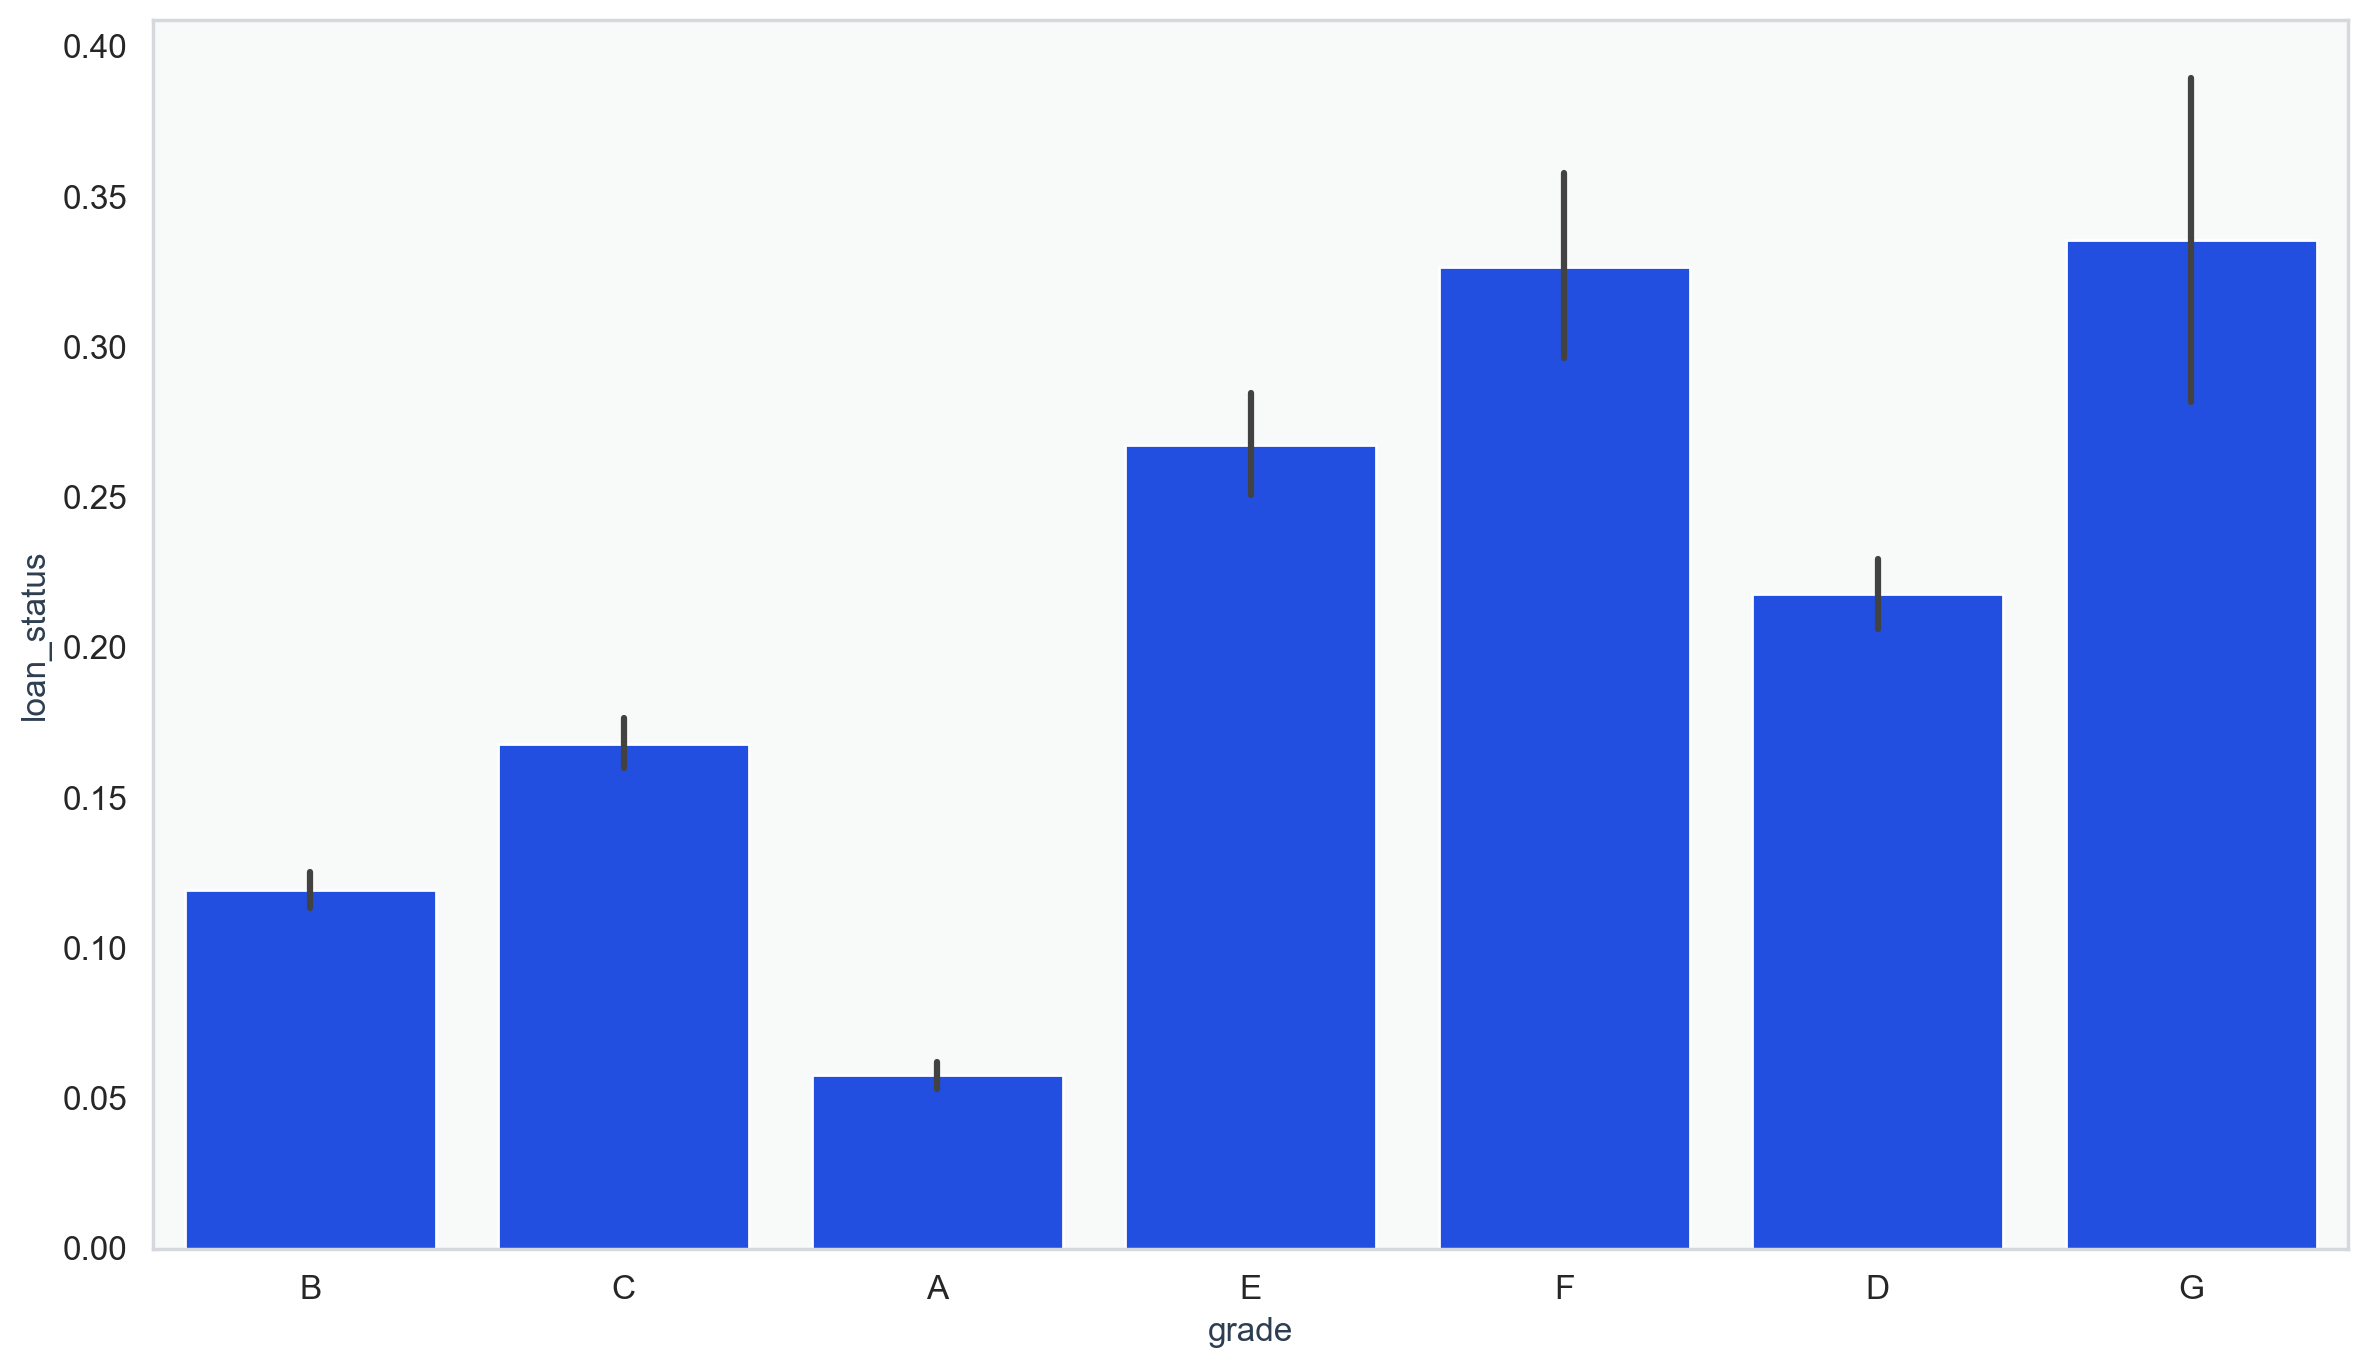

In [394]:
# plotting default rates across grade of the loan
sns.barplot(x='grade', y='loan_status', data=df)
plt.show()

In [395]:
def plot_cat(cat_var):
    sns.barplot(x=cat_var, y='loan_status', data=df)     
    plt.show()
    

Clearly, as the grade of loan goes from A to G, the default rate increases. This is expected because the grade is decided by Lending Club based on the riskiness of the loan.

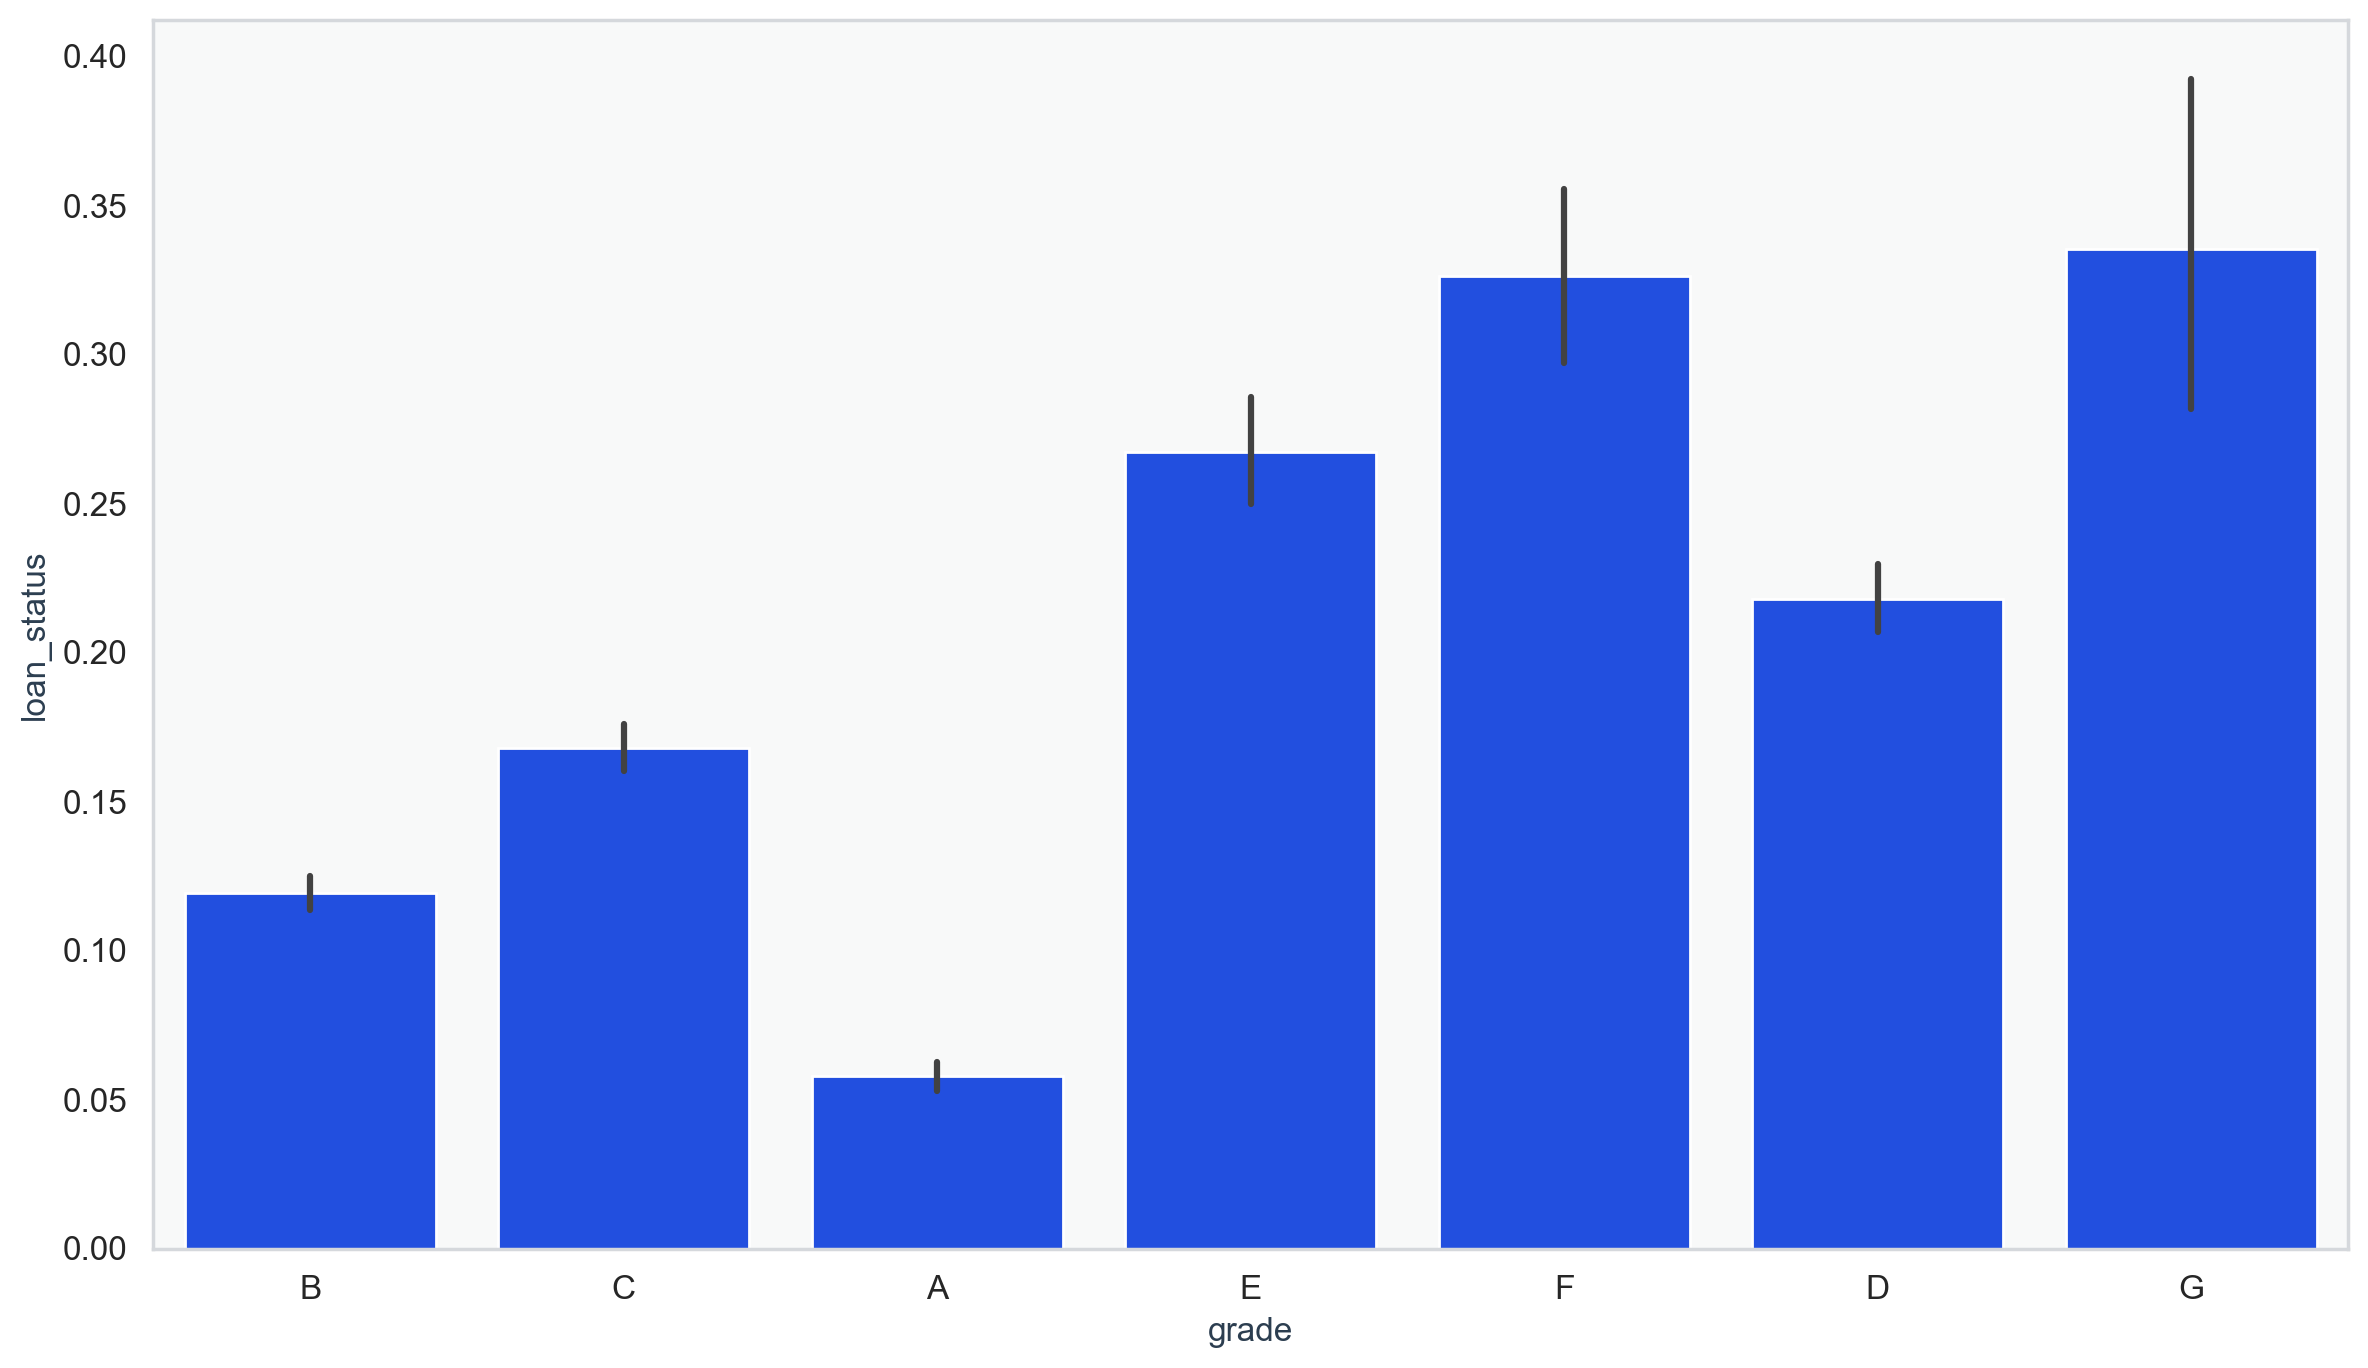

In [396]:
# compare default rates across grade of loan
plot_cat('grade')

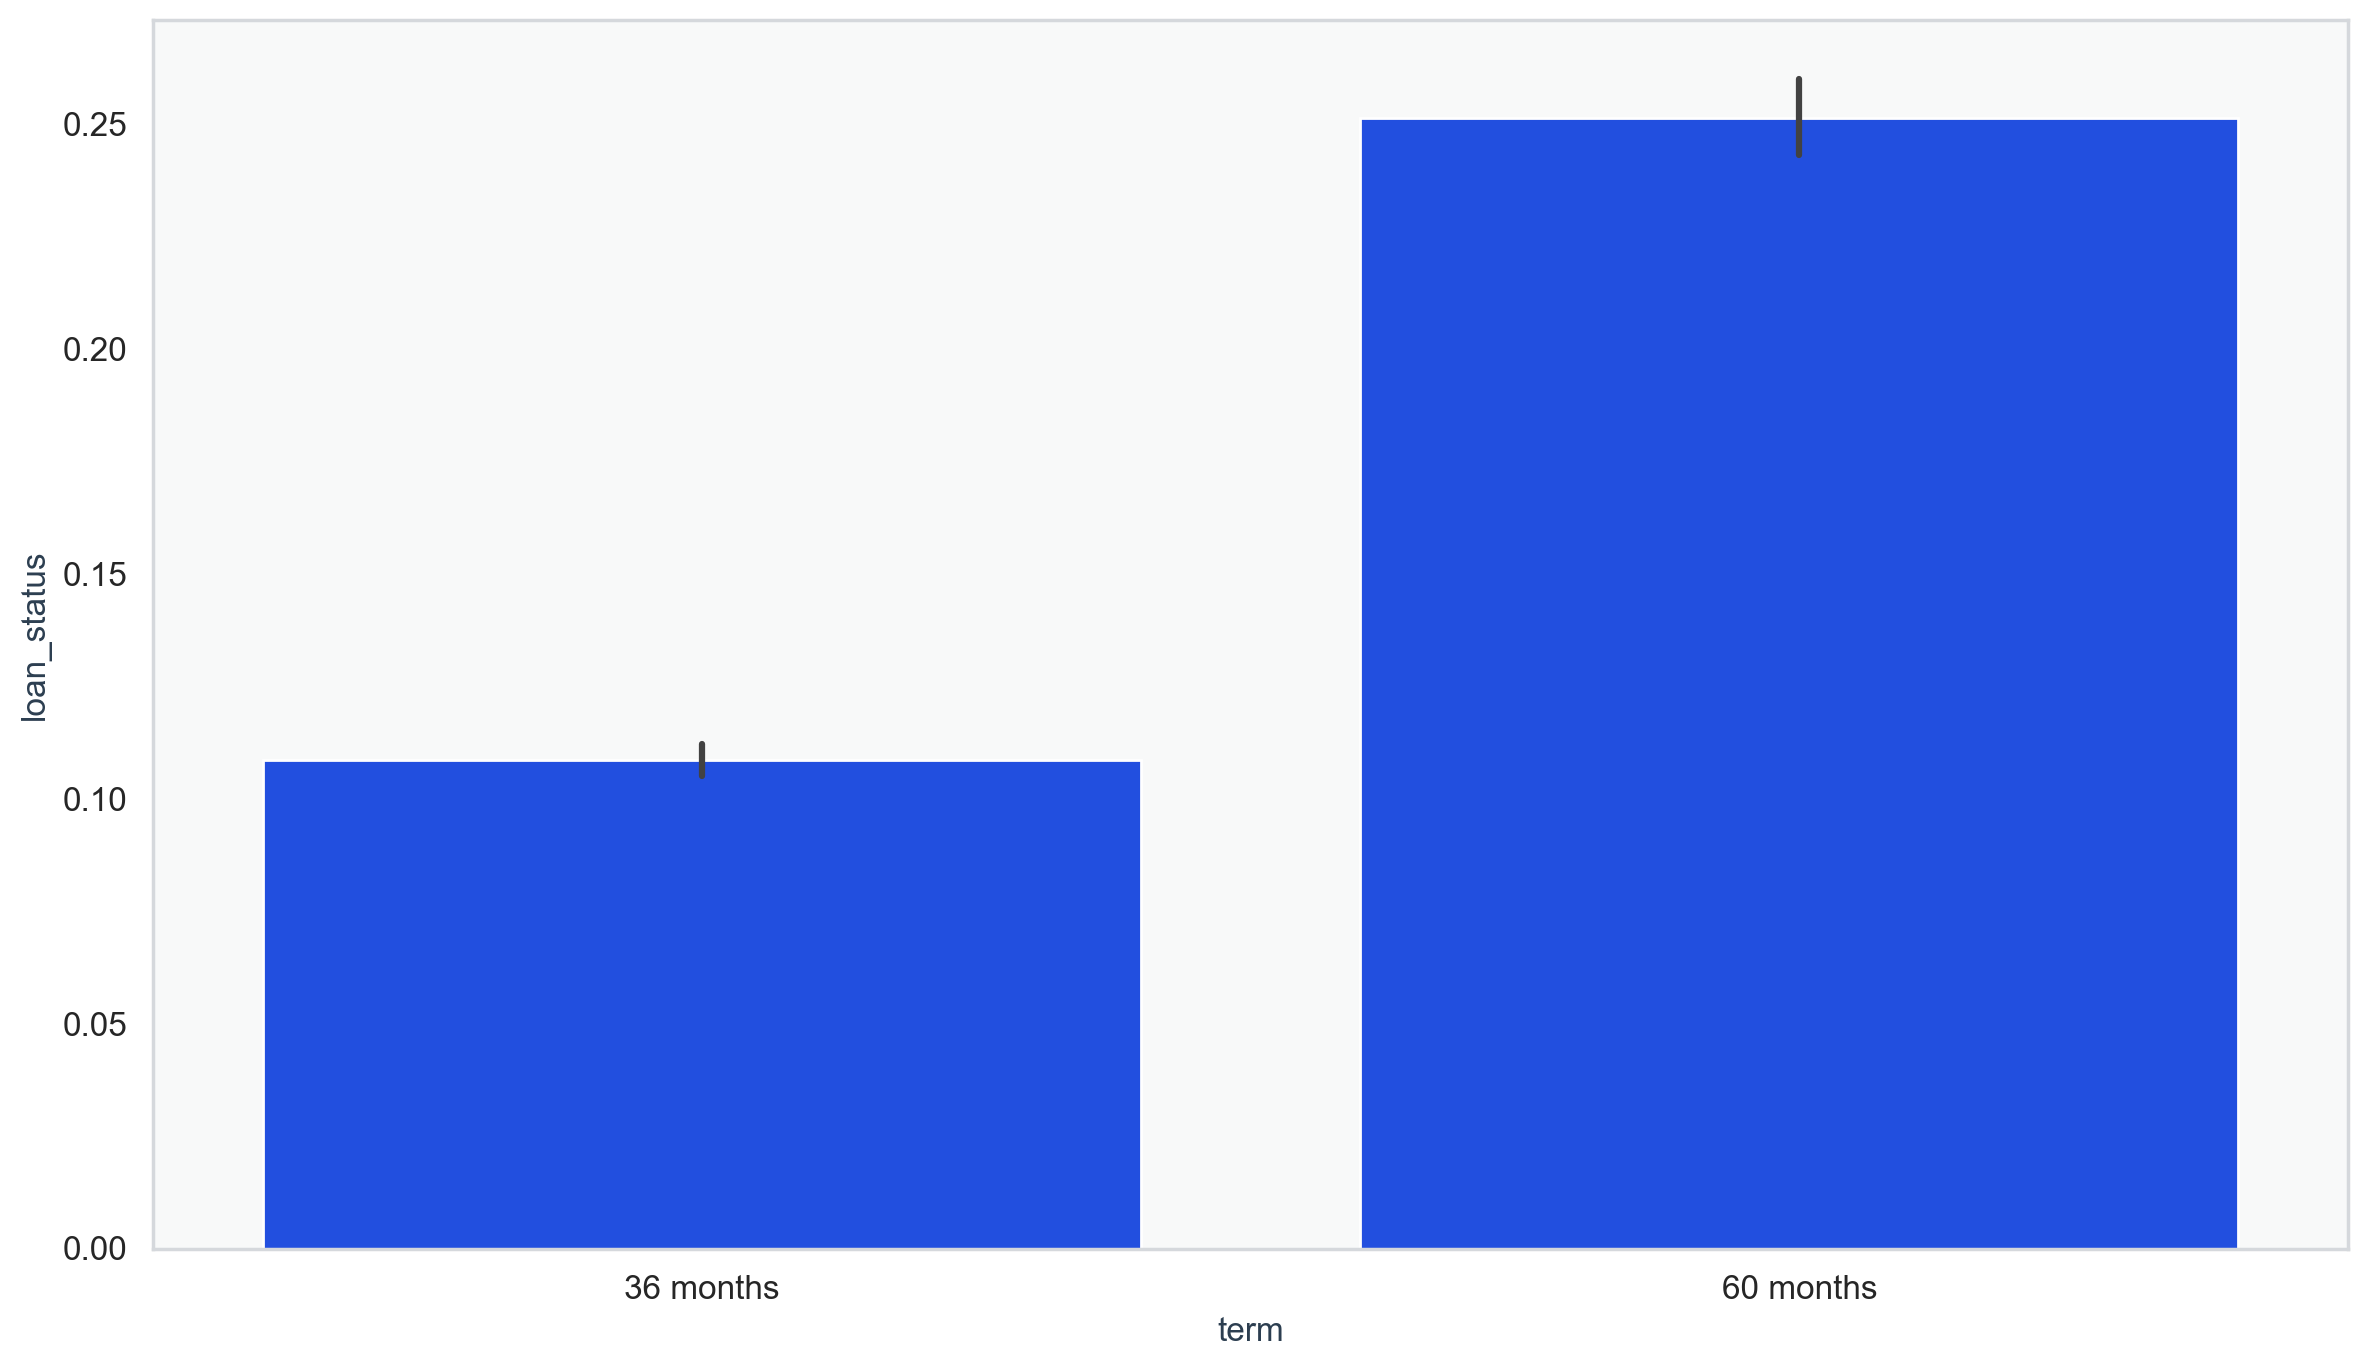

In [397]:
# term: 60 months loans default more than 36 months loans
plot_cat('term')

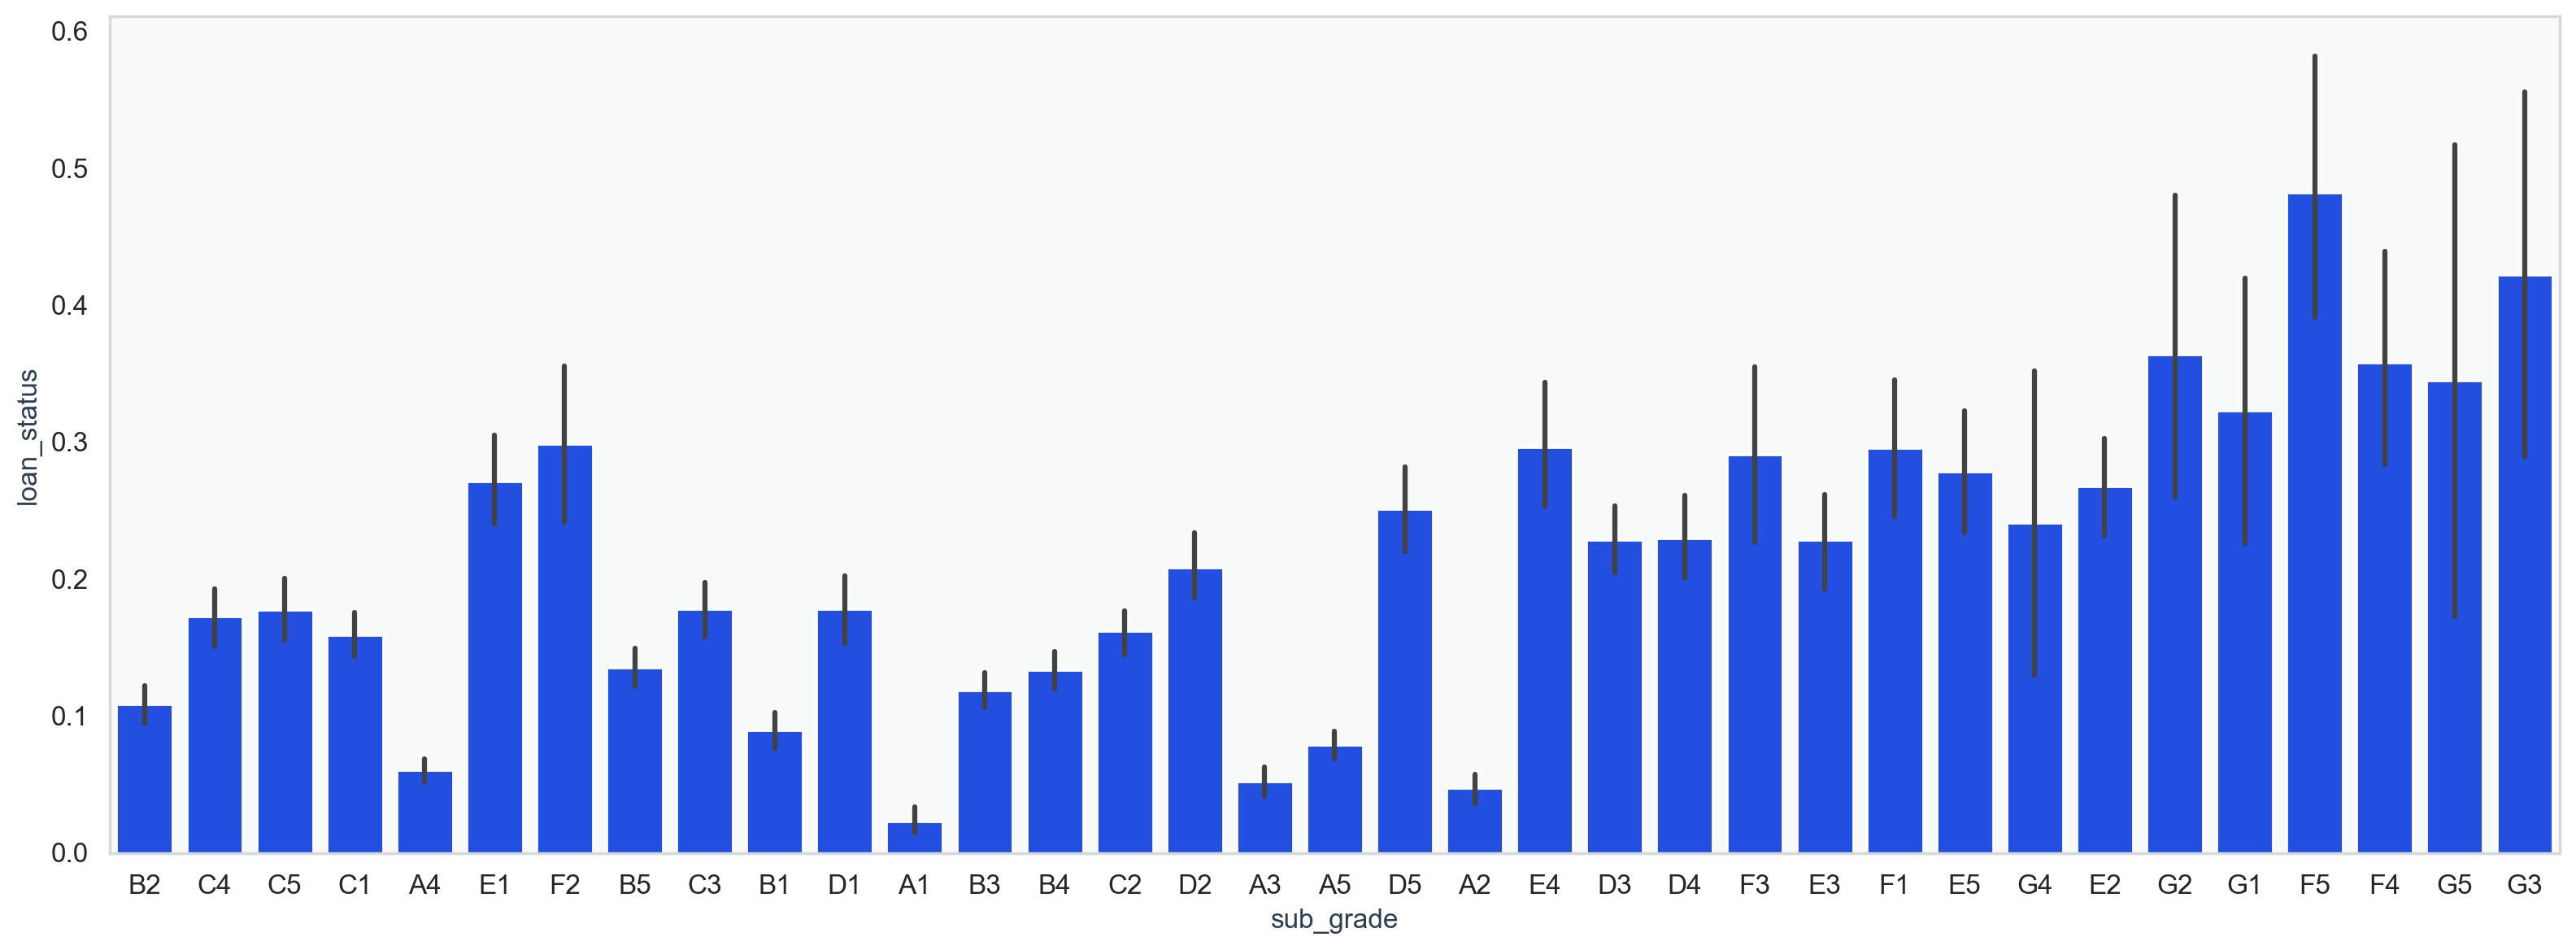

In [398]:
# sub-grade: as expected - A1 is better than A2 better than A3 and so on 
plt.figure(figsize=(16, 6))
plot_cat('sub_grade')

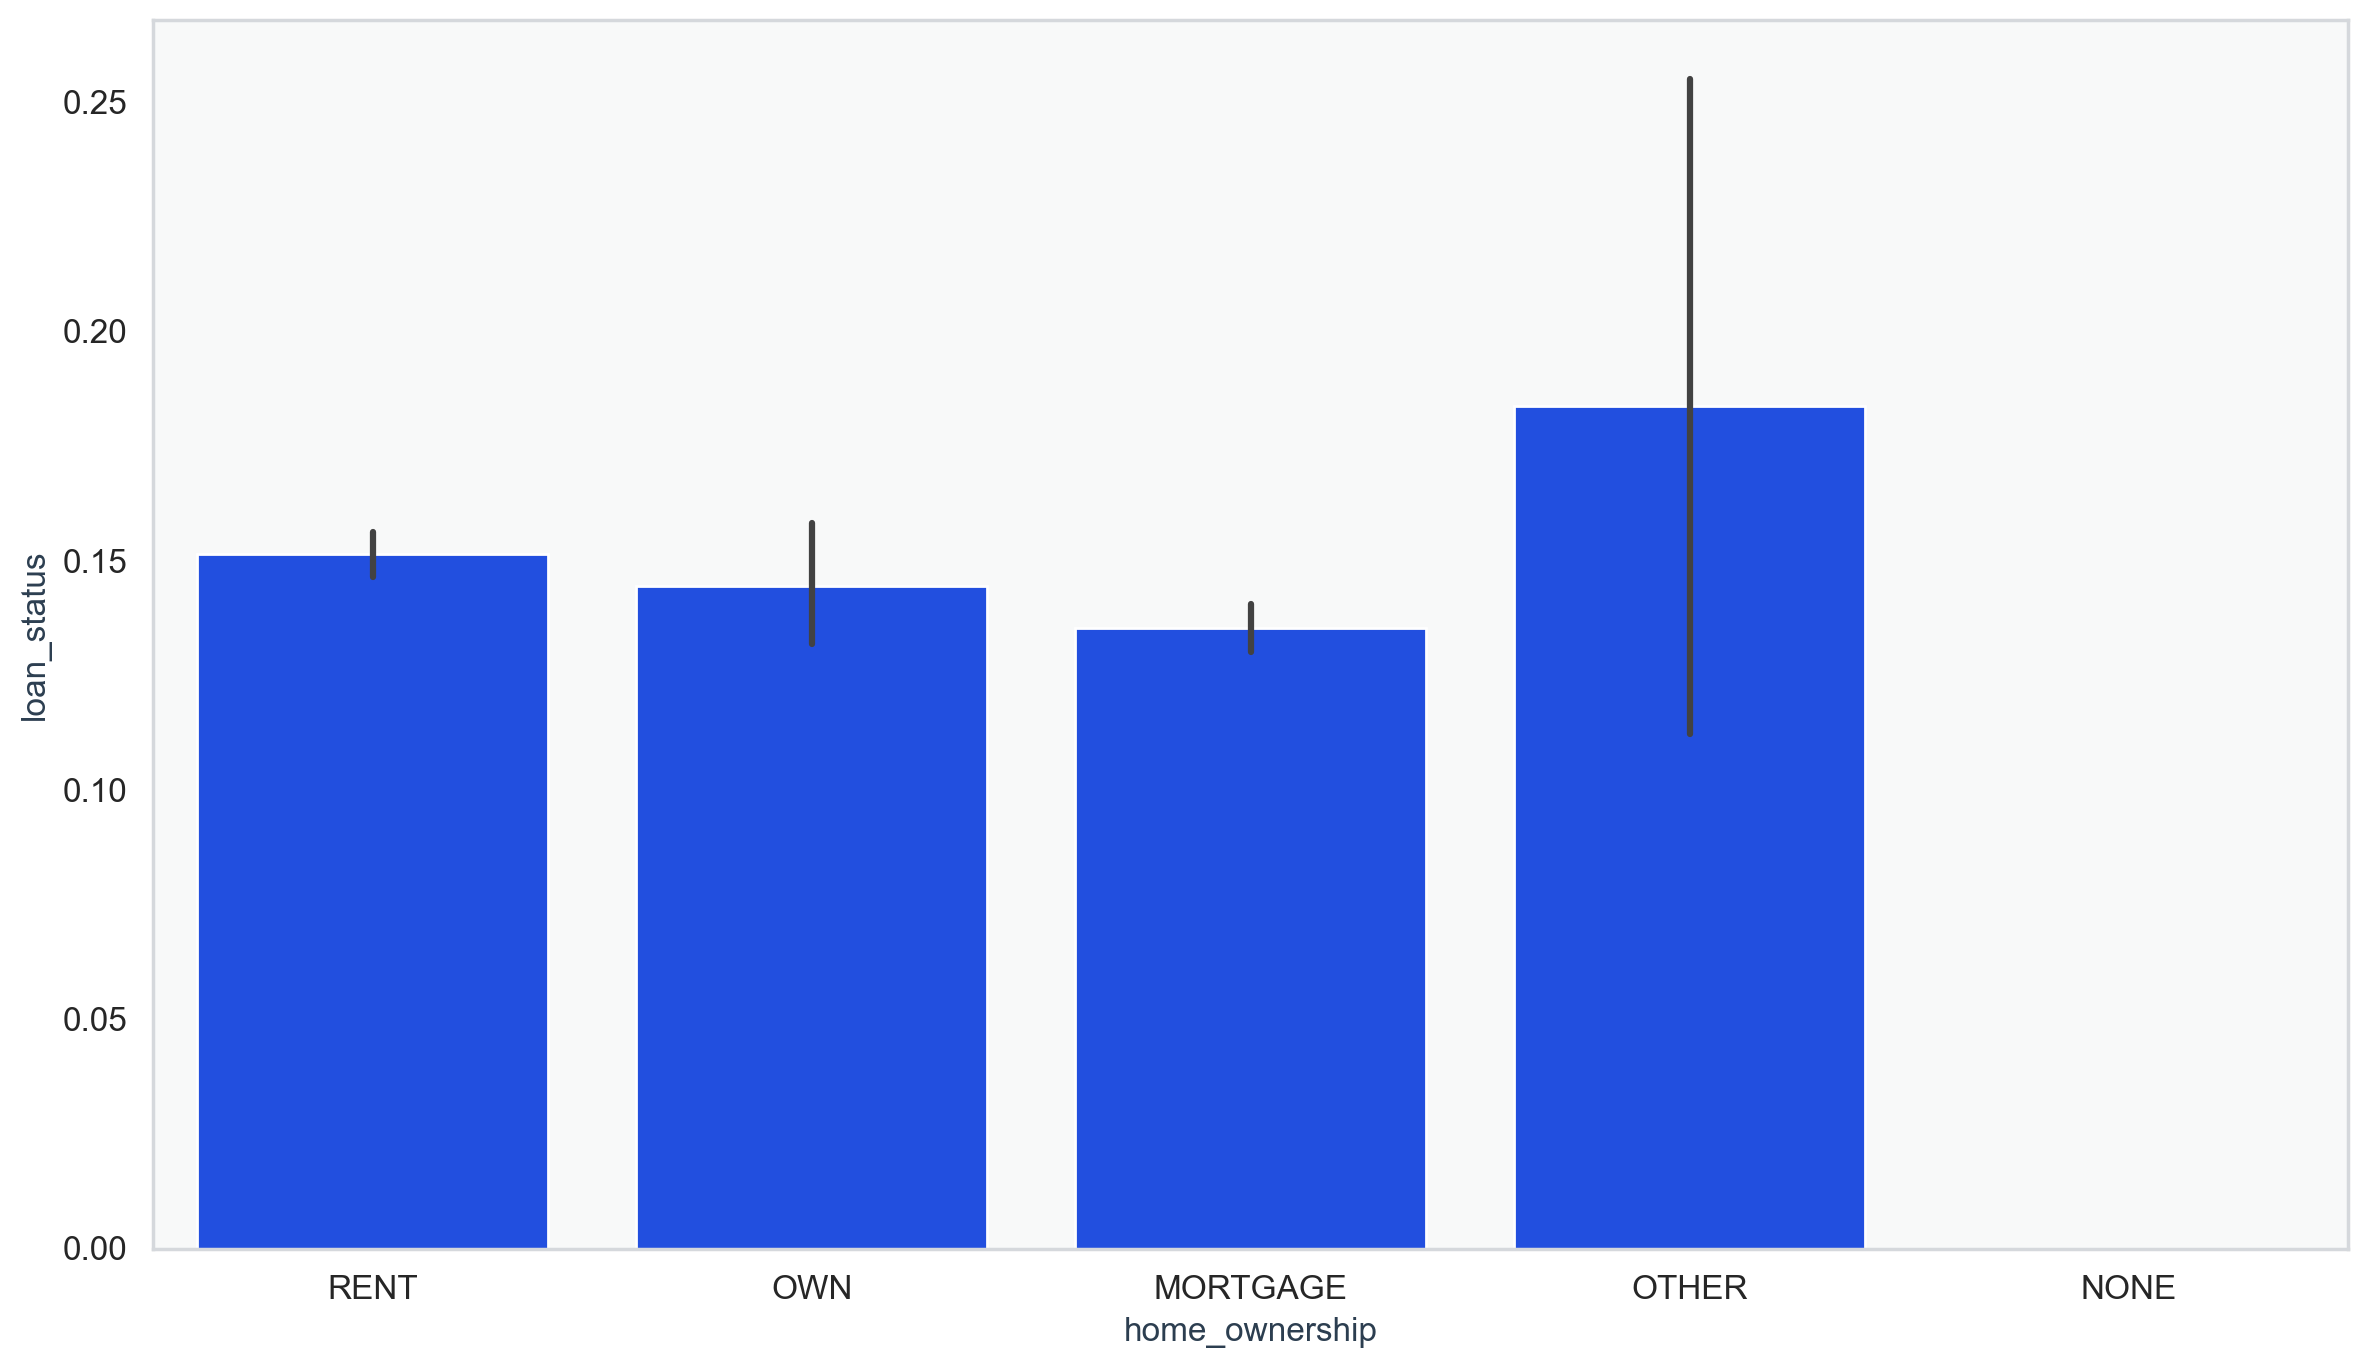

In [399]:
# home ownership: not a great discriminator
plot_cat('home_ownership')

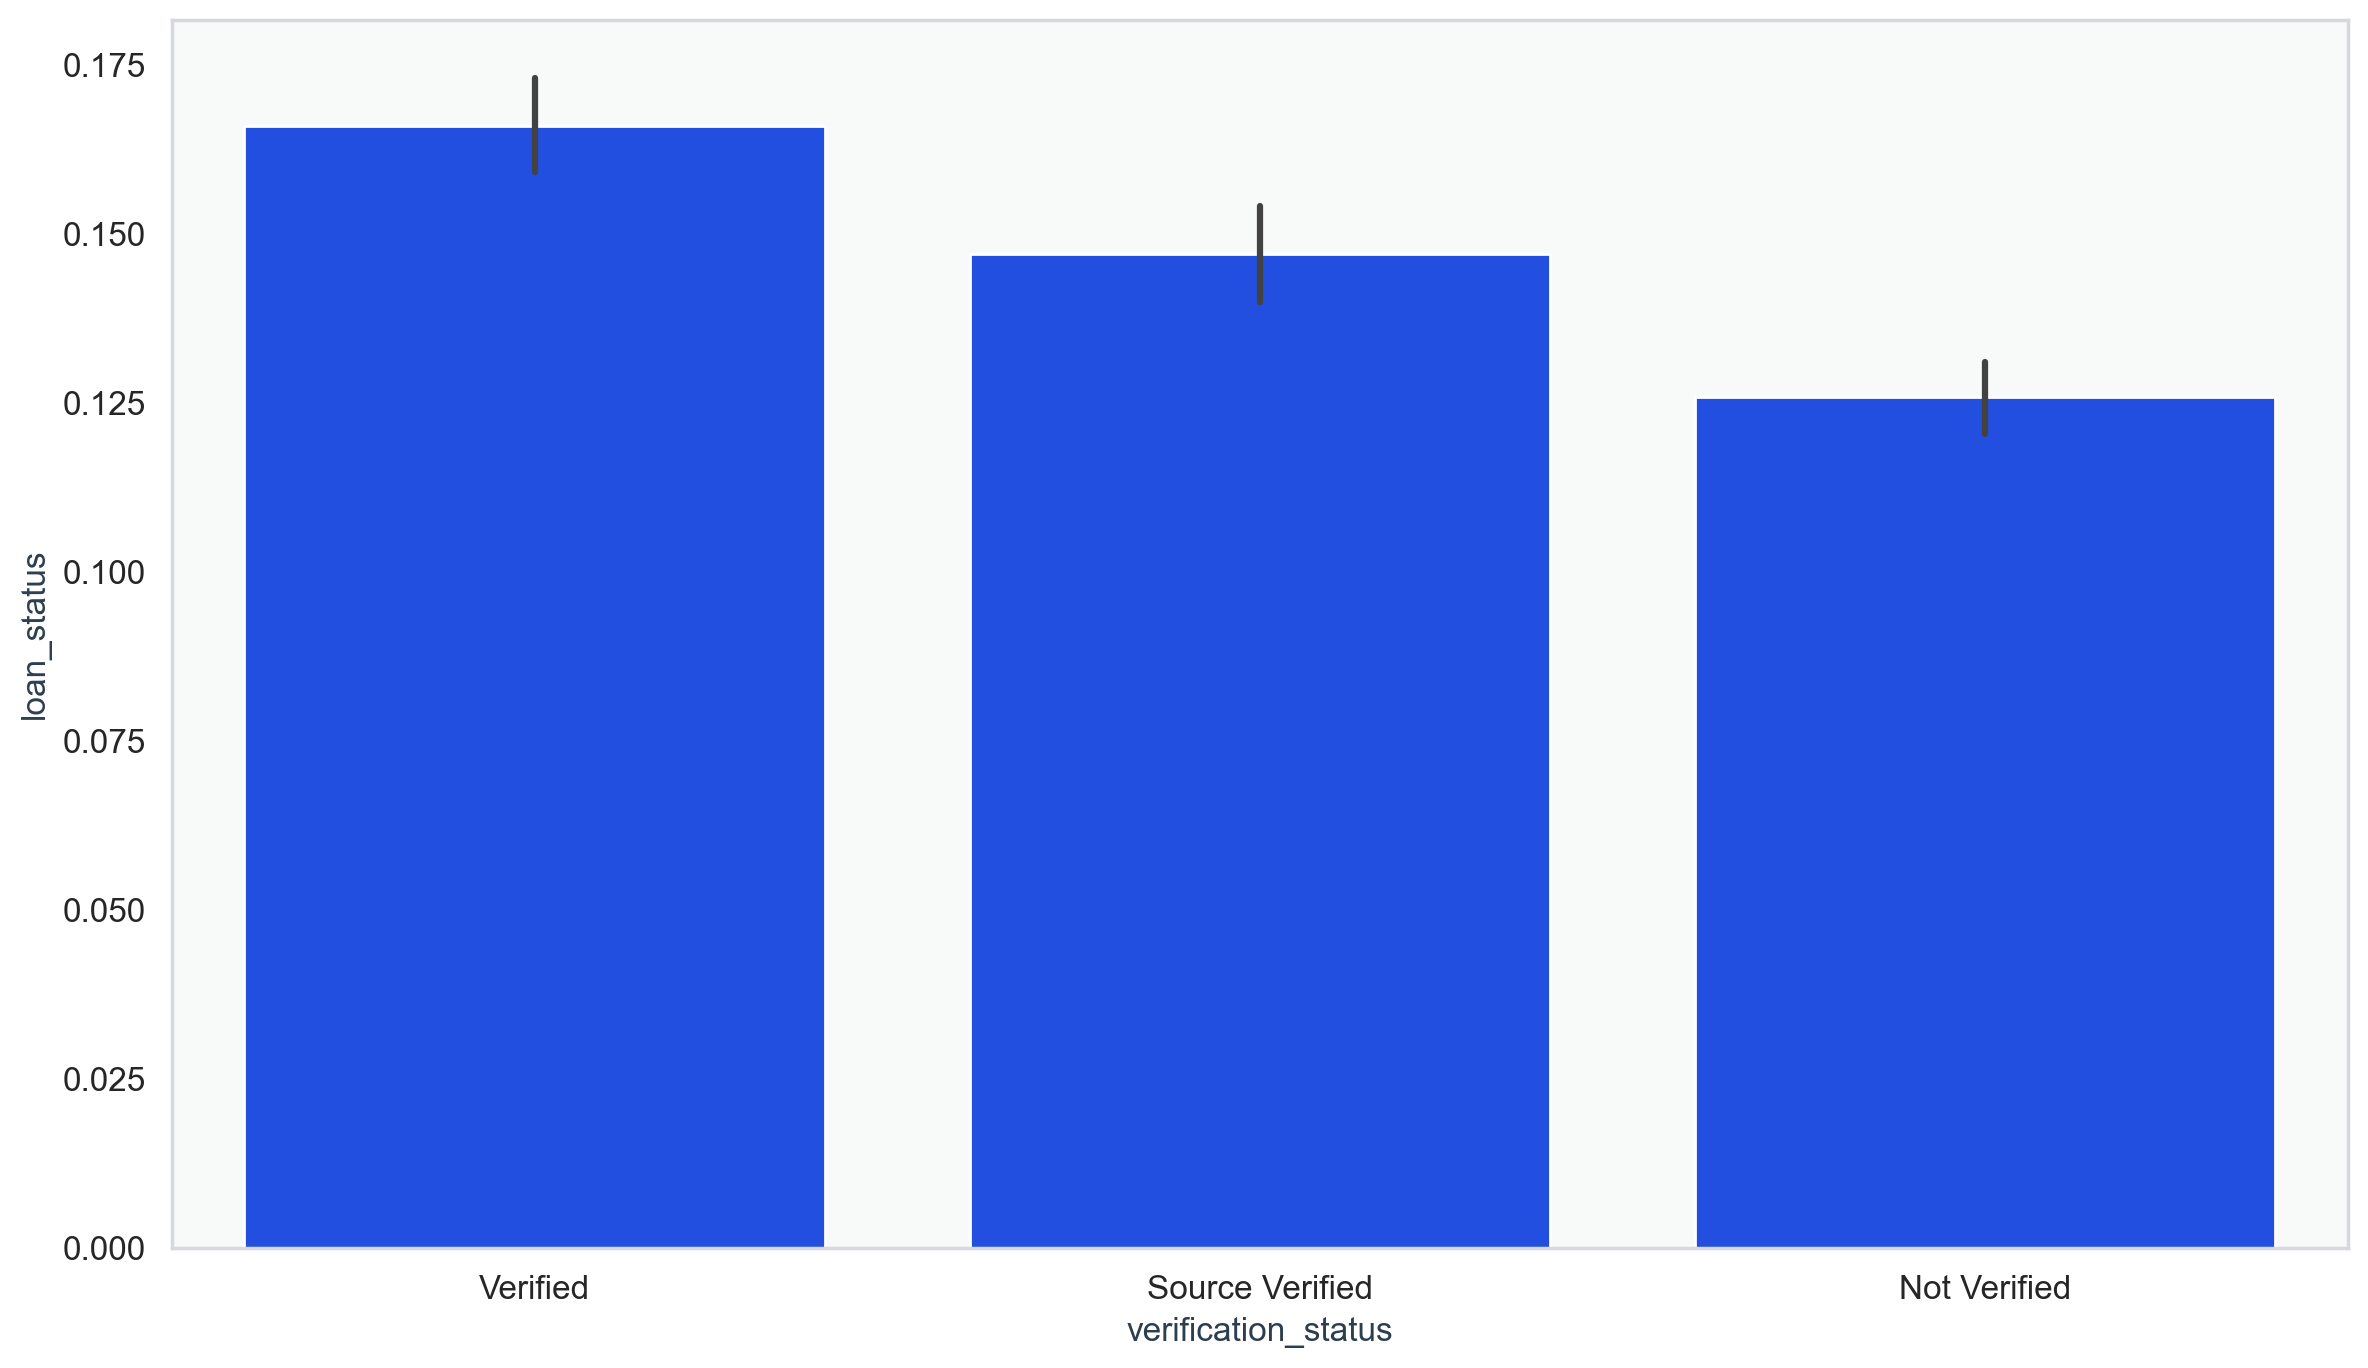

In [400]:
# verification_status: surprisingly, verified loans default more than not verifiedb
plot_cat('verification_status')

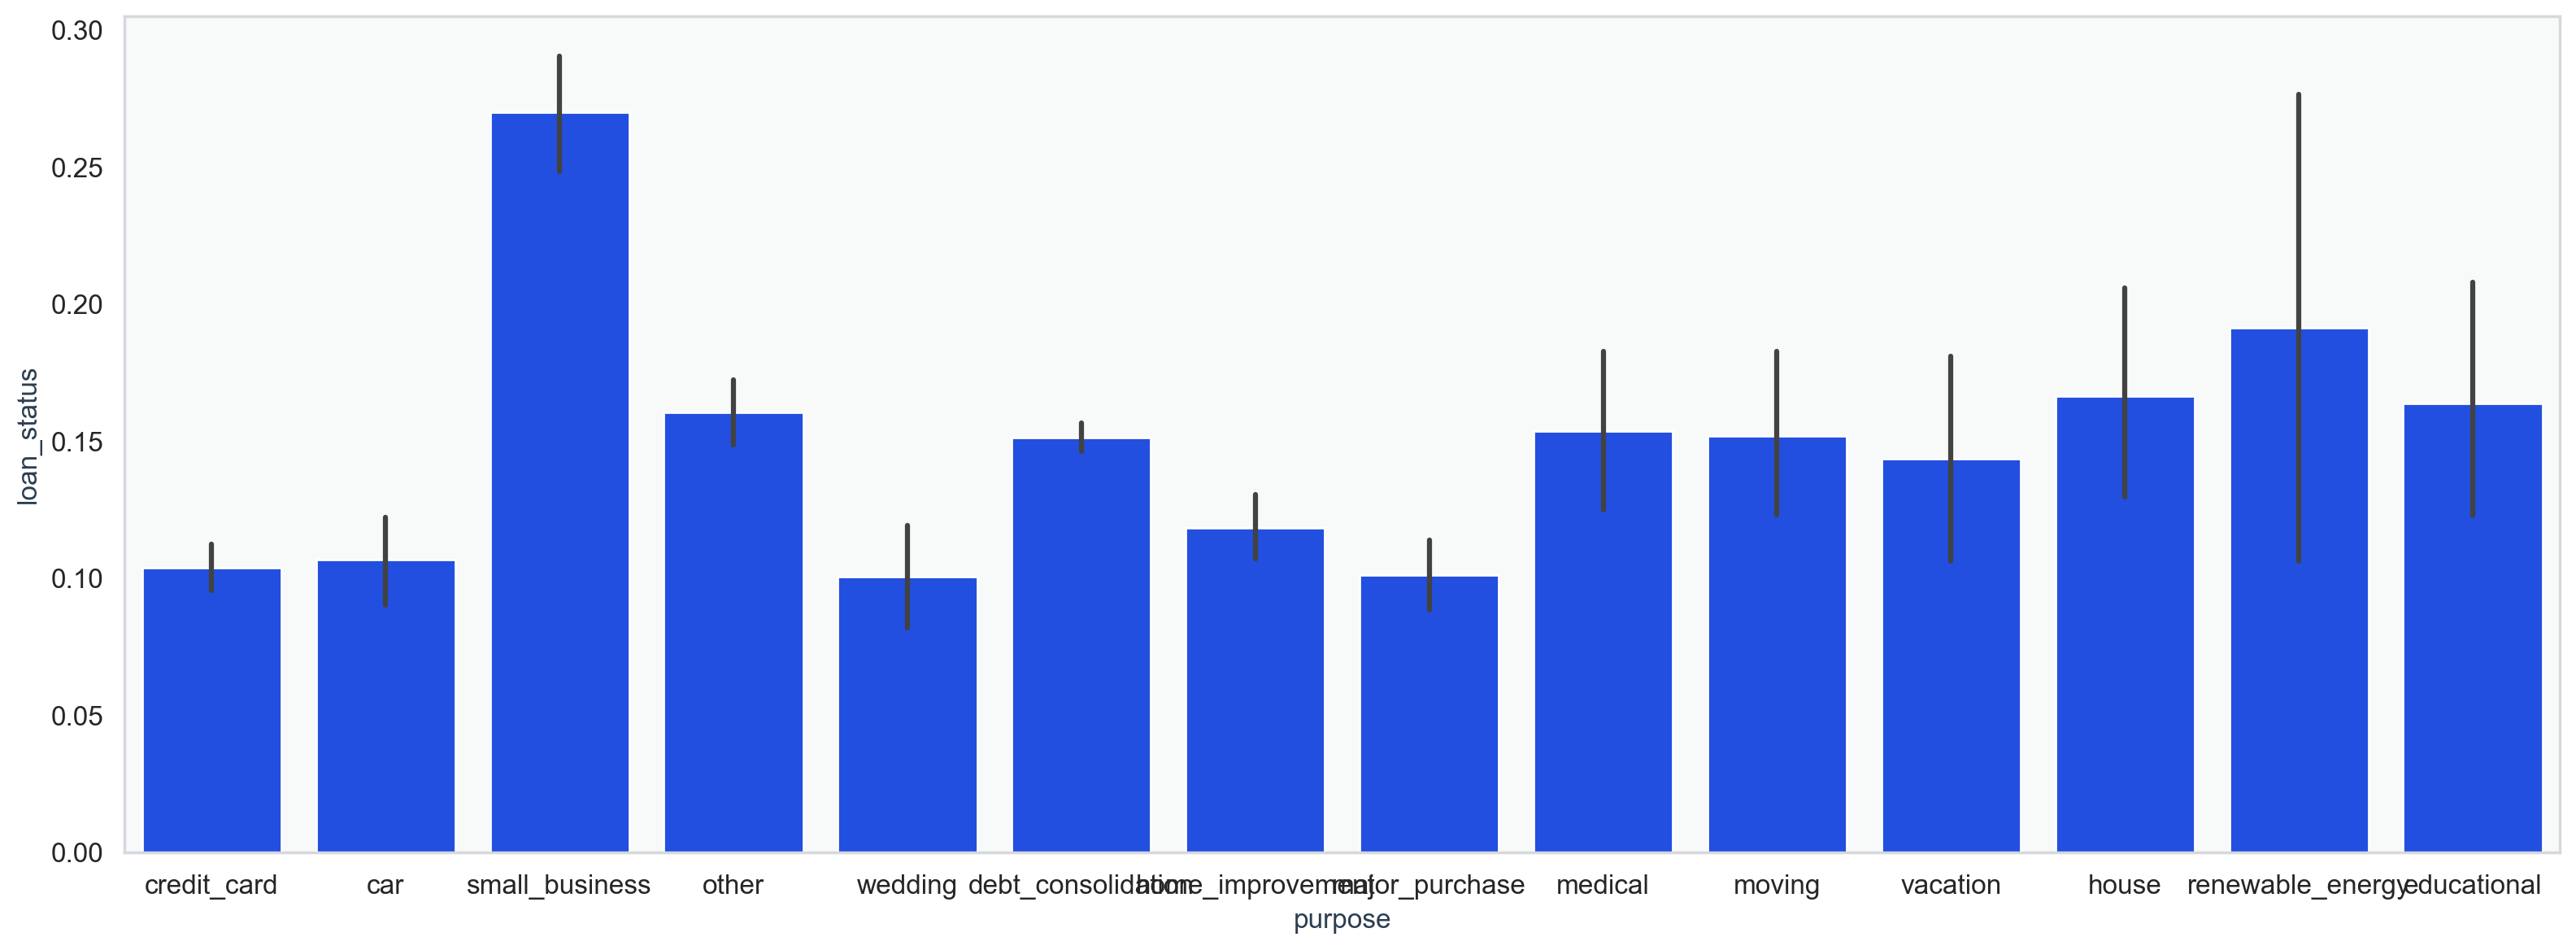

In [401]:
# purpose: small business loans defualt the most, then renewable energy and education
plt.figure(figsize=(16, 6))
plot_cat('purpose')

In [402]:
# let's also observe the distribution of loans across years
# first lets convert the year column into datetime and then extract year and month from it
df['issue_d'].head()

0    Dec-11
1    Dec-11
2    Dec-11
3    Dec-11
5    Dec-11
Name: issue_d, dtype: object

In [403]:
from datetime import datetime
df['issue_d'] = df['issue_d'].apply(lambda x: datetime.strptime(x, '%b-%y'))

In [404]:
# extracting month and year from issue_date
df['month'] = df['issue_d'].apply(lambda x: x.month)
df['year'] = df['issue_d'].apply(lambda x: x.year)


In [405]:
# let's first observe the number of loans granted across years
df.groupby('year').year.count()

year
2007      251
2008     1562
2009     4716
2010    11214
2011    19801
Name: year, dtype: int64

You can see that the number of loans has increased steadily across years.

In [406]:
df.groupby('month').month.count()

month
1     2331
2     2278
3     2632
4     2756
5     2838
6     3094
7     3253
8     3321
9     3394
10    3637
11    3890
12    4120
Name: month, dtype: int64

Most loans are granted in December, and in general in the latter half of the year.



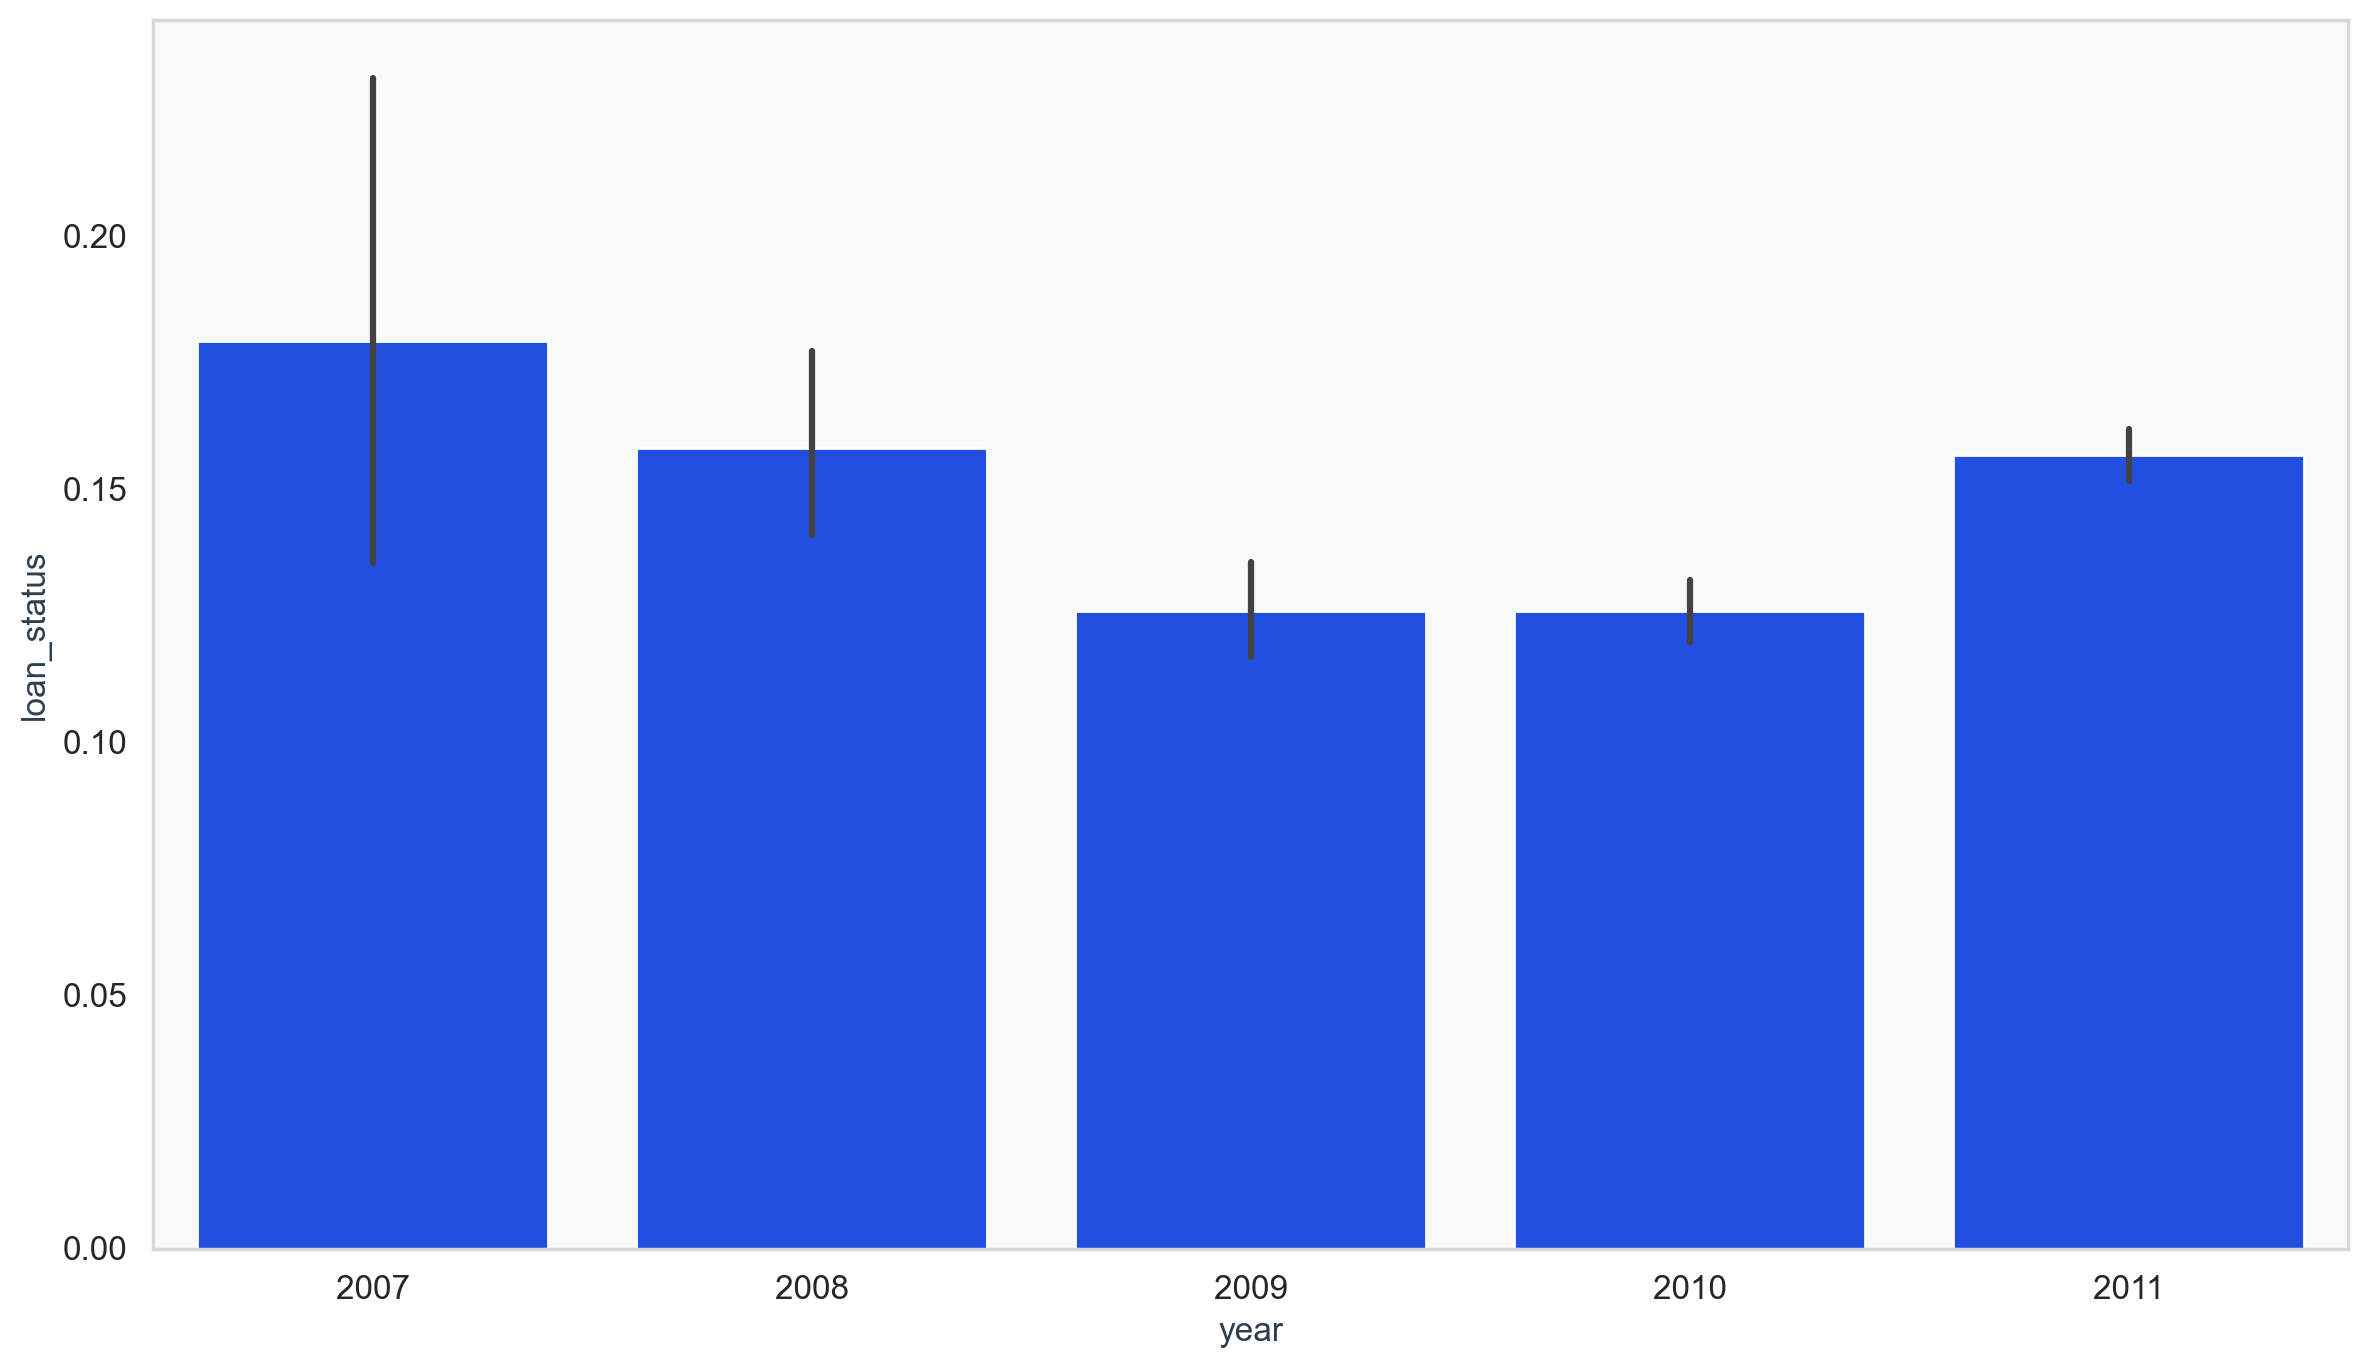

In [407]:
# lets compare the default rates across years
# the default rate had suddenly increased in 2011, inspite of reducing from 2008 till 2010
plot_cat('year')

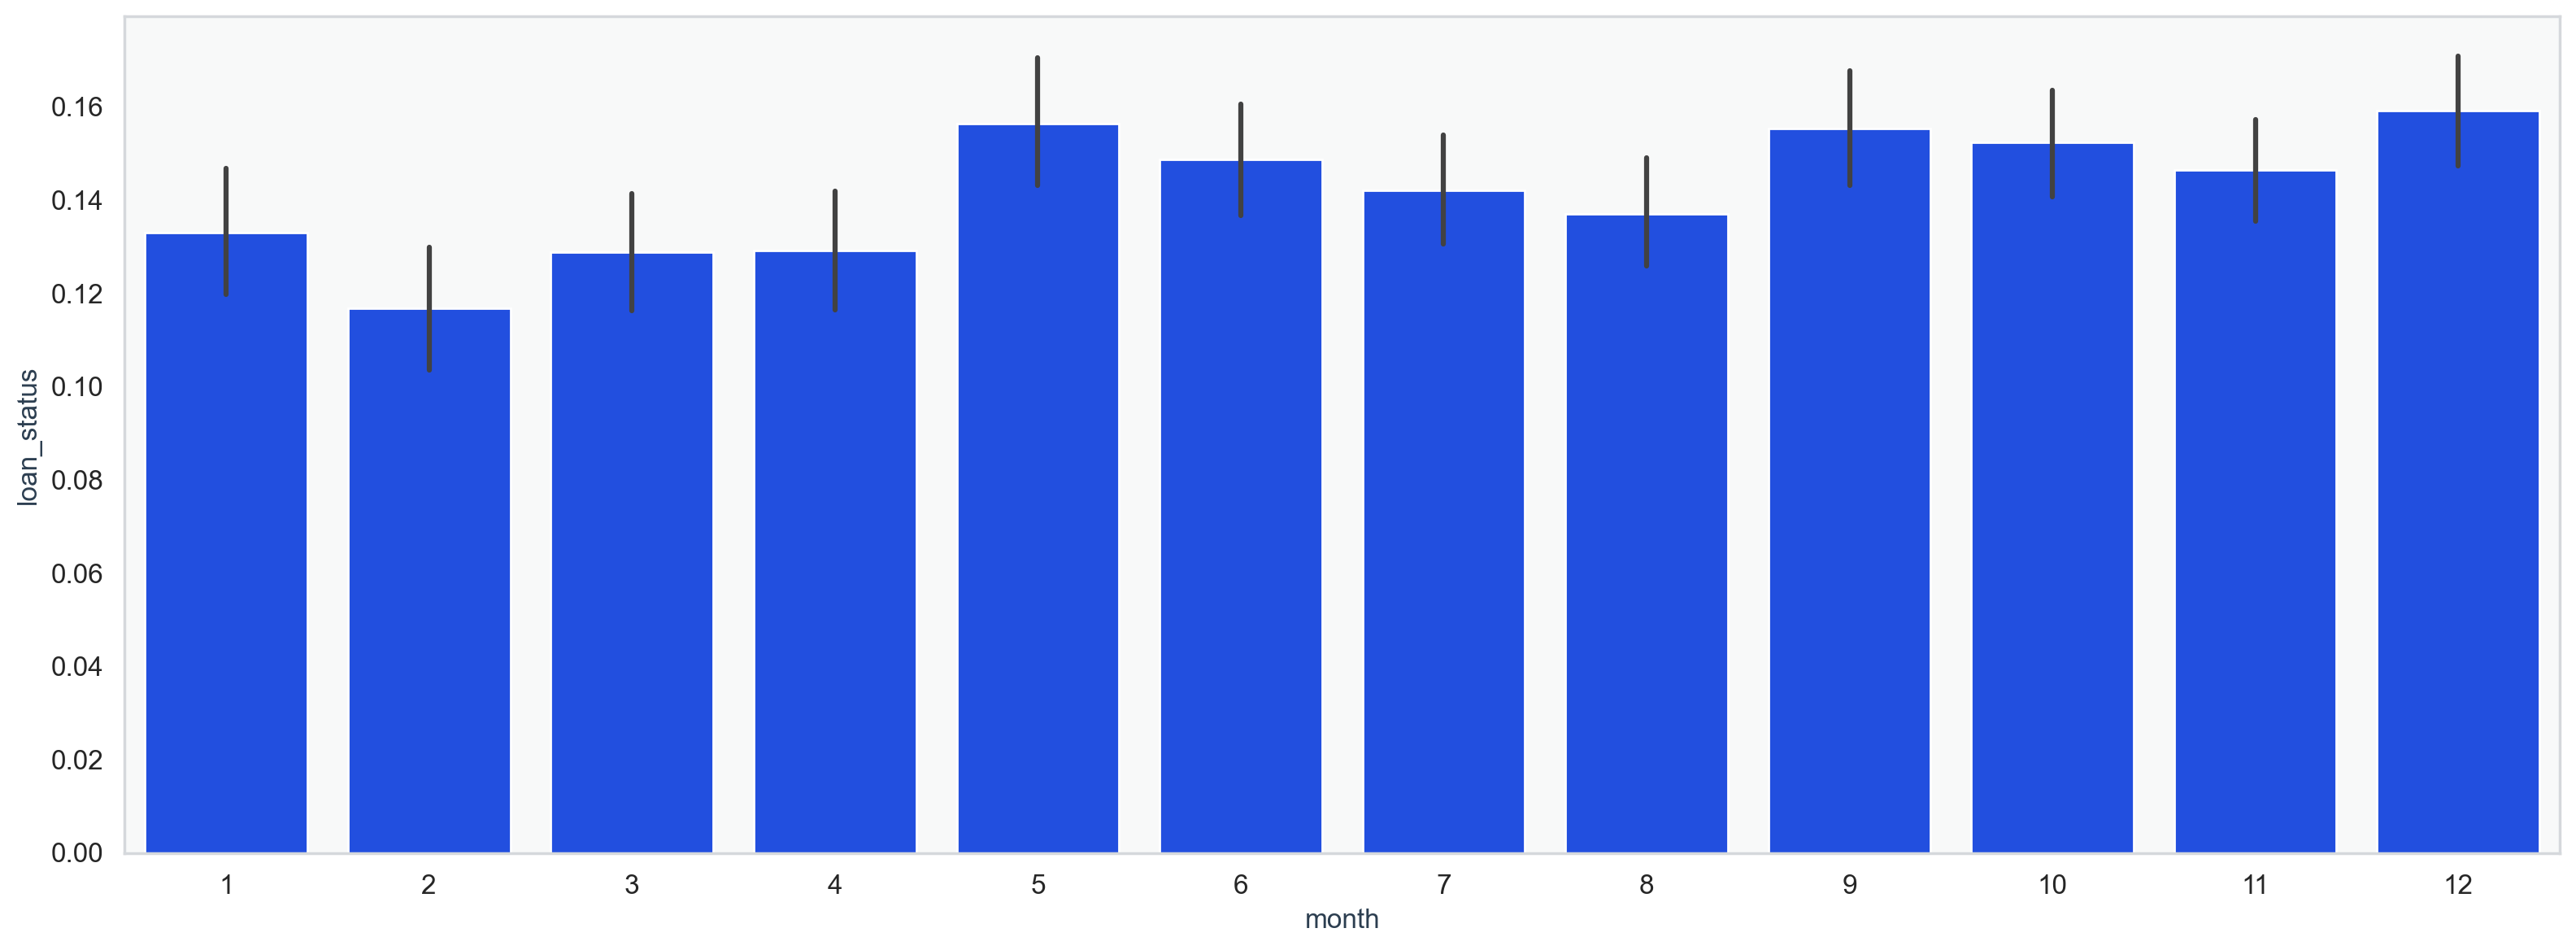

In [408]:
plt.figure(figsize=(16, 6))
plot_cat('month')

Let's now analyse how the default rate varies across continuous variables.

Let's now analyse how the default rate varies across continuous variables.

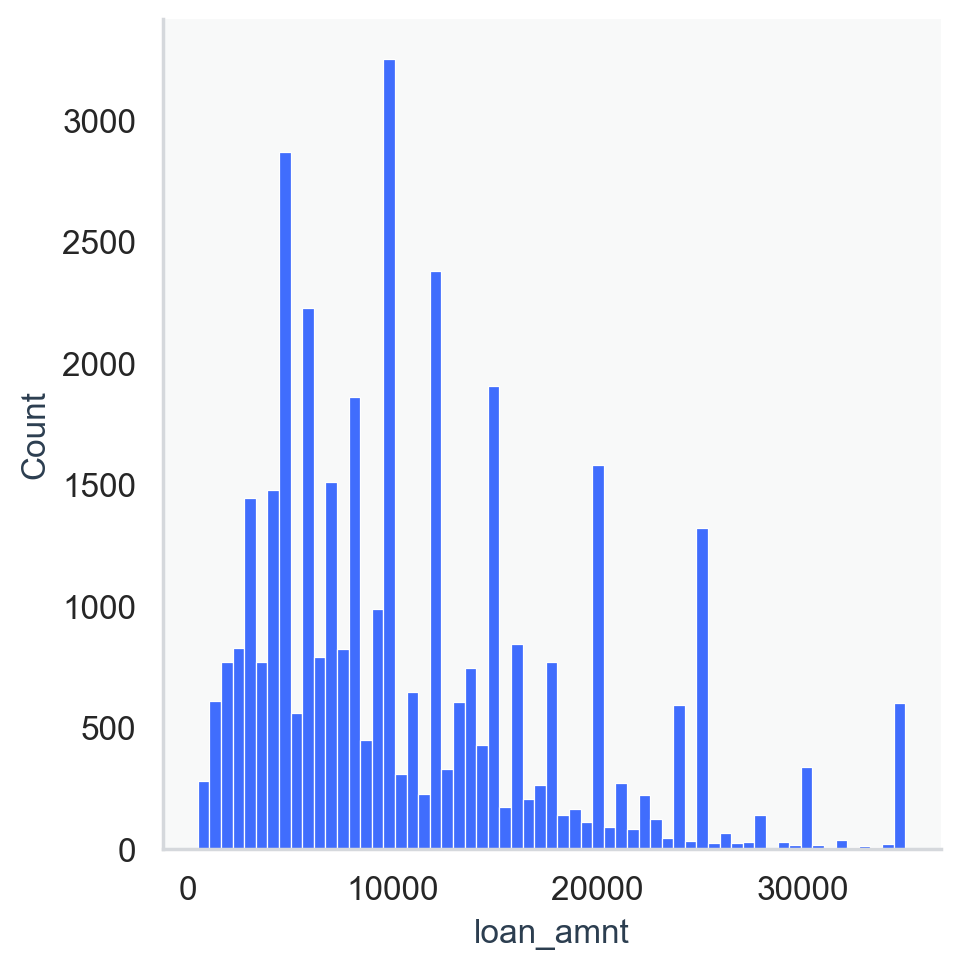

In [409]:
# loan amount: the median loan amount is around 10,000
sns.displot(df['loan_amnt'])
plt.show()

The easiest way to analyse how default rates vary across continous variables is to bin the variables into discrete categories.

Let's bin the loan amount variable into small, medium, high, very high.

In [410]:
# binning loan amount
def loan_amount(n):
    if n < 5000:
        return 'low'
    elif n >=5000 and n < 15000:
        return 'medium'
    elif n >= 15000 and n < 25000:
        return 'high'
    else:
        return 'very high'
        
df['loan_amnt'] = df['loan_amnt'].apply(lambda x: loan_amount(x))


In [411]:
df['loan_amnt'].value_counts()

loan_amnt
medium       20157
high          7572
low           7095
very high     2720
Name: count, dtype: int64

In [412]:
import seaborn as sns
import matplotlib.pyplot as plt

# Navy and Gold tones
luxury_palette = ["#1B263B", "#415A77", "#778DA9", "#E0E1DD", "#A3822F"]

sns.set_theme(style="ticks", palette=luxury_palette)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titlesize': 24,
    'axes.titlecolor': '#1B263B',
    'axes.labelcolor': '#415A77'
})

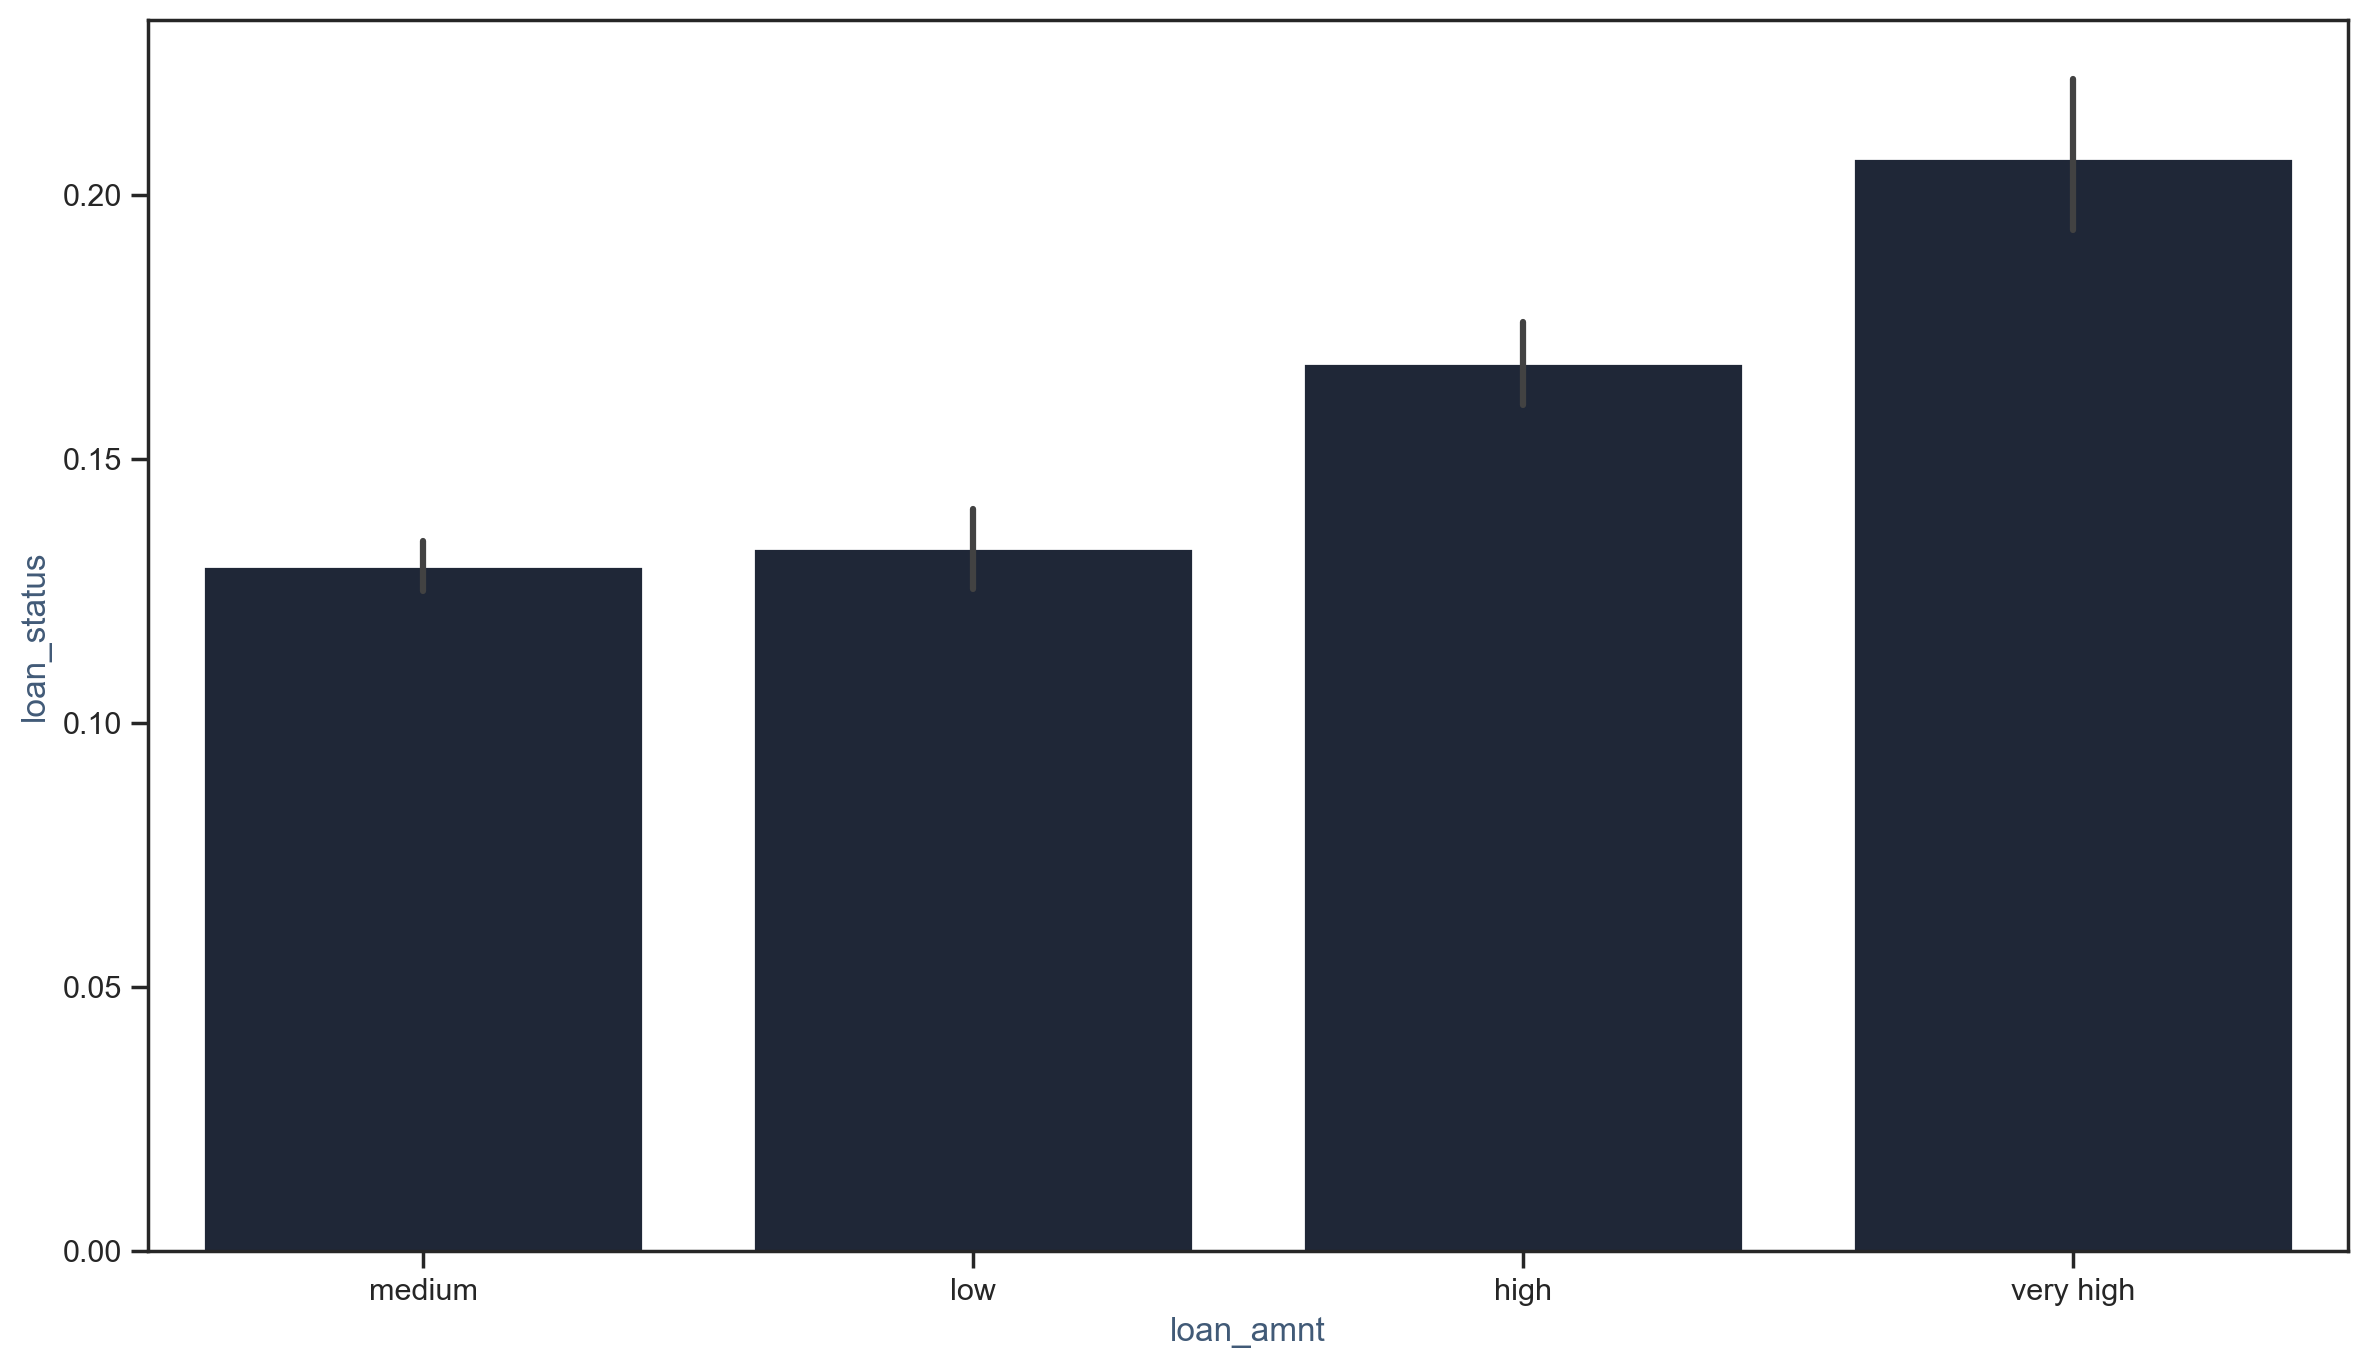

In [413]:
# let's compare the default rates across loan amount type
# higher the loan amount, higher the default rate
plot_cat('loan_amnt')

In [414]:
# let's also convert funded amount invested to bins
df['funded_amnt_inv'] = df['funded_amnt_inv'].apply(lambda x: loan_amount(x))

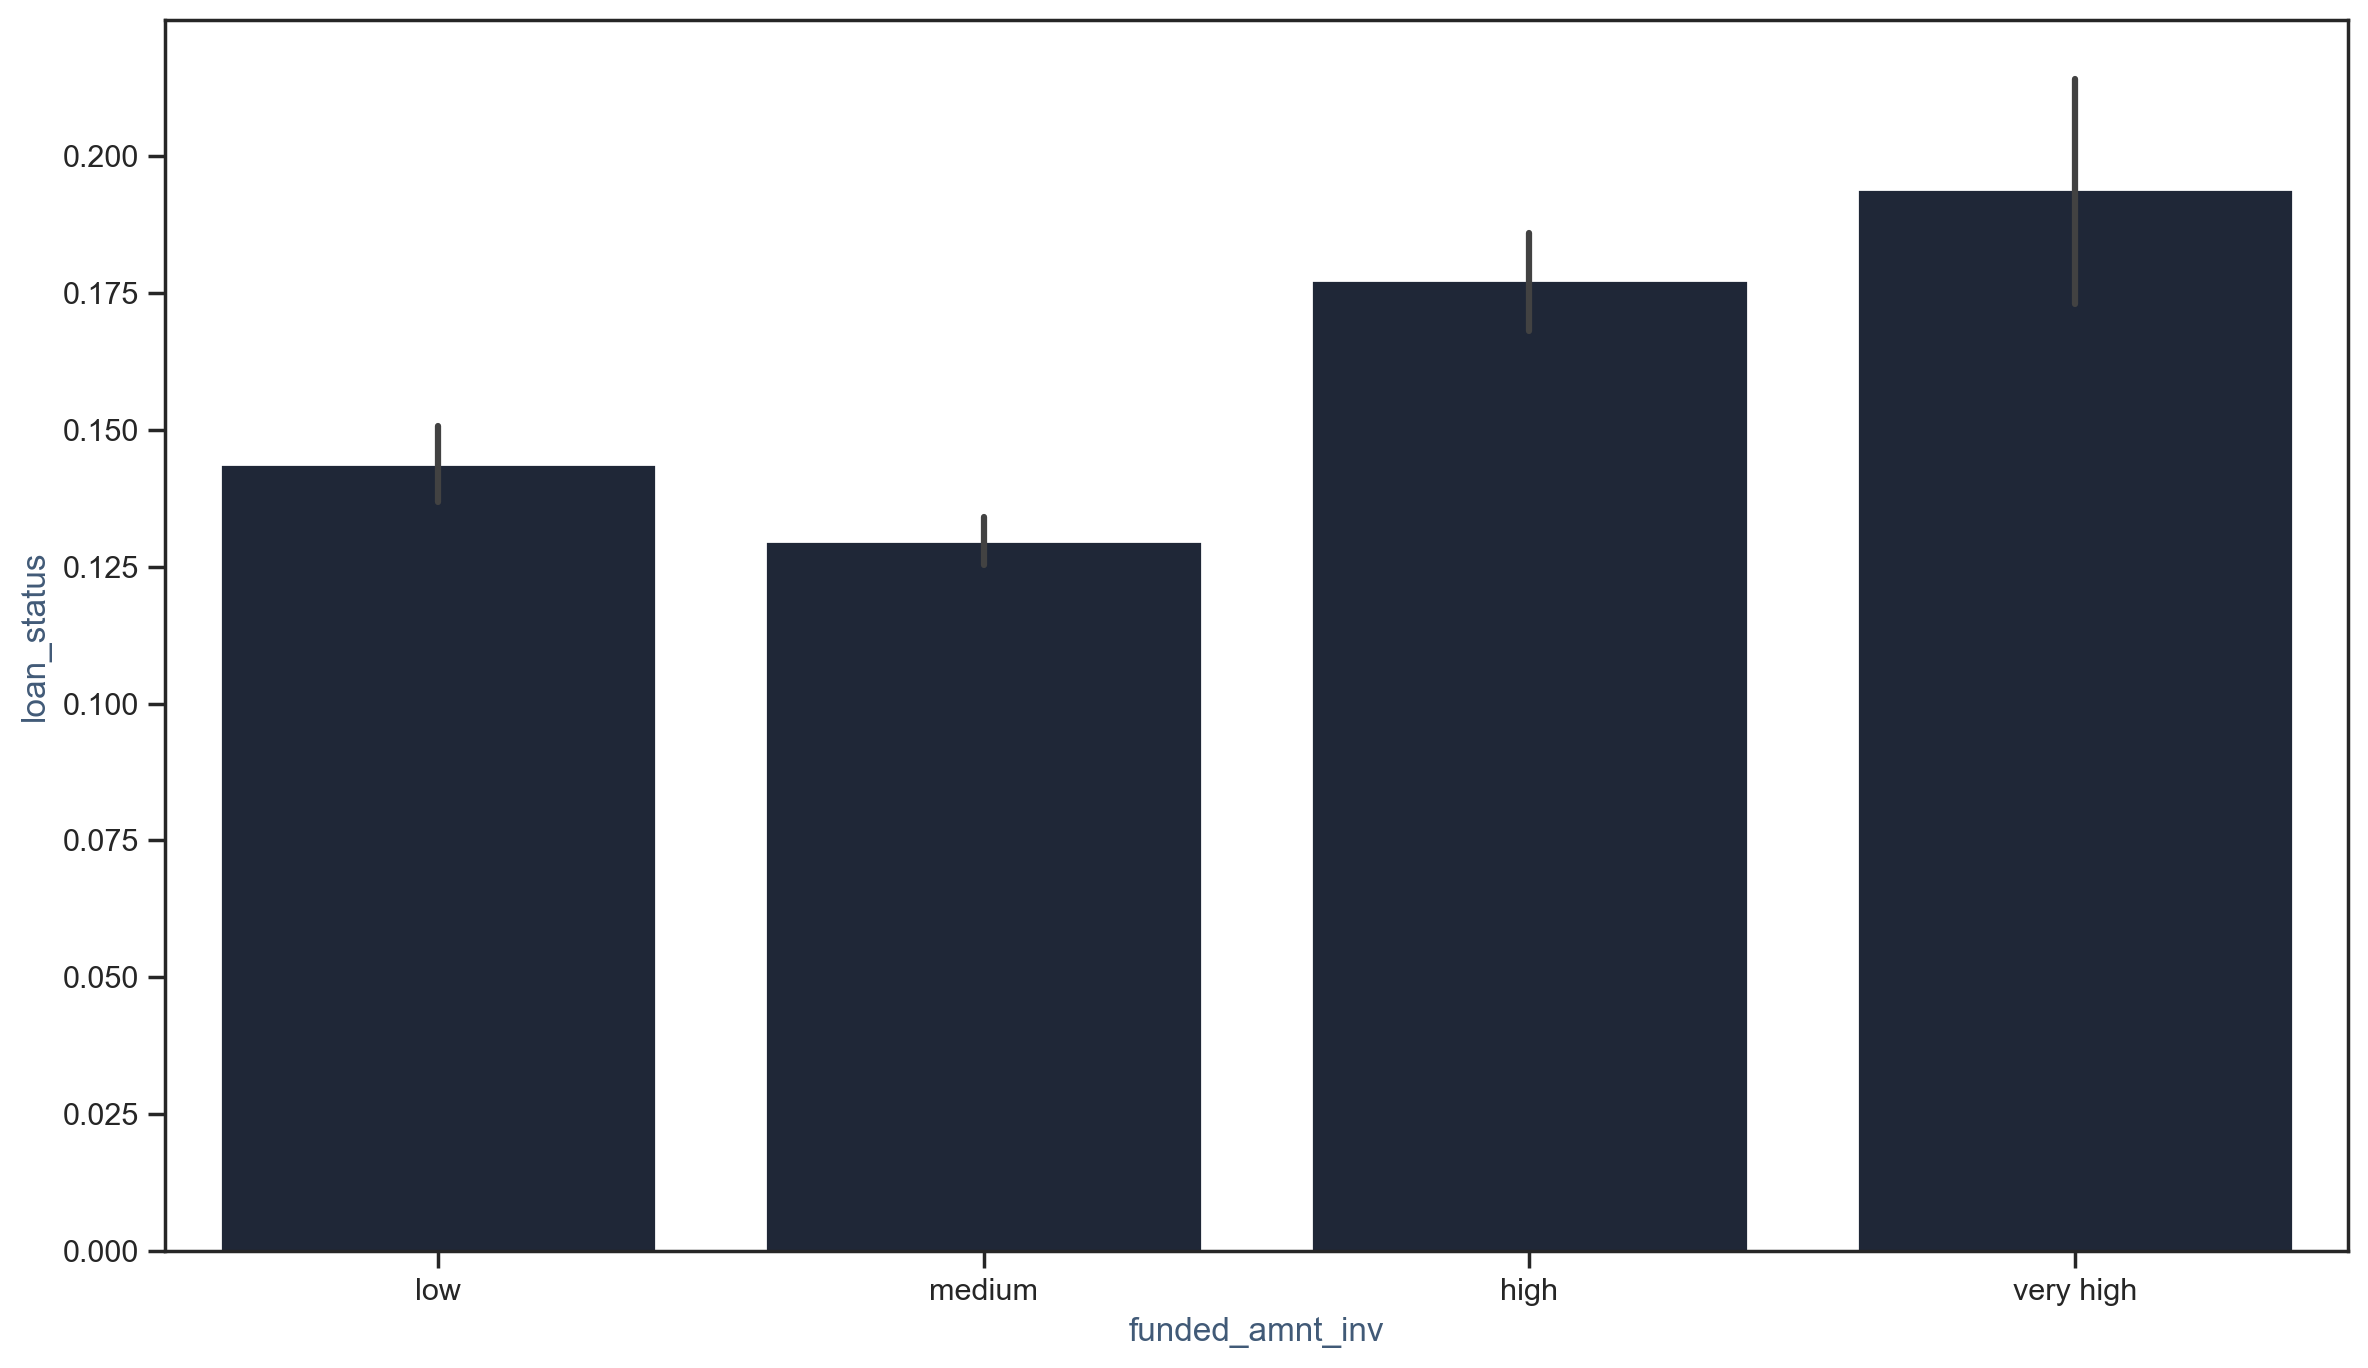

In [415]:
plot_cat('funded_amnt_inv')

In [416]:
# lets also convert interest rate to low, medium, high
# binning loan amount
def int_rate(n):
    if n <= 10:
        return 'low'
    elif n > 10 and n <=15:
        return 'medium'
    else:
        return 'high'
    
    
df['int_rate'] = df['int_rate'].apply(lambda x: int_rate(x))

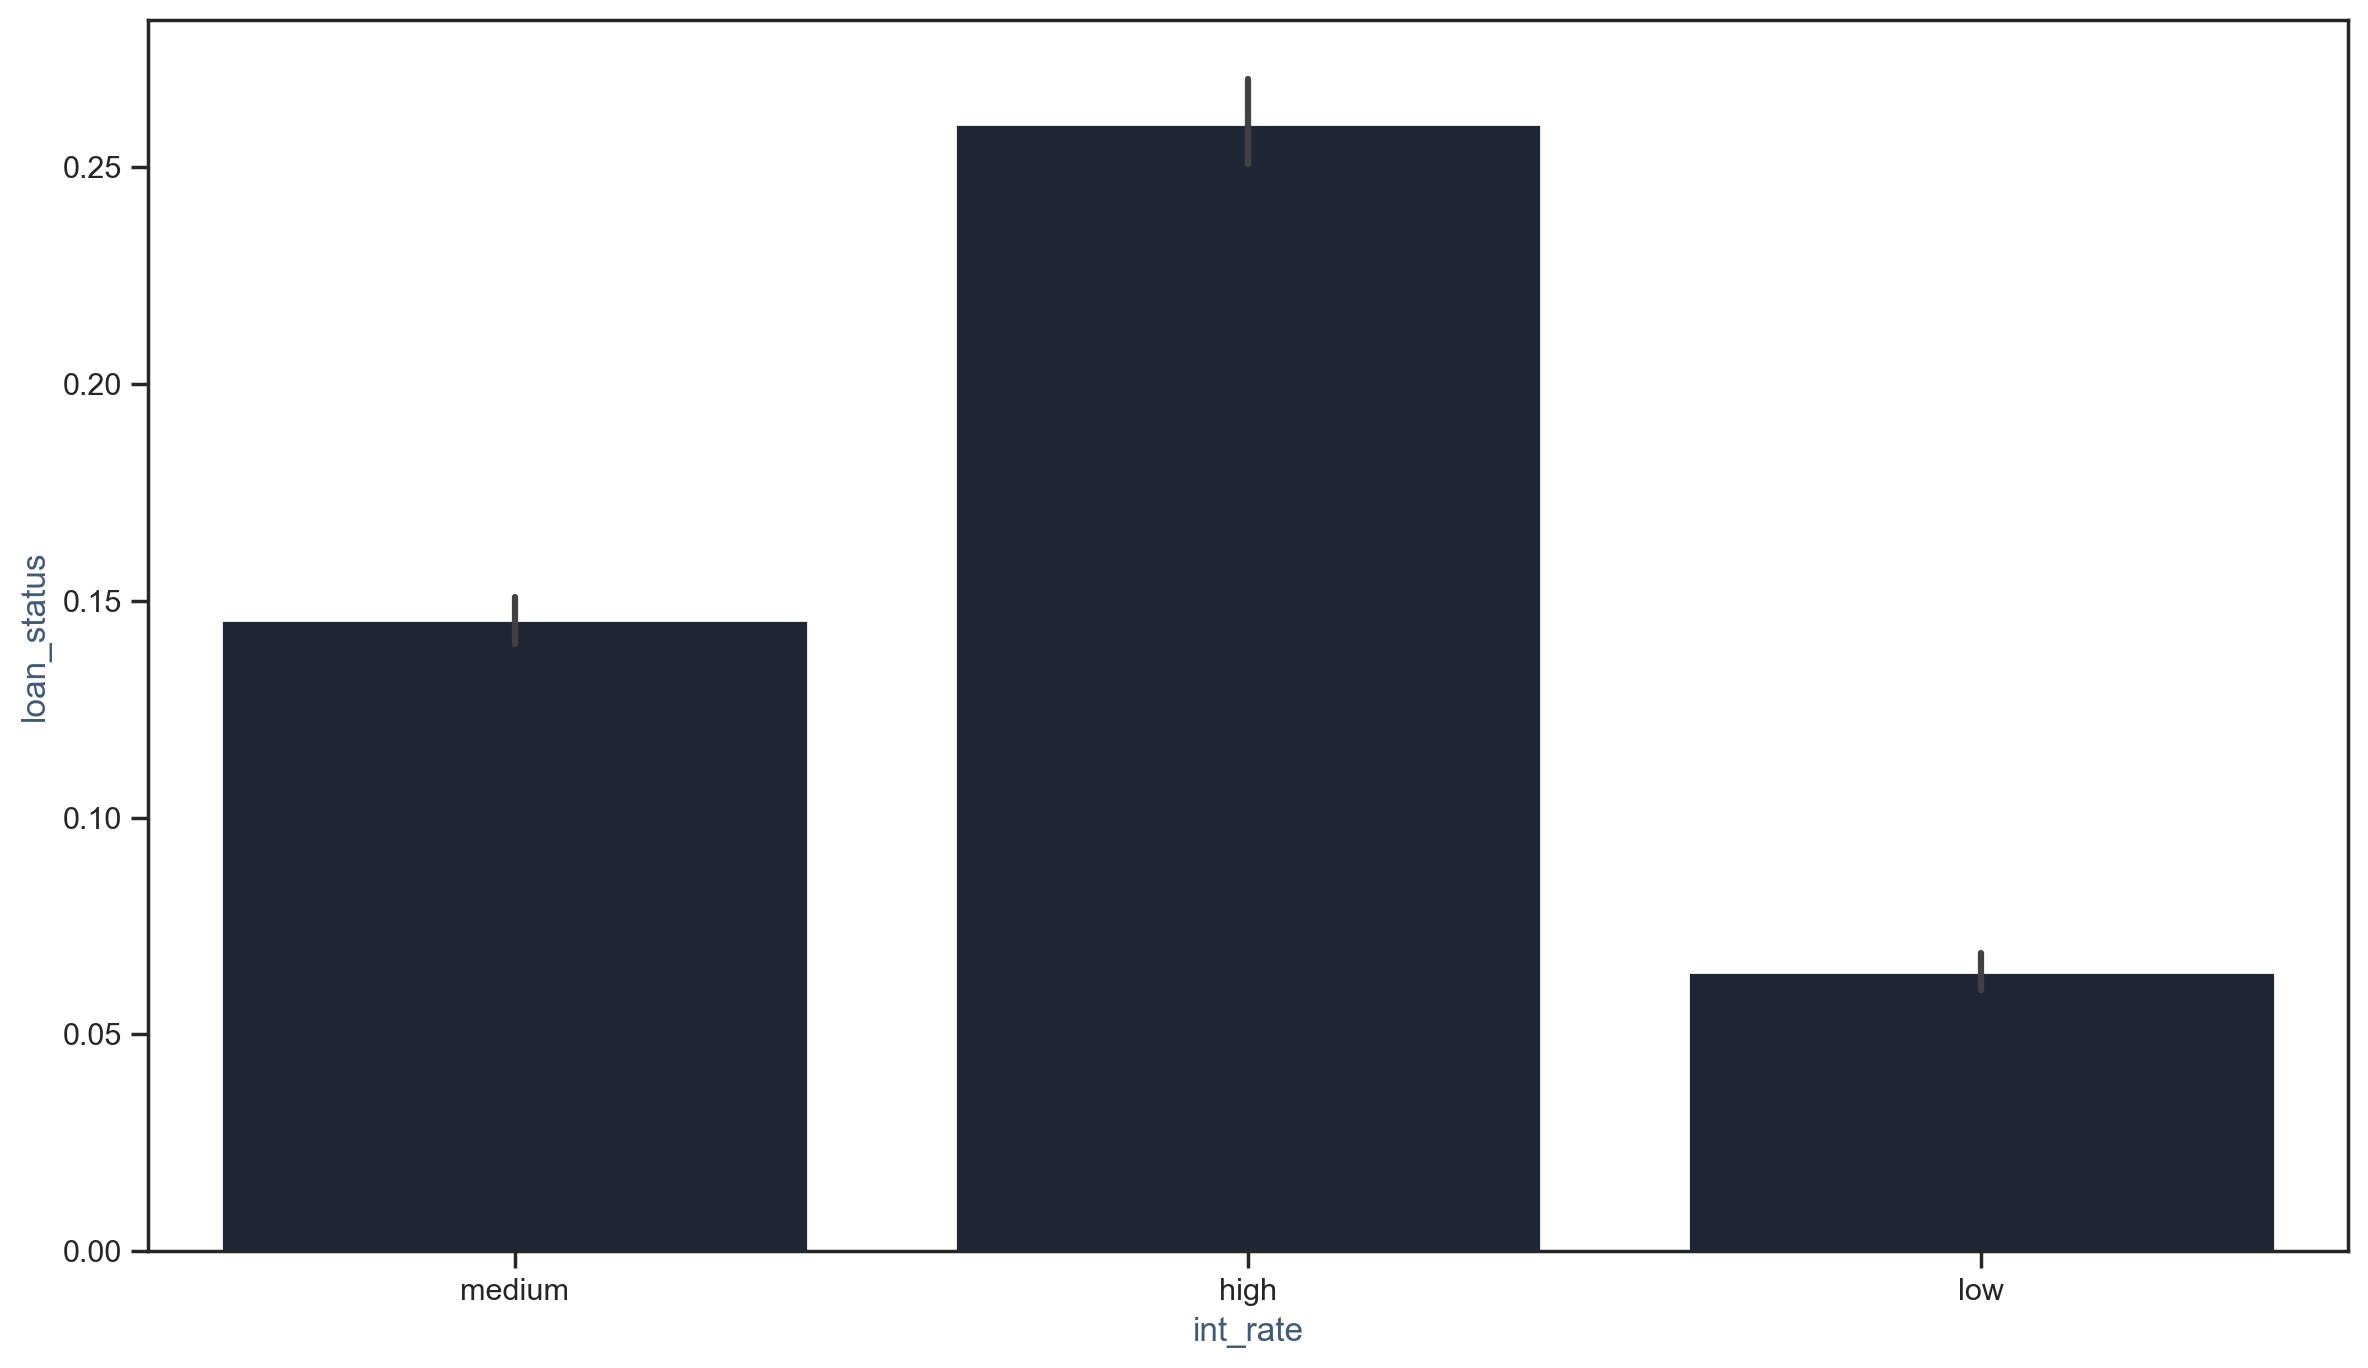

In [417]:
plot_cat('int_rate')

In [418]:
def dti(n):
    if n <= 10:
        return 'low'
    elif n > 10 and n <=20:
        return 'medium'
    else:
        return 'high'
    

df['dti'] = df['dti'].apply(lambda x: dti(x))

In [419]:
# comparing default rates across debt to income ratio
# high dti translates into higher default rates, as expected

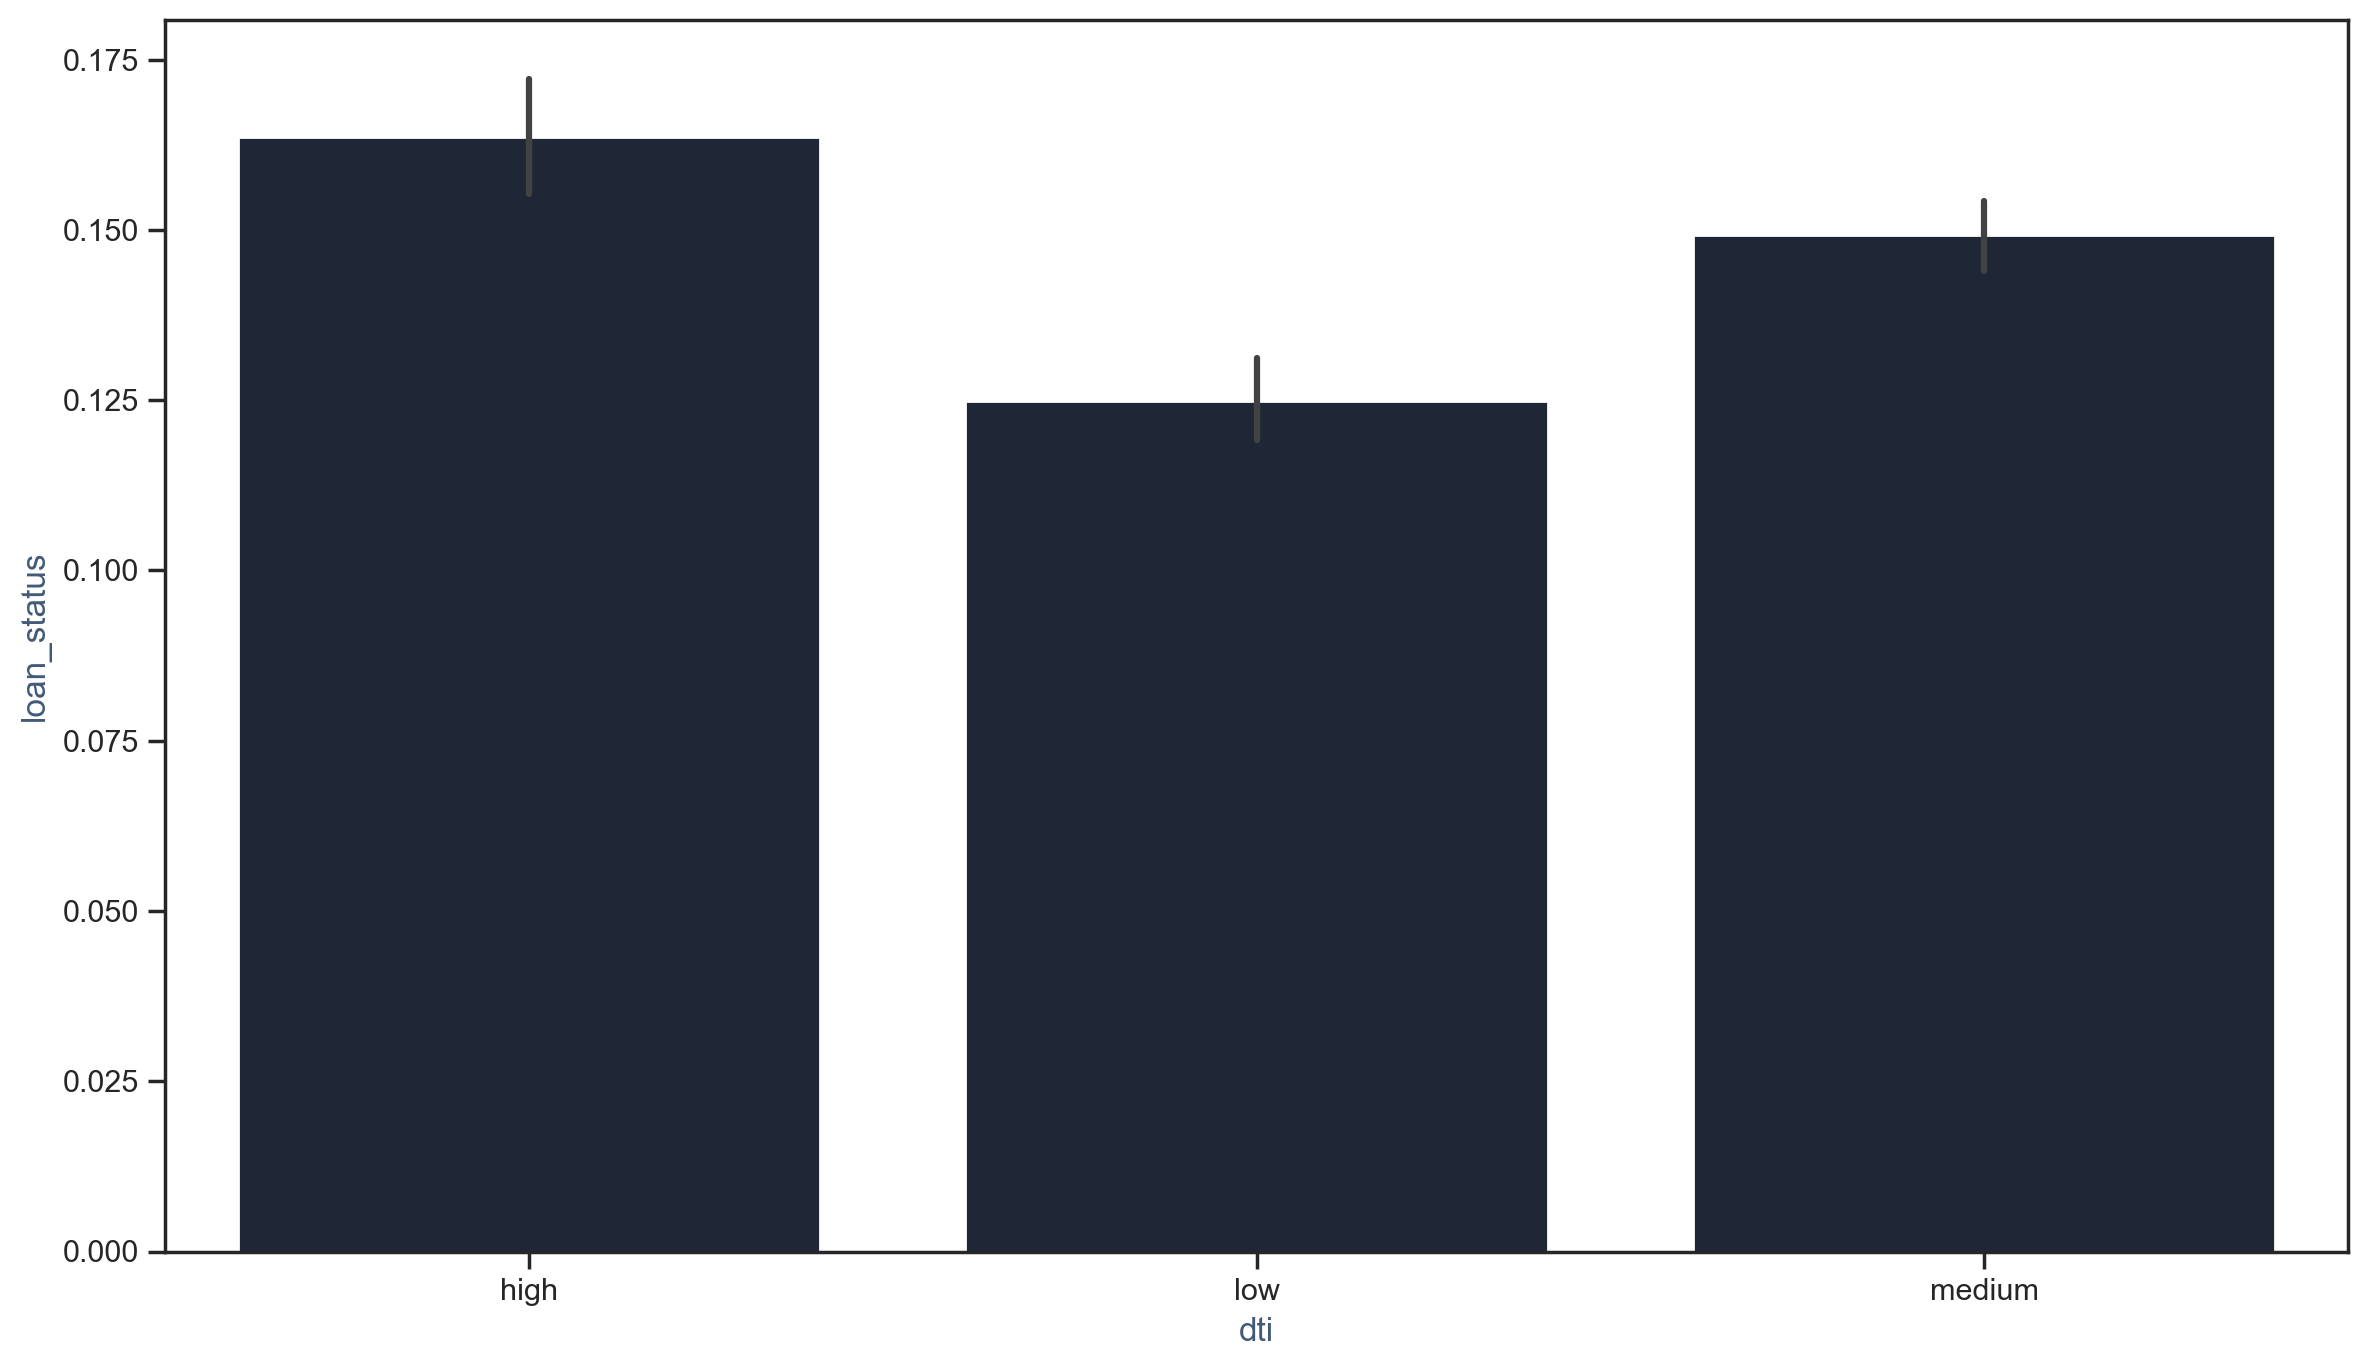

In [420]:
plot_cat('dti')

In [421]:
def funded_amount(n):
    if n <= 5000:
        return 'low'
    elif n > 5000 and n <=15000:
        return 'medium'
    else:
        return 'high'
    
df['funded_amnt'] = df['funded_amnt'].apply(lambda x: funded_amount(x))

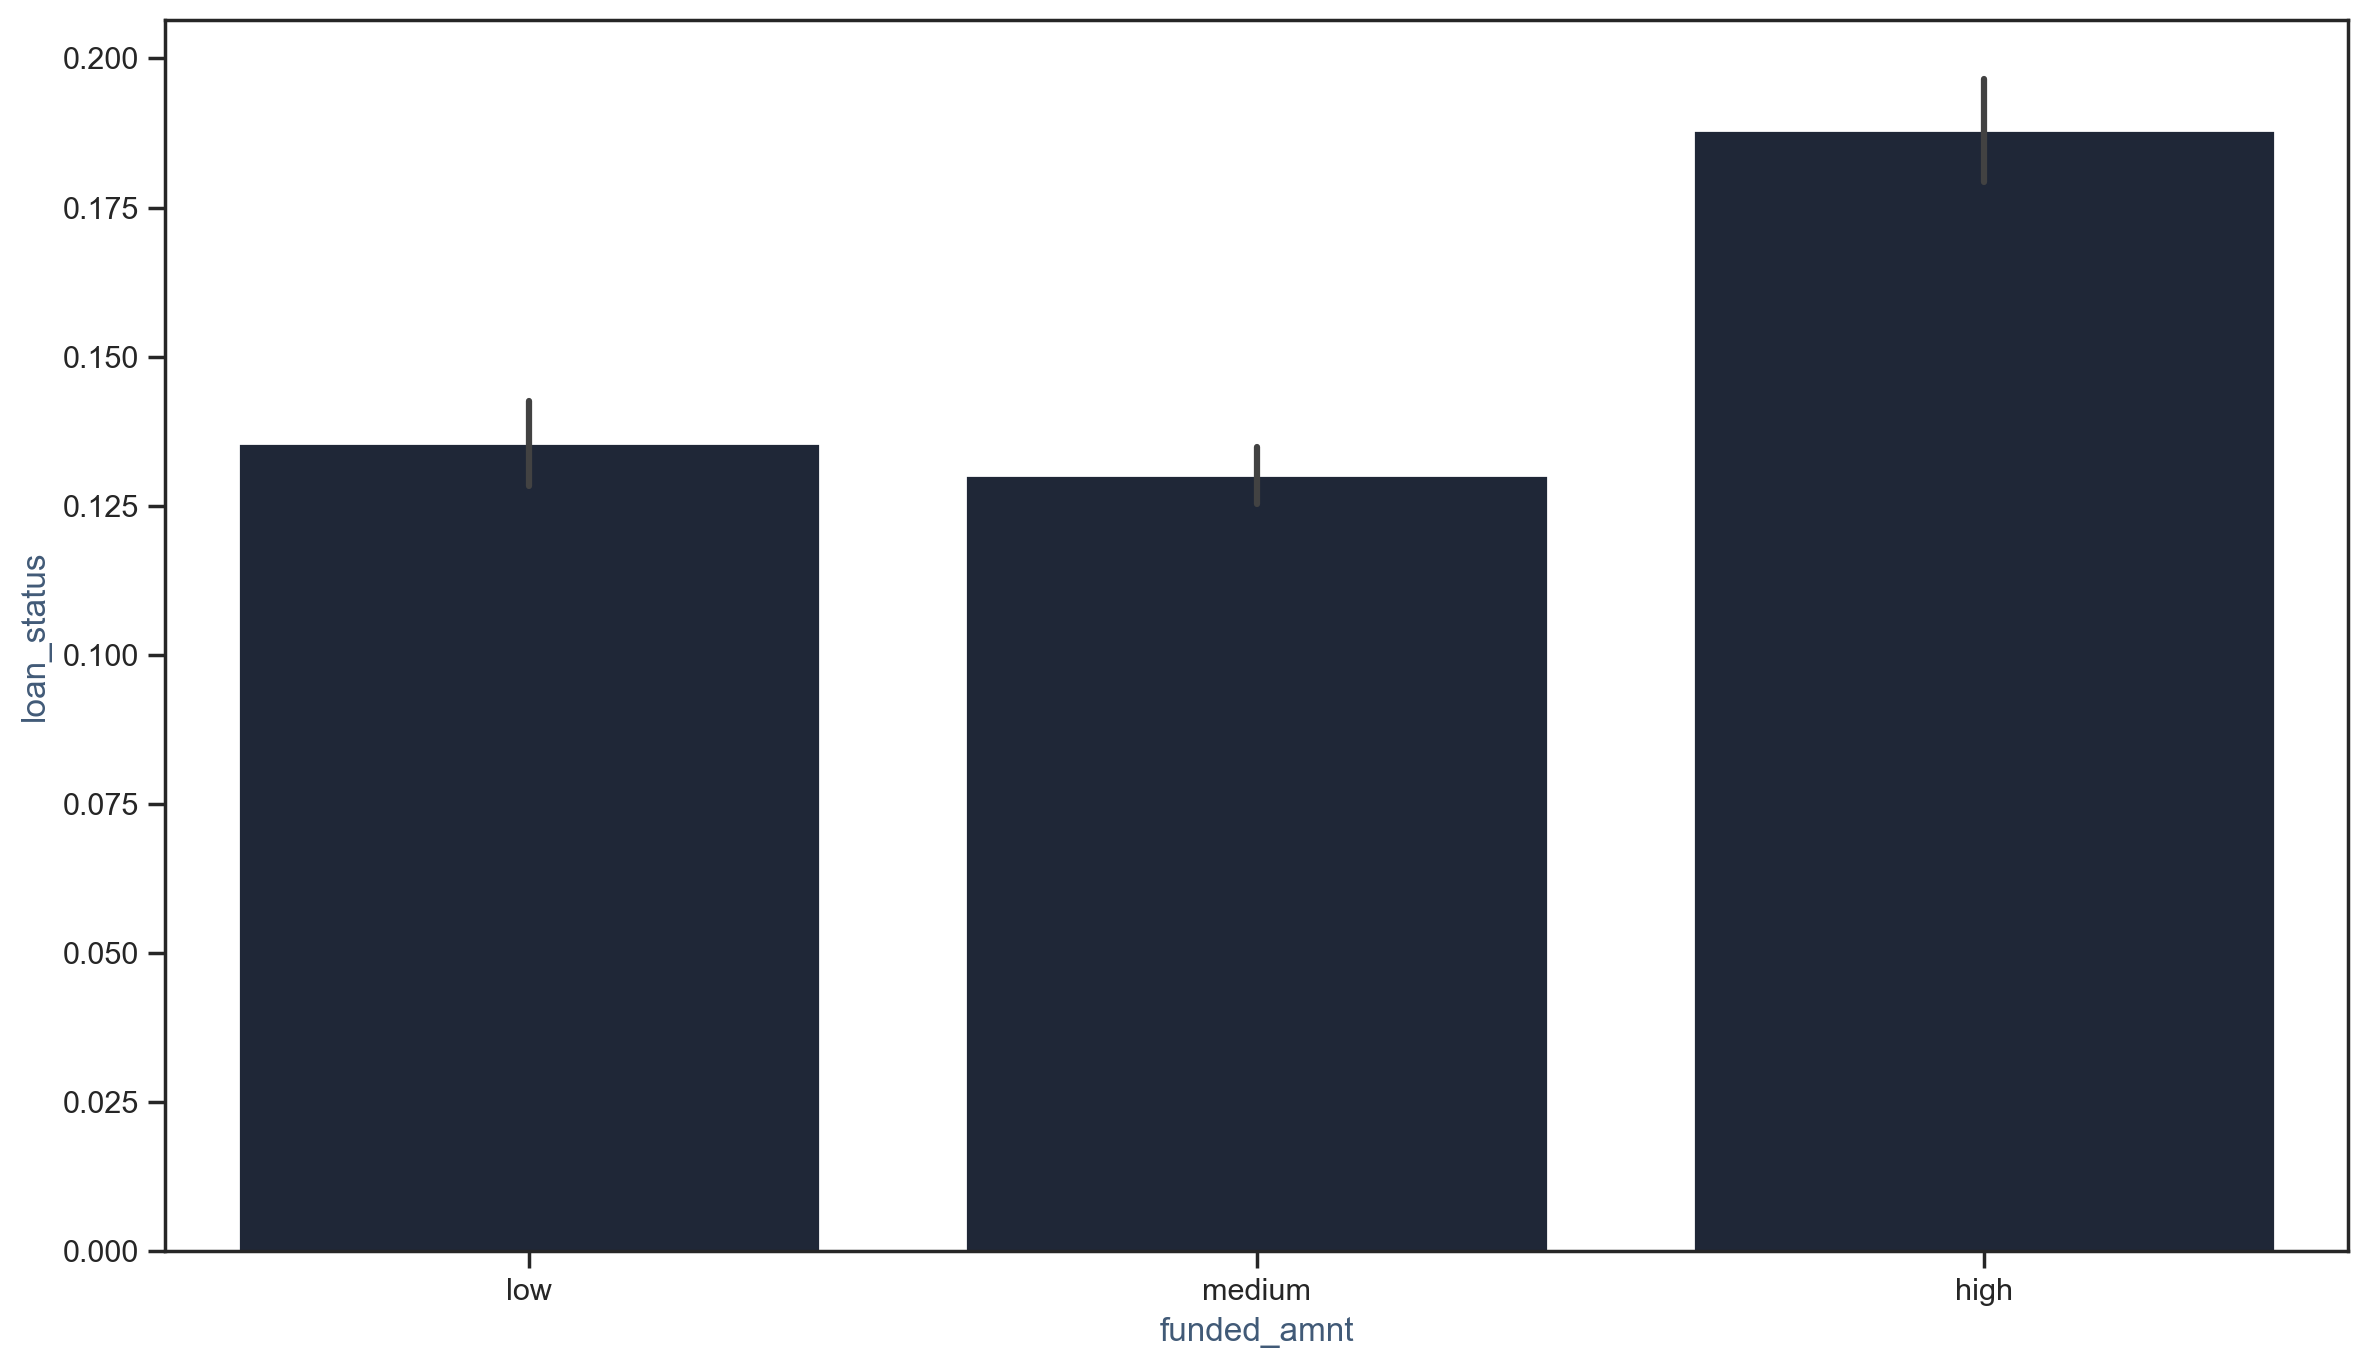

In [422]:
plot_cat('funded_amnt')

In [423]:
def installment(n):
    if n <= 200:
        return 'low'
    elif n > 200 and n <=400:
        return 'medium'
    elif n > 400 and n <=600:
        return 'high'
    else:
        return 'very high'
    
df['installment'] = df['installment'].apply(lambda x: installment(x))

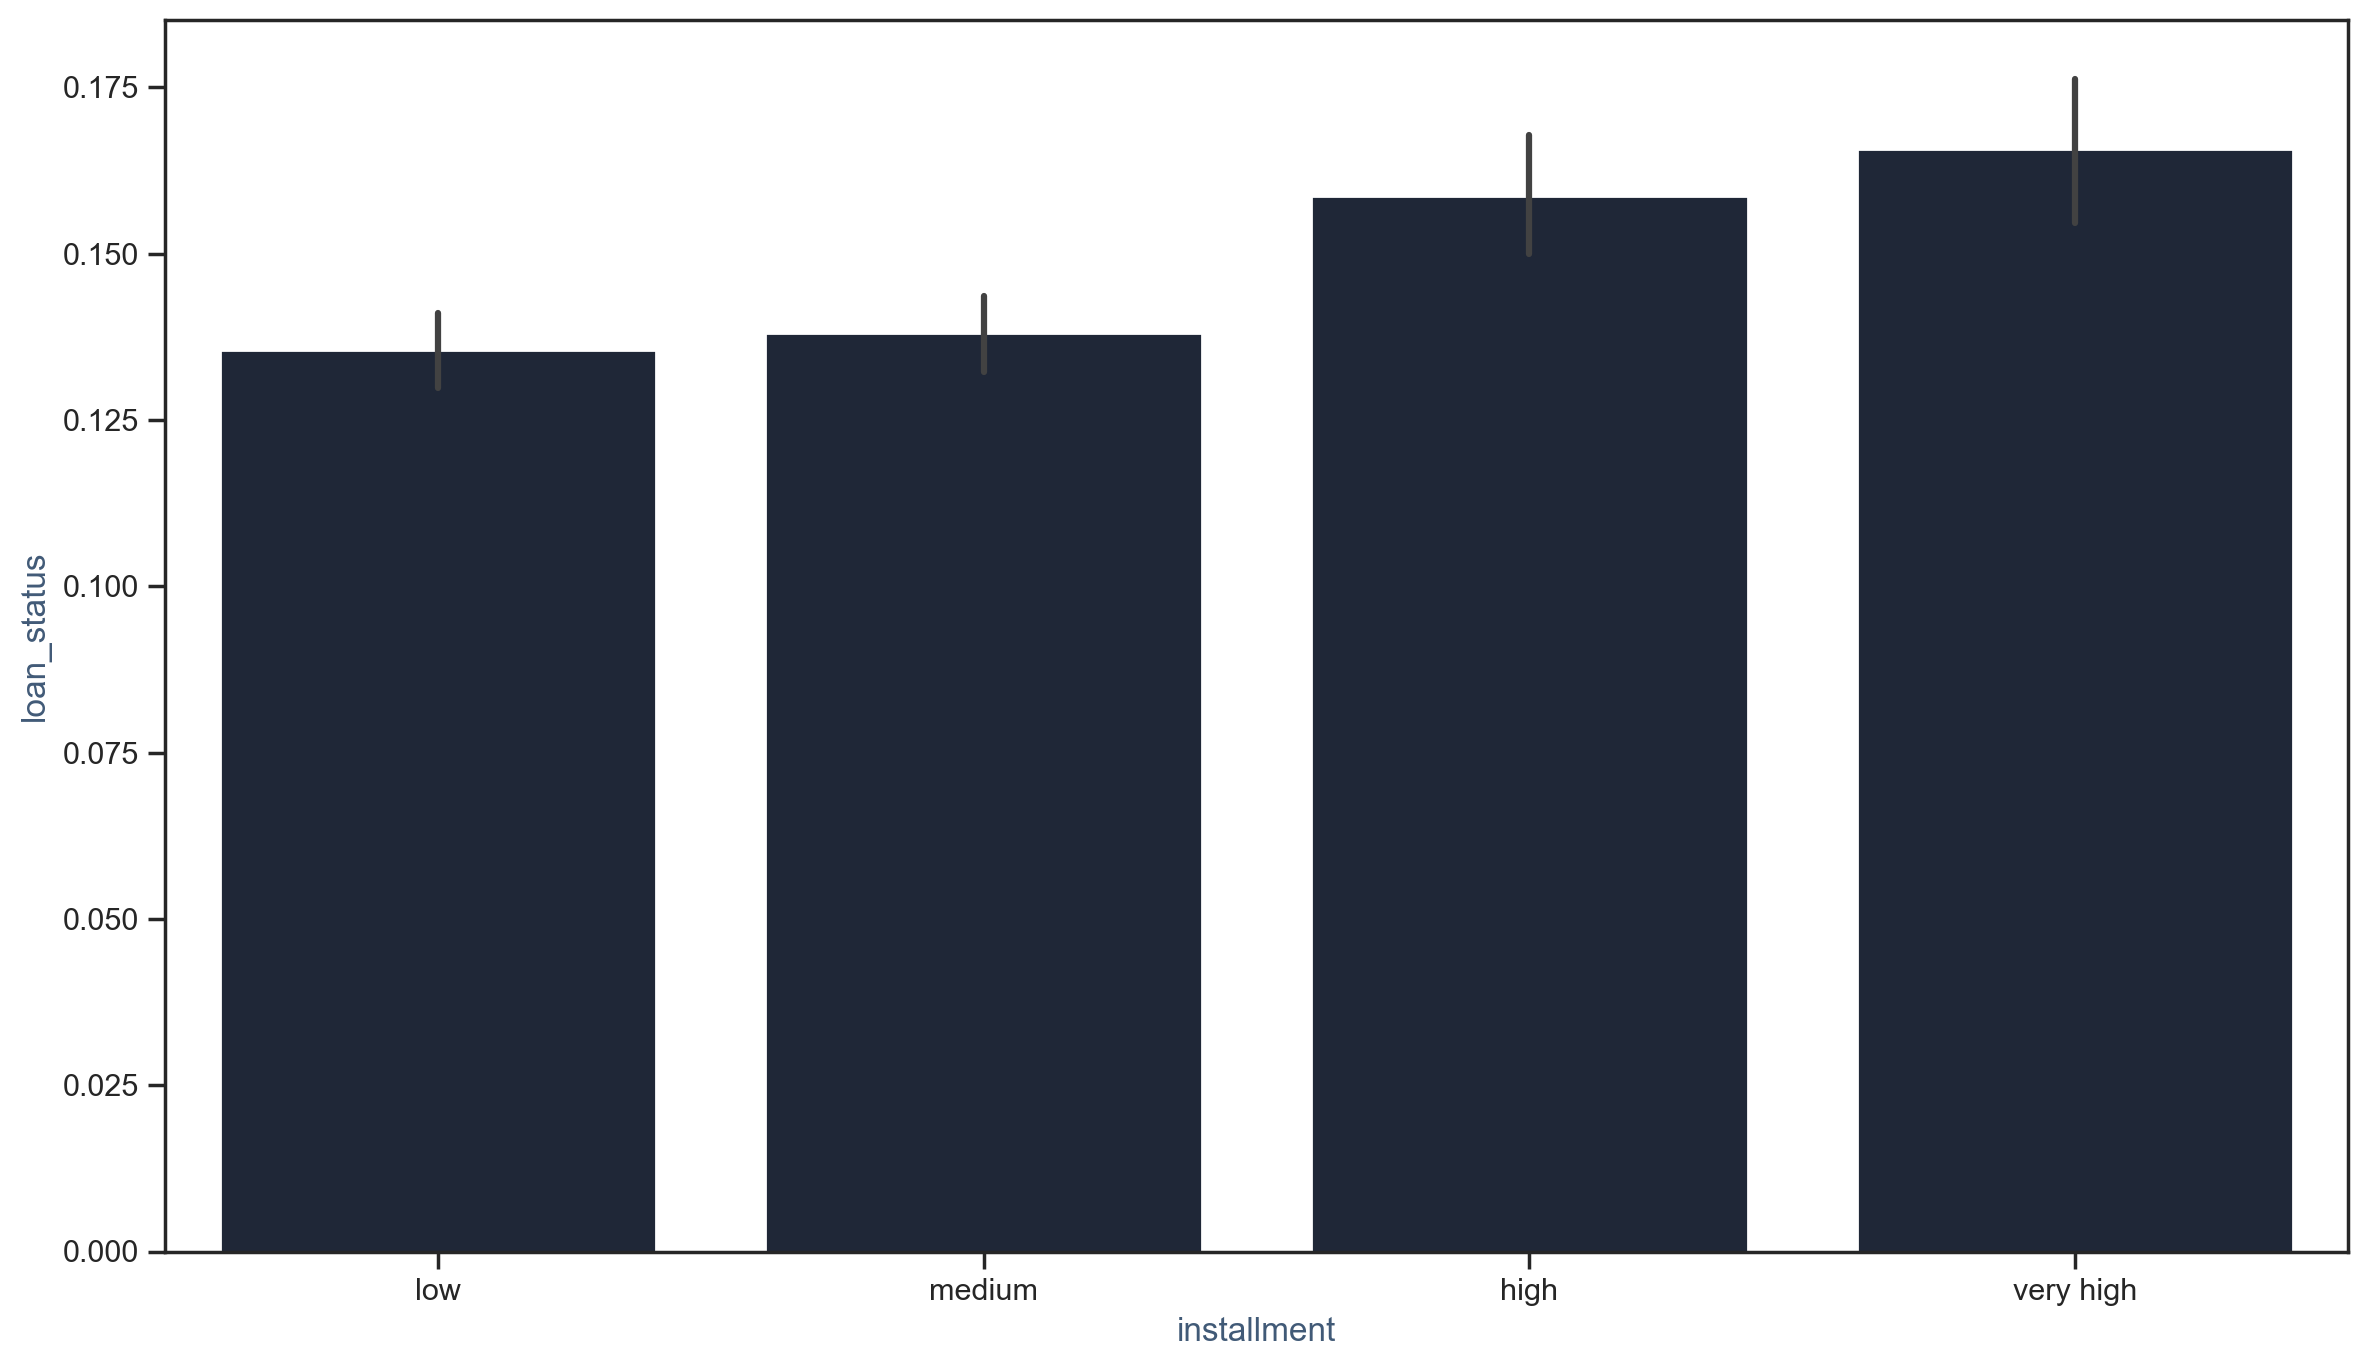

In [424]:
# comparing default rates across installment
# the higher the installment amount, the higher the default rate
plot_cat('installment')

In [425]:
def annual_income(n):
    if n <= 50000:
        return 'low'
    elif n > 50000 and n <=100000:
        return 'medium'
    elif n > 100000 and n <=150000:
        return 'high'
    else:
        return 'very high'

df['annual_inc'] = df['annual_inc'].apply(lambda x: annual_income(x))

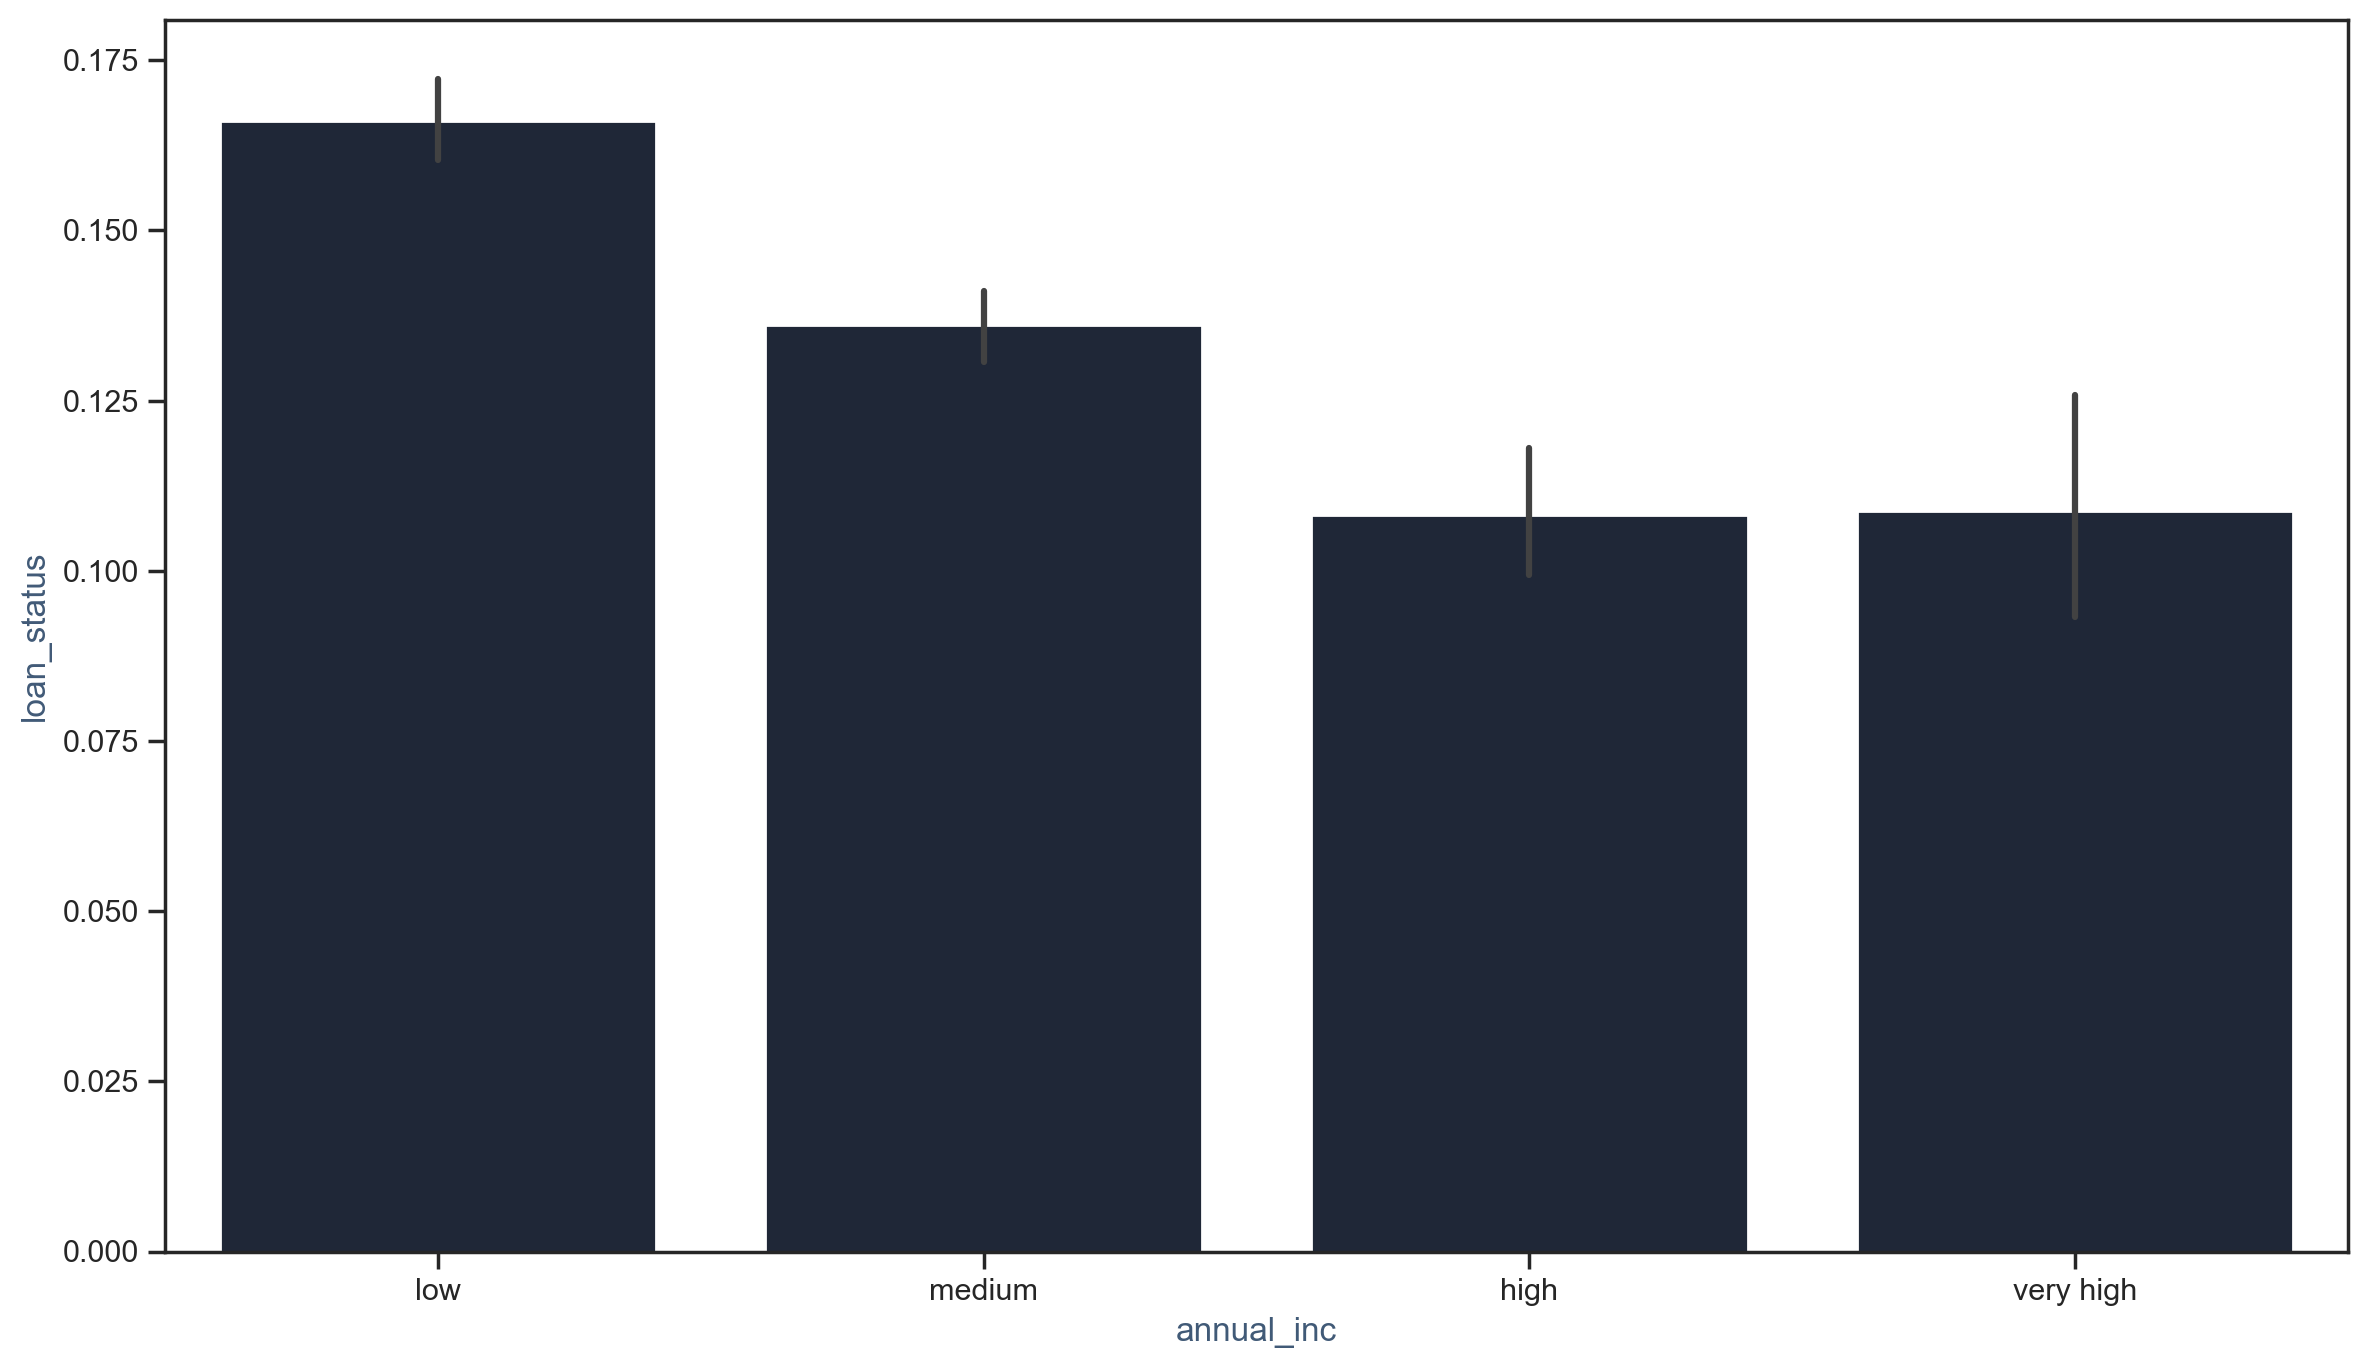

In [426]:
# annual income and default rate
# lower the annual income, higher the default rate
plot_cat('annual_inc')

In [427]:
# employment length
# first, let's drop the missing value observations in emp length
df = df[~df['emp_length'].isnull()]

# binning the variable
def emp_length(n):
    if n <= 1:
        return 'fresher'
    elif n > 1 and n <=3:
        return 'junior'
    elif n > 3 and n <=7:
        return 'senior'
    else:
        return 'expert'

df['emp_length'] = df['emp_length'].apply(lambda x: emp_length(x))

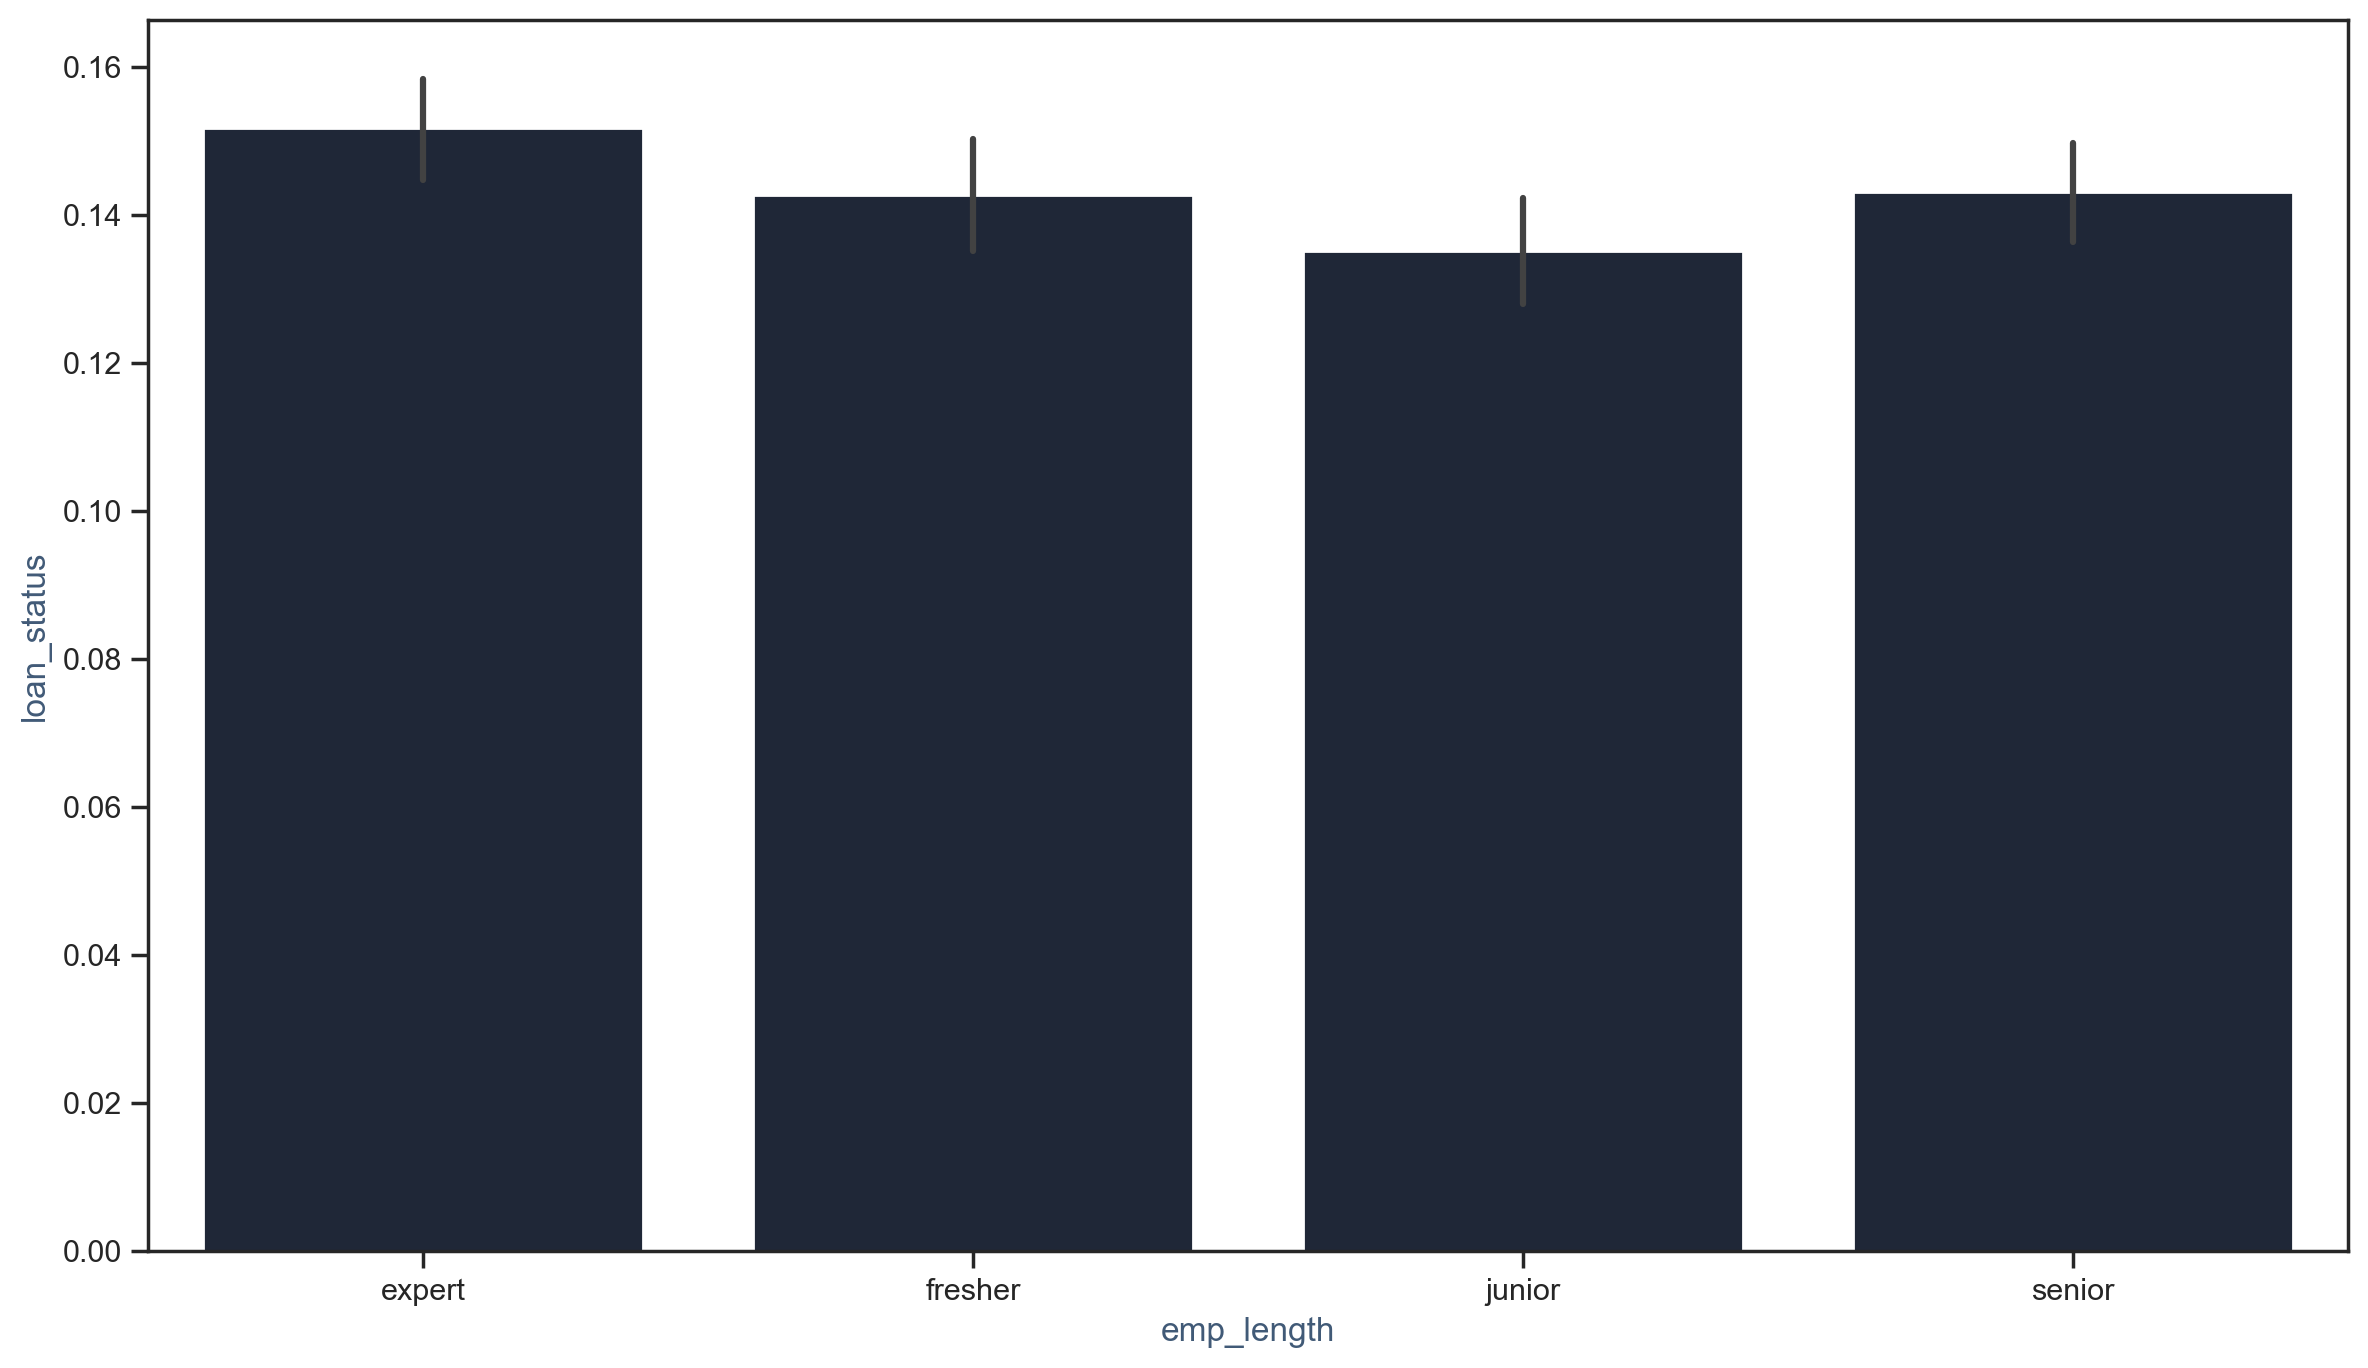

In [428]:
# emp_length and default rate
# not much of a predictor of default
plot_cat('emp_length')

## Segmented Univariate Analysis

We have now compared the default rates across various variables, and some of the important predictors are purpose of the loan, interest rate, annual income, grade etc.

In the credit industry, one of the most important factors affecting default is the purpose of the loan - home loans perform differently than credit cards, credit cards are very different from debt condolidation loans etc. 

This comes from business understanding, though let's again have a look at the default rates across the purpose of the loan.

In [429]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- CHOOSE YOUR VIBE HERE ---
# Categorical (Best for different groups like 'Apple', 'Orange', 'Banana')
# Options: "pastel", "husl", "Set2", "Paired", "hls"

# Sequential (Best for rankings or growth like 'Low', 'Medium', 'High')
# Options: "viridis", "mako", "rocket", "crest", "flare"

# Diverging (Best for Profit vs Loss or Positive vs Negative)
# Options: "vlag", "coolwarm", "RdBu"

MY_PALETTE = "husl" # <--- Change this name to try the different styles below!

# Apply globally
sns.set_theme(style="whitegrid", palette=MY_PALETTE, context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

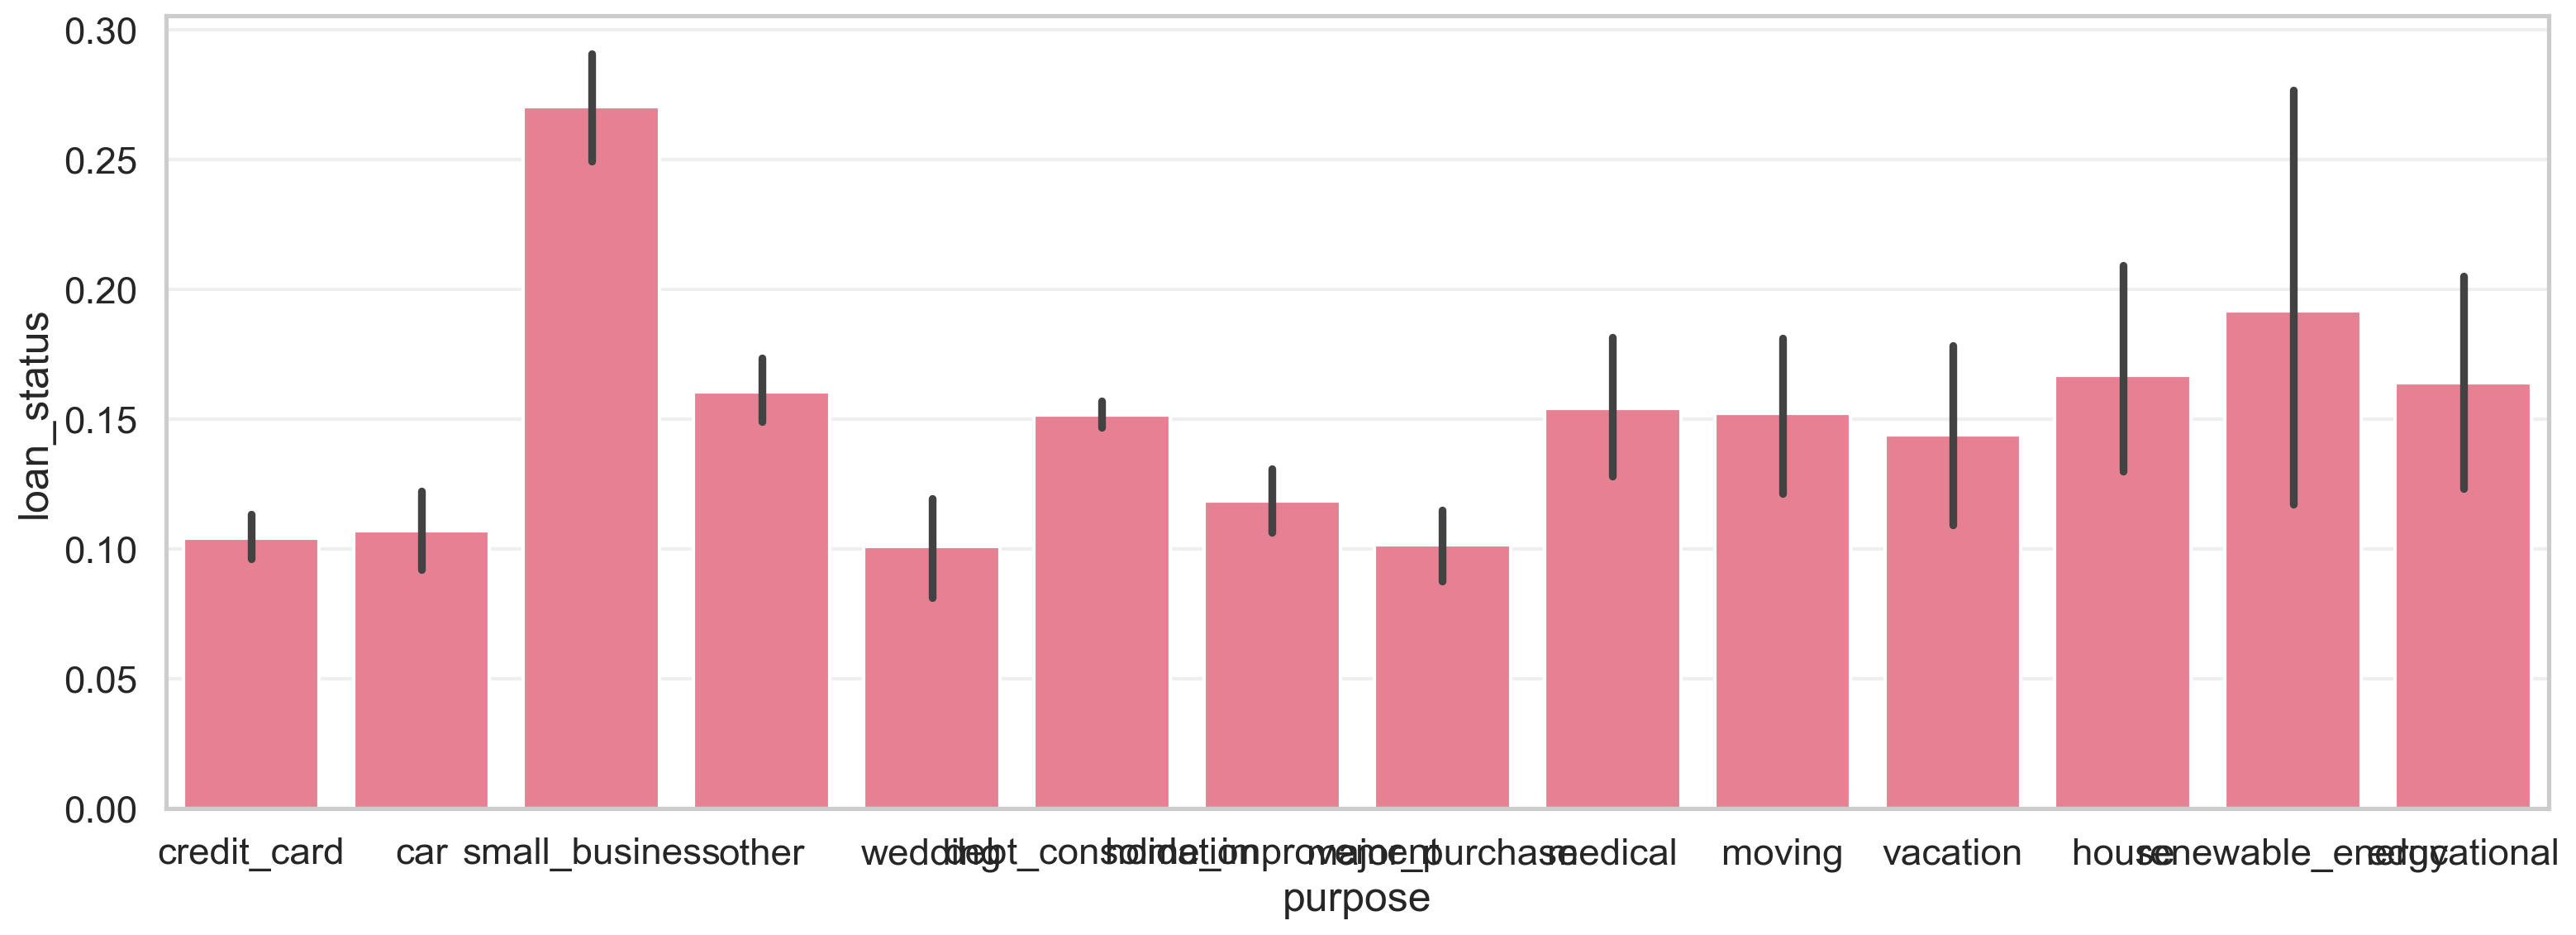

In [430]:
# purpose: small business loans defualt the most, then renewable energy and education
plt.figure(figsize=(16, 6))
plot_cat('purpose')

In the upcoming analyses, we will segment the loan applications across the purpose of the loan, since that is a variable affecting many other variables - the type of applicant, interest rate, income, and finally the default rate.



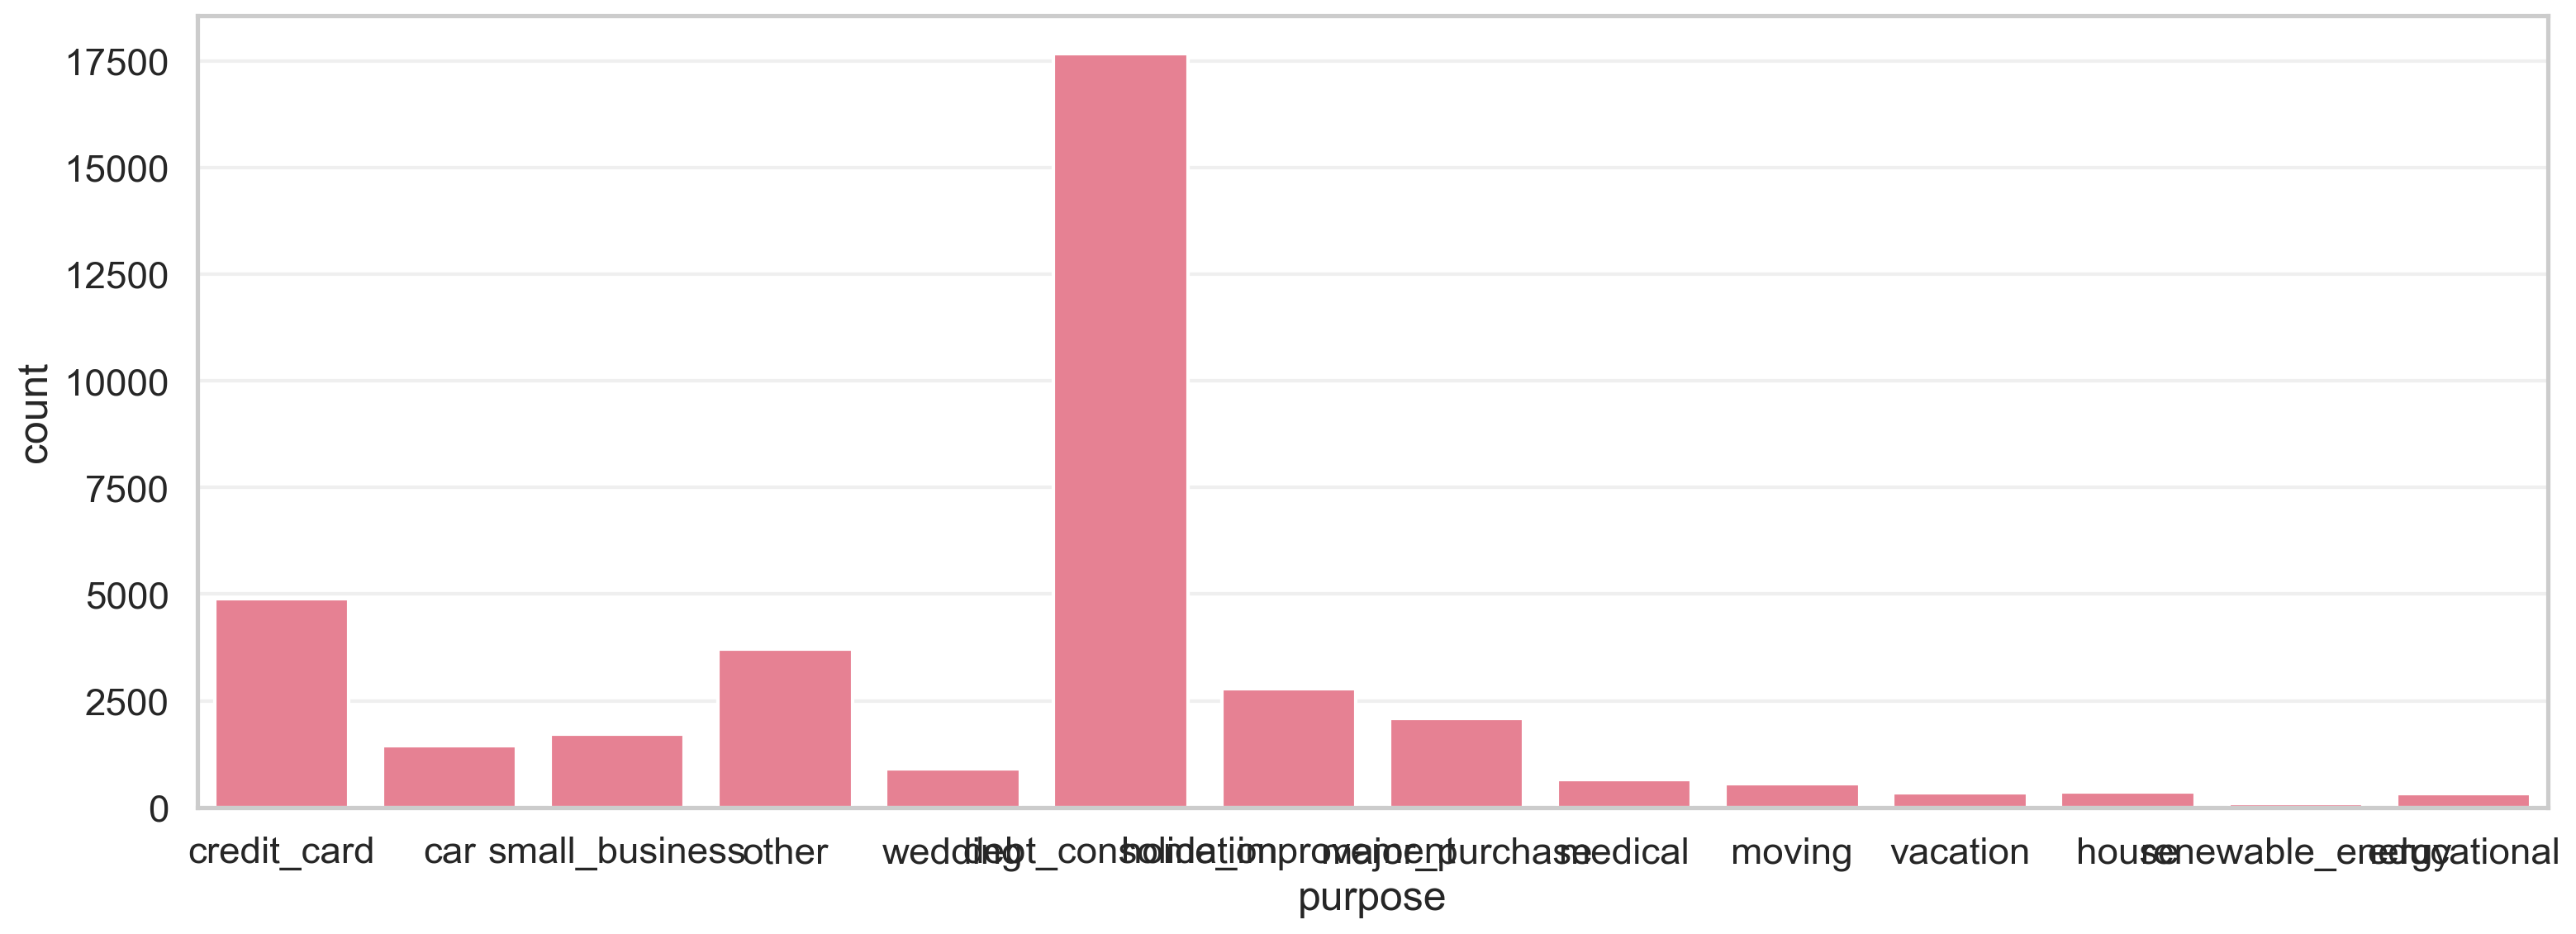

In [431]:
# lets first look at the number of loans for each type (purpose) of the loan
# most loans are debt consolidation (to repay otehr debts), then credit card, major purchase etc.
plt.figure(figsize=(16, 6))
sns.countplot(x='purpose', data=df)
plt.show()

In [432]:
# filtering the df for the 4 types of loans mentioned above
main_purposes = ["credit_card","debt_consolidation","home_improvement","major_purchase"]
df = df[df['purpose'].isin(main_purposes)]
df['purpose'].value_counts()

purpose
debt_consolidation    17675
credit_card            4899
home_improvement       2785
major_purchase         2080
Name: count, dtype: int64

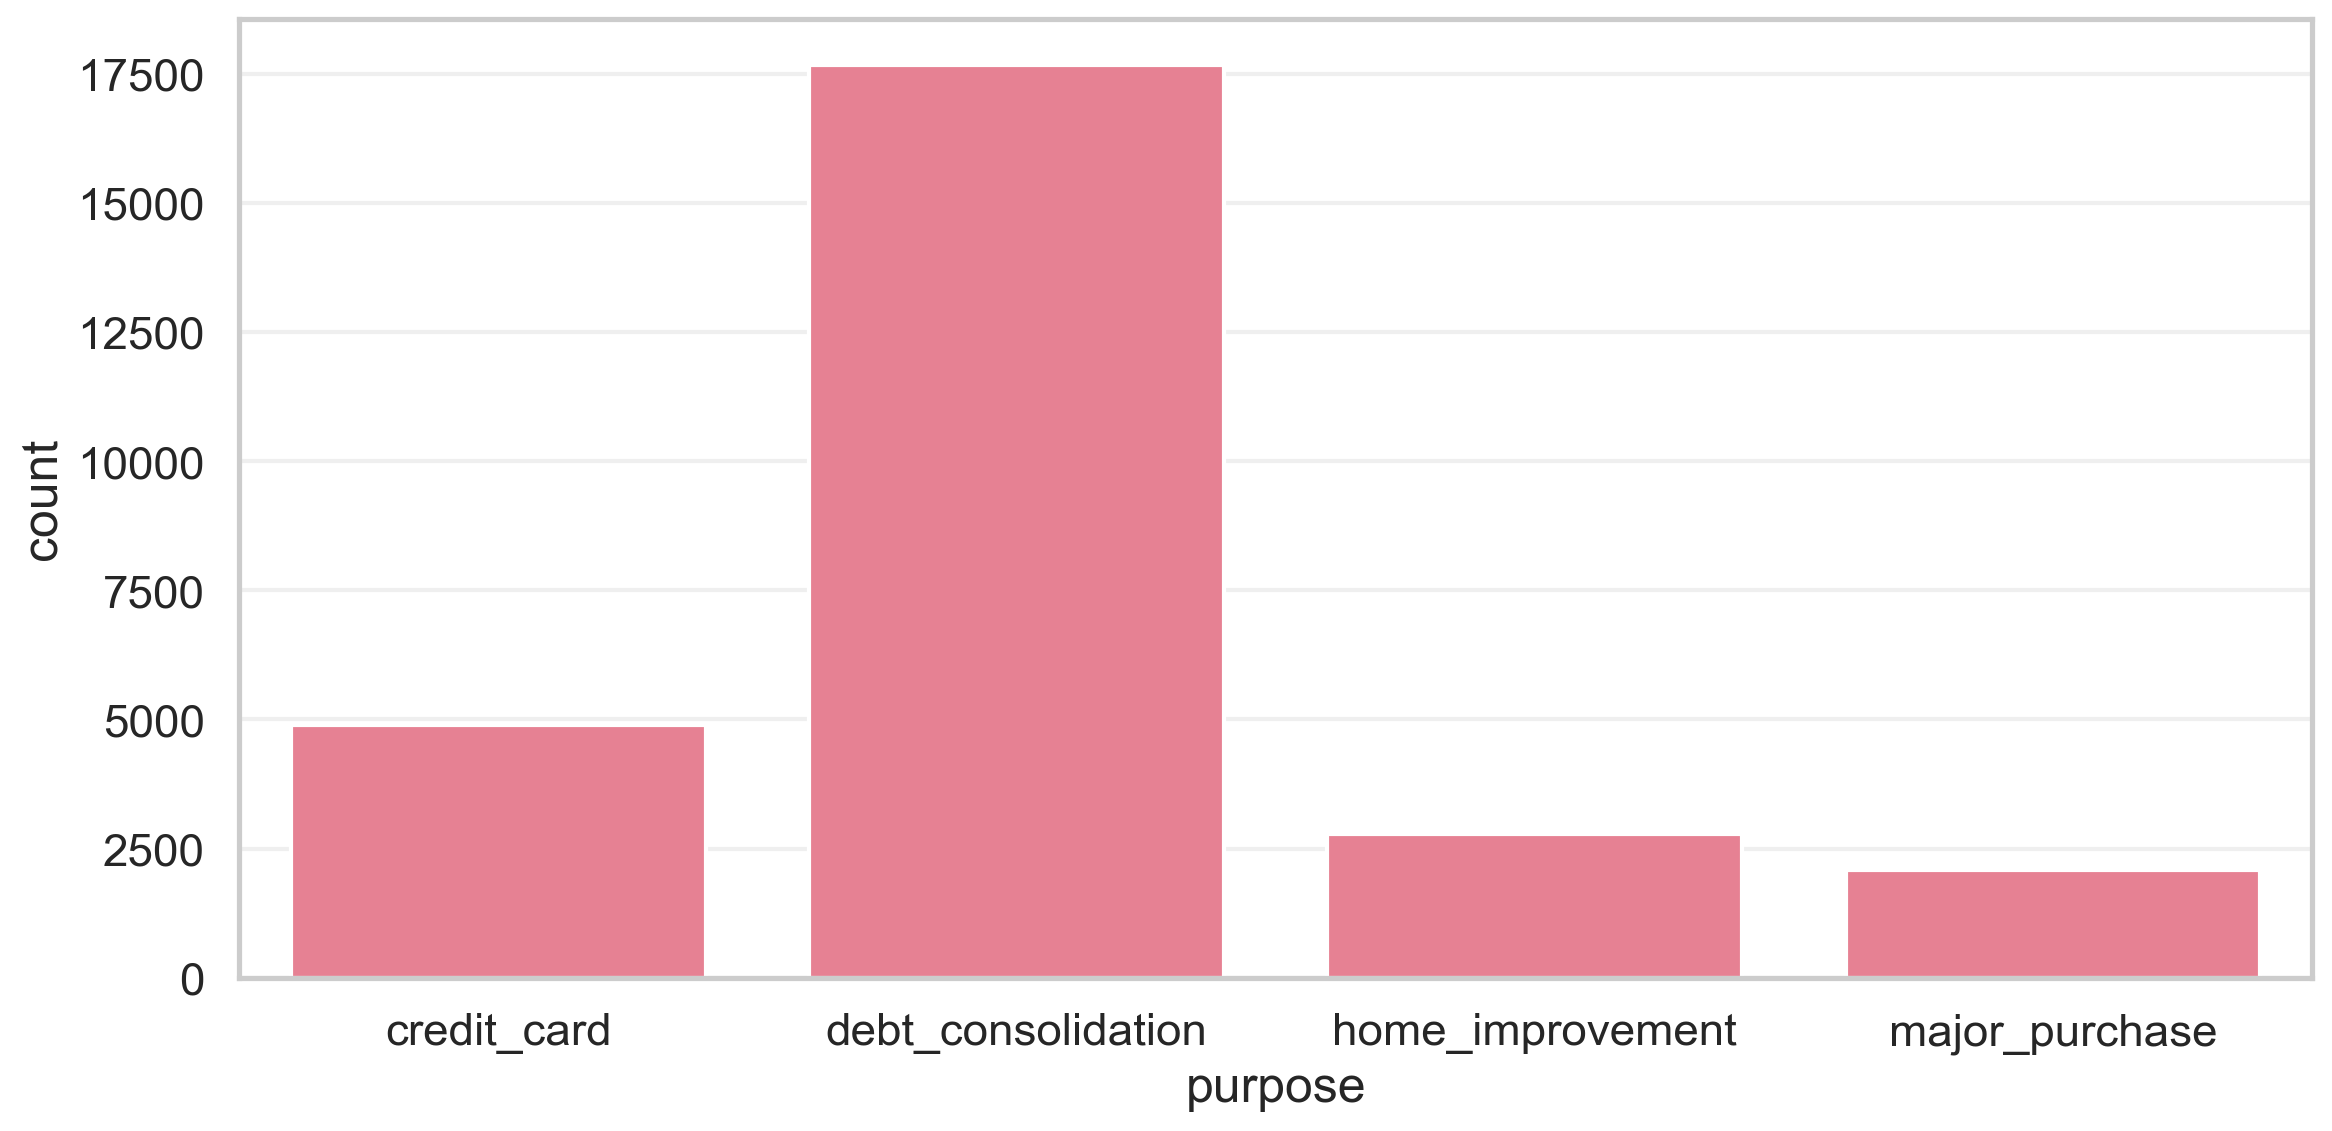

In [433]:
# plotting number of loans by purpose 
sns.countplot(x=df['purpose'])
plt.show()

In [443]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. The "Maximum Variety" Palette
# We create a palette with 25+ unique colors so every bar gets its own look
rainbow_palette = sns.color_palette("husl", 25) 

# 2. Apply it globally
sns.set_theme(style="whitegrid", palette=rainbow_palette, context="talk")

# 3. Global settings to make the bars/lines pop
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'patch.edgecolor': 'black',     # Adds a clean black border around every bar
    'patch.linewidth': 1.5,         # Makes the border thick and professional
    'axes.prop_cycle': plt.cycler(color=rainbow_palette), # Forces lines to change color too
    'axes.titlesize': 20,
    'axes.titleweight': 'bold'
})

print("🌈 Rainbow Mode Activated: Every bar will now have a unique color!")

🌈 Rainbow Mode Activated: Every bar will now have a unique color!


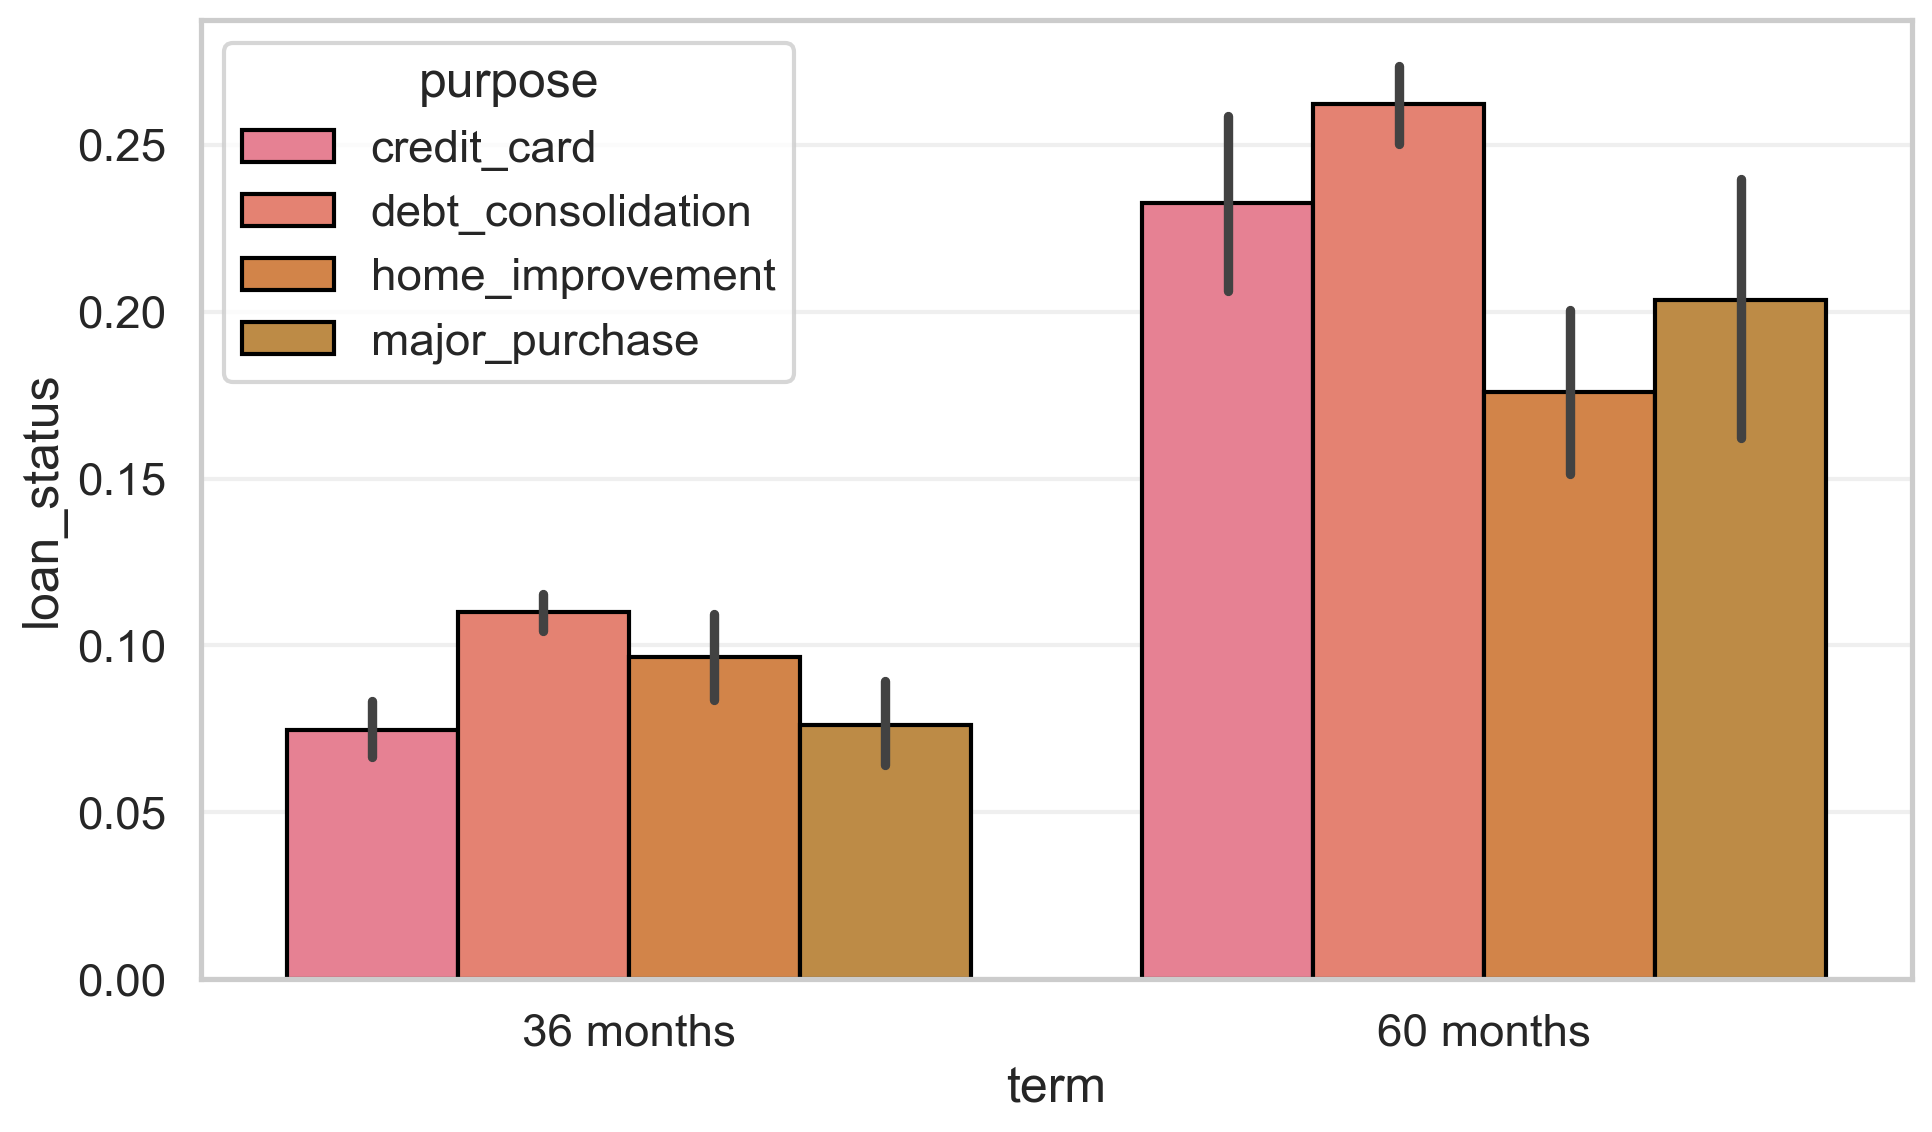

In [444]:
# let's now compare the default rates across two types of categorical variables
# purpose of loan (constant) and another categorical variable (which changes)

plt.figure(figsize=[10, 6])
sns.barplot(x='term', y="loan_status", hue='purpose', data=df)
plt.show()


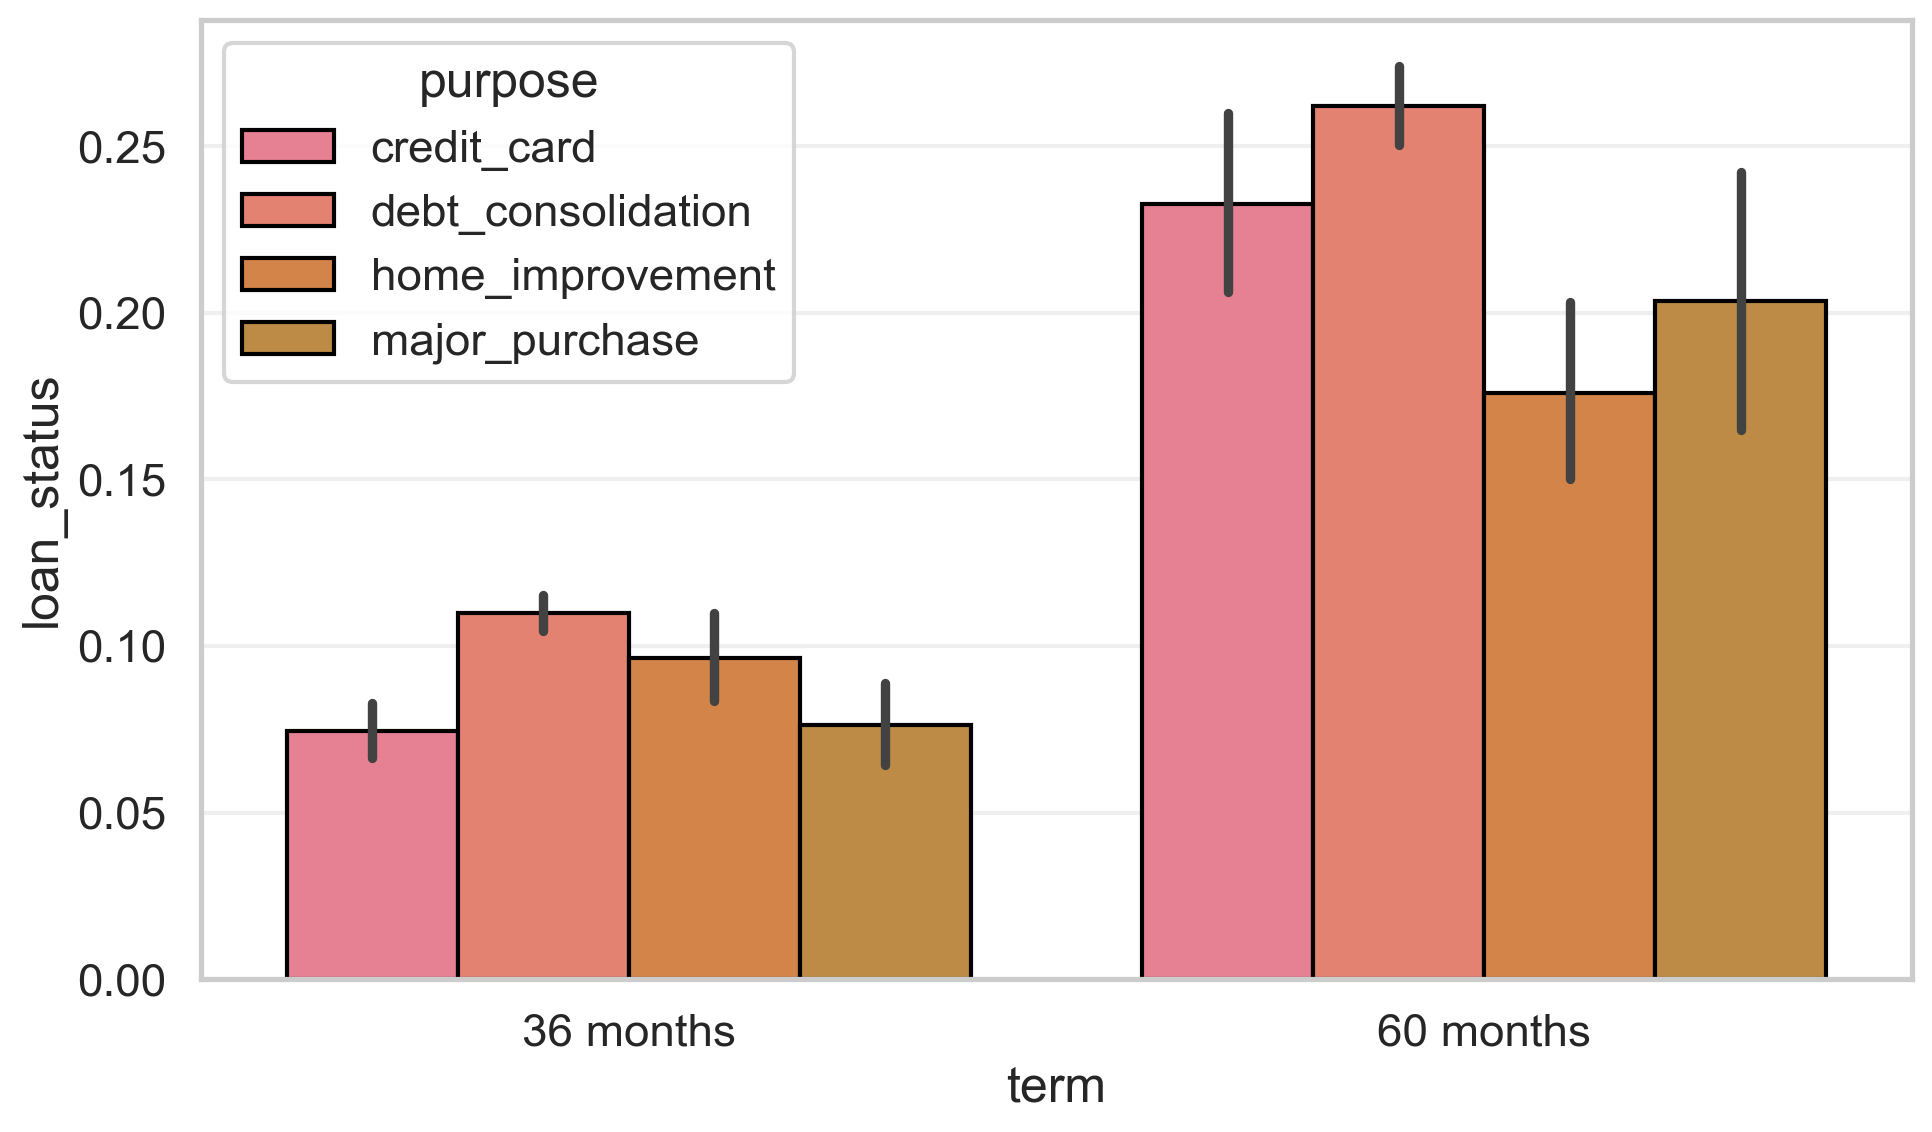

In [445]:
# lets write a function which takes a categorical variable and plots the default rate
# segmented by purpose 

def plot_segmented(cat_var):
    plt.figure(figsize=(10, 6))
    sns.barplot(x=cat_var, y='loan_status', hue='purpose', data=df)    
    plt.show()

    
plot_segmented('term')

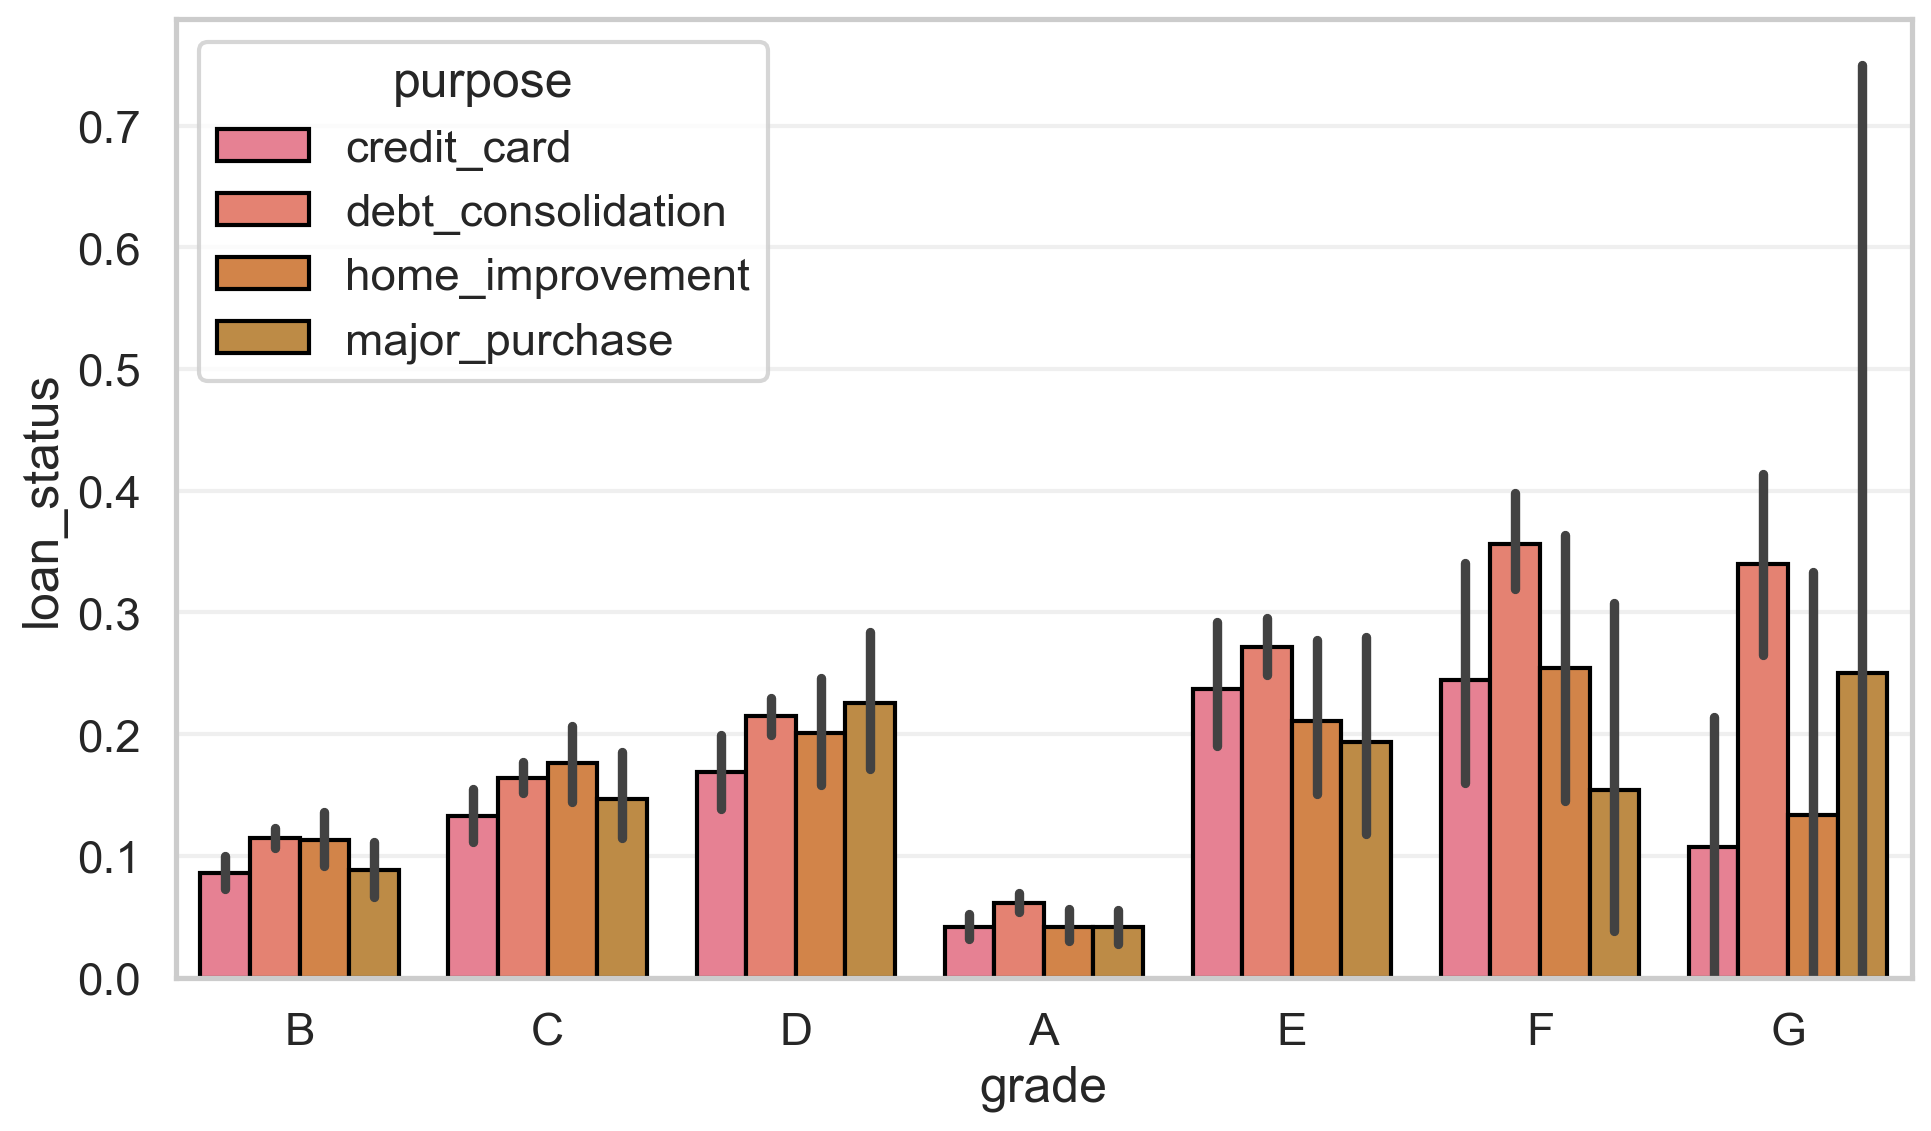

In [446]:
# grade of loan
plot_segmented('grade')

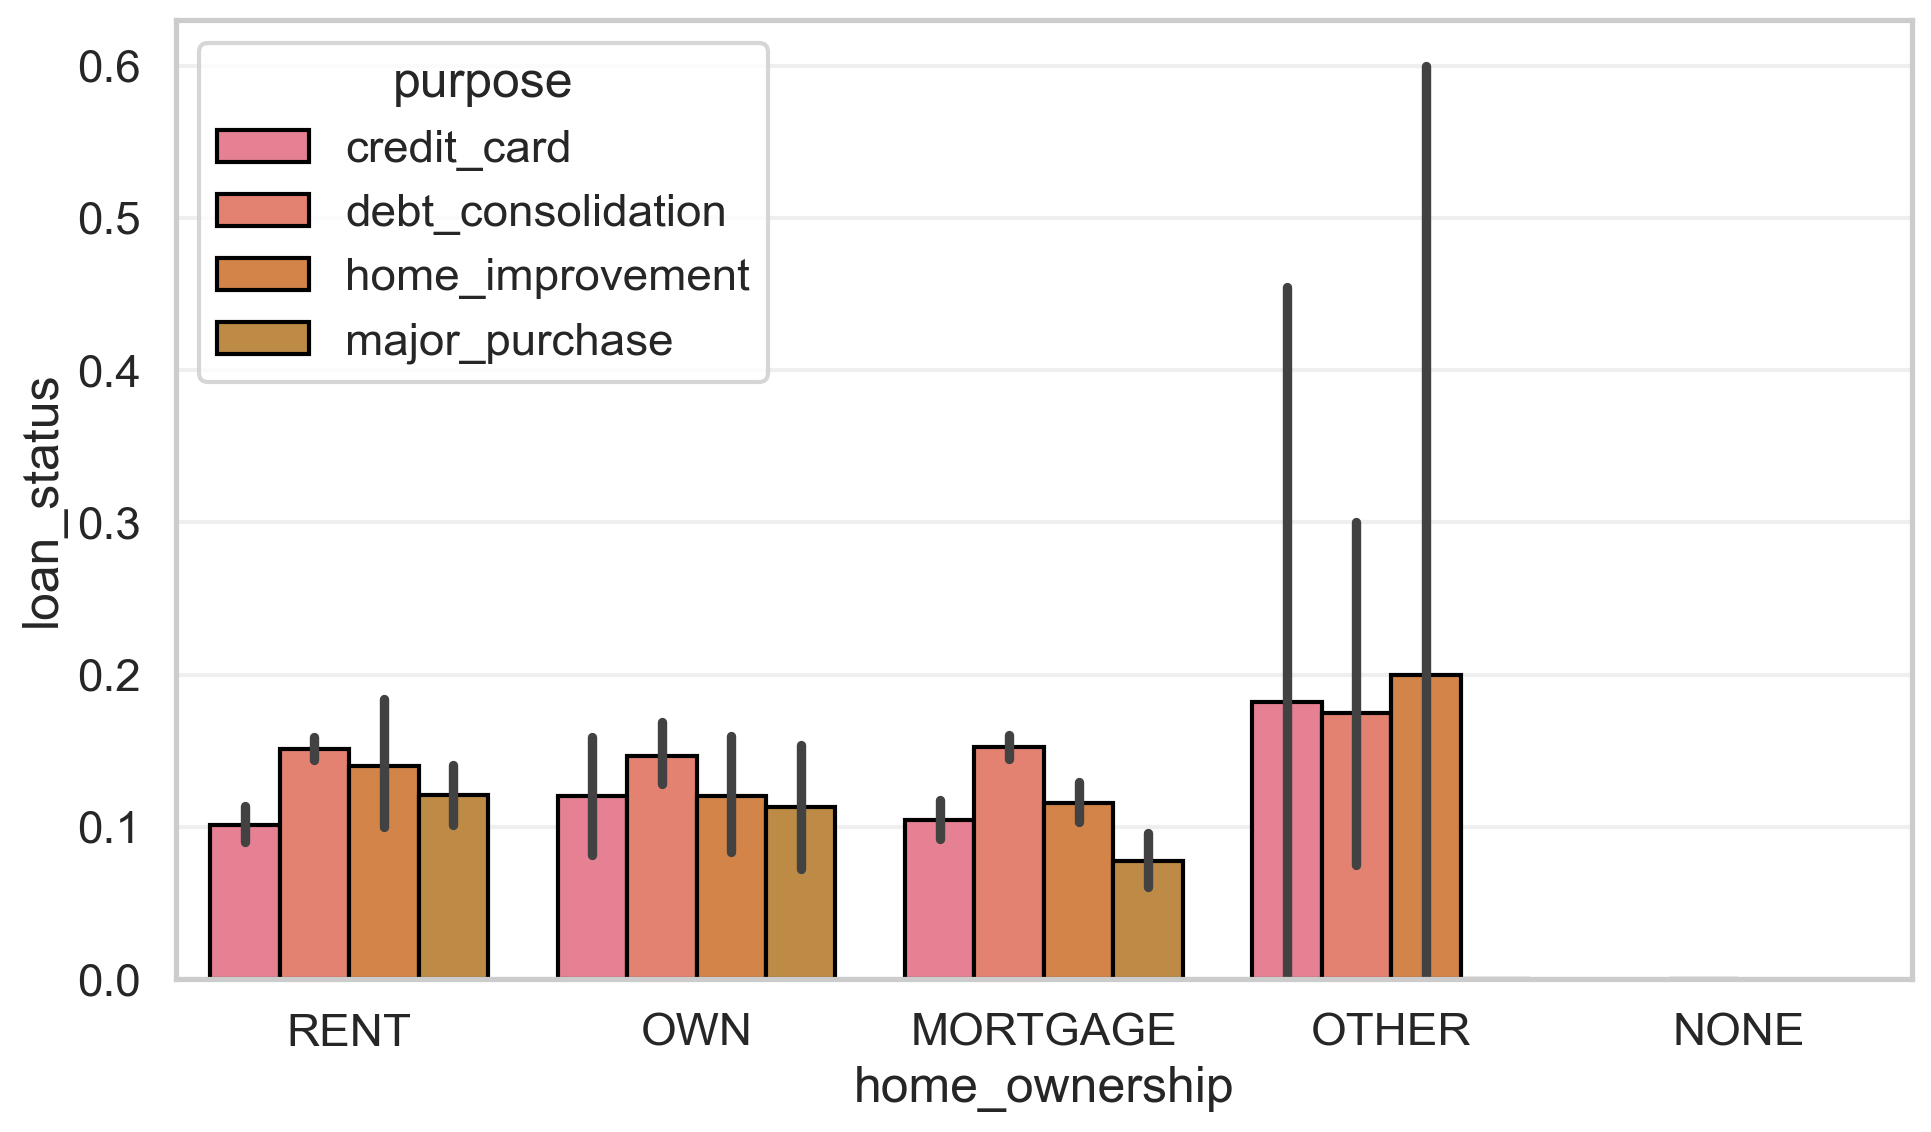

In [447]:
# home ownership
plot_segmented('home_ownership')

# home ownership
plot_segmented('home_ownership')

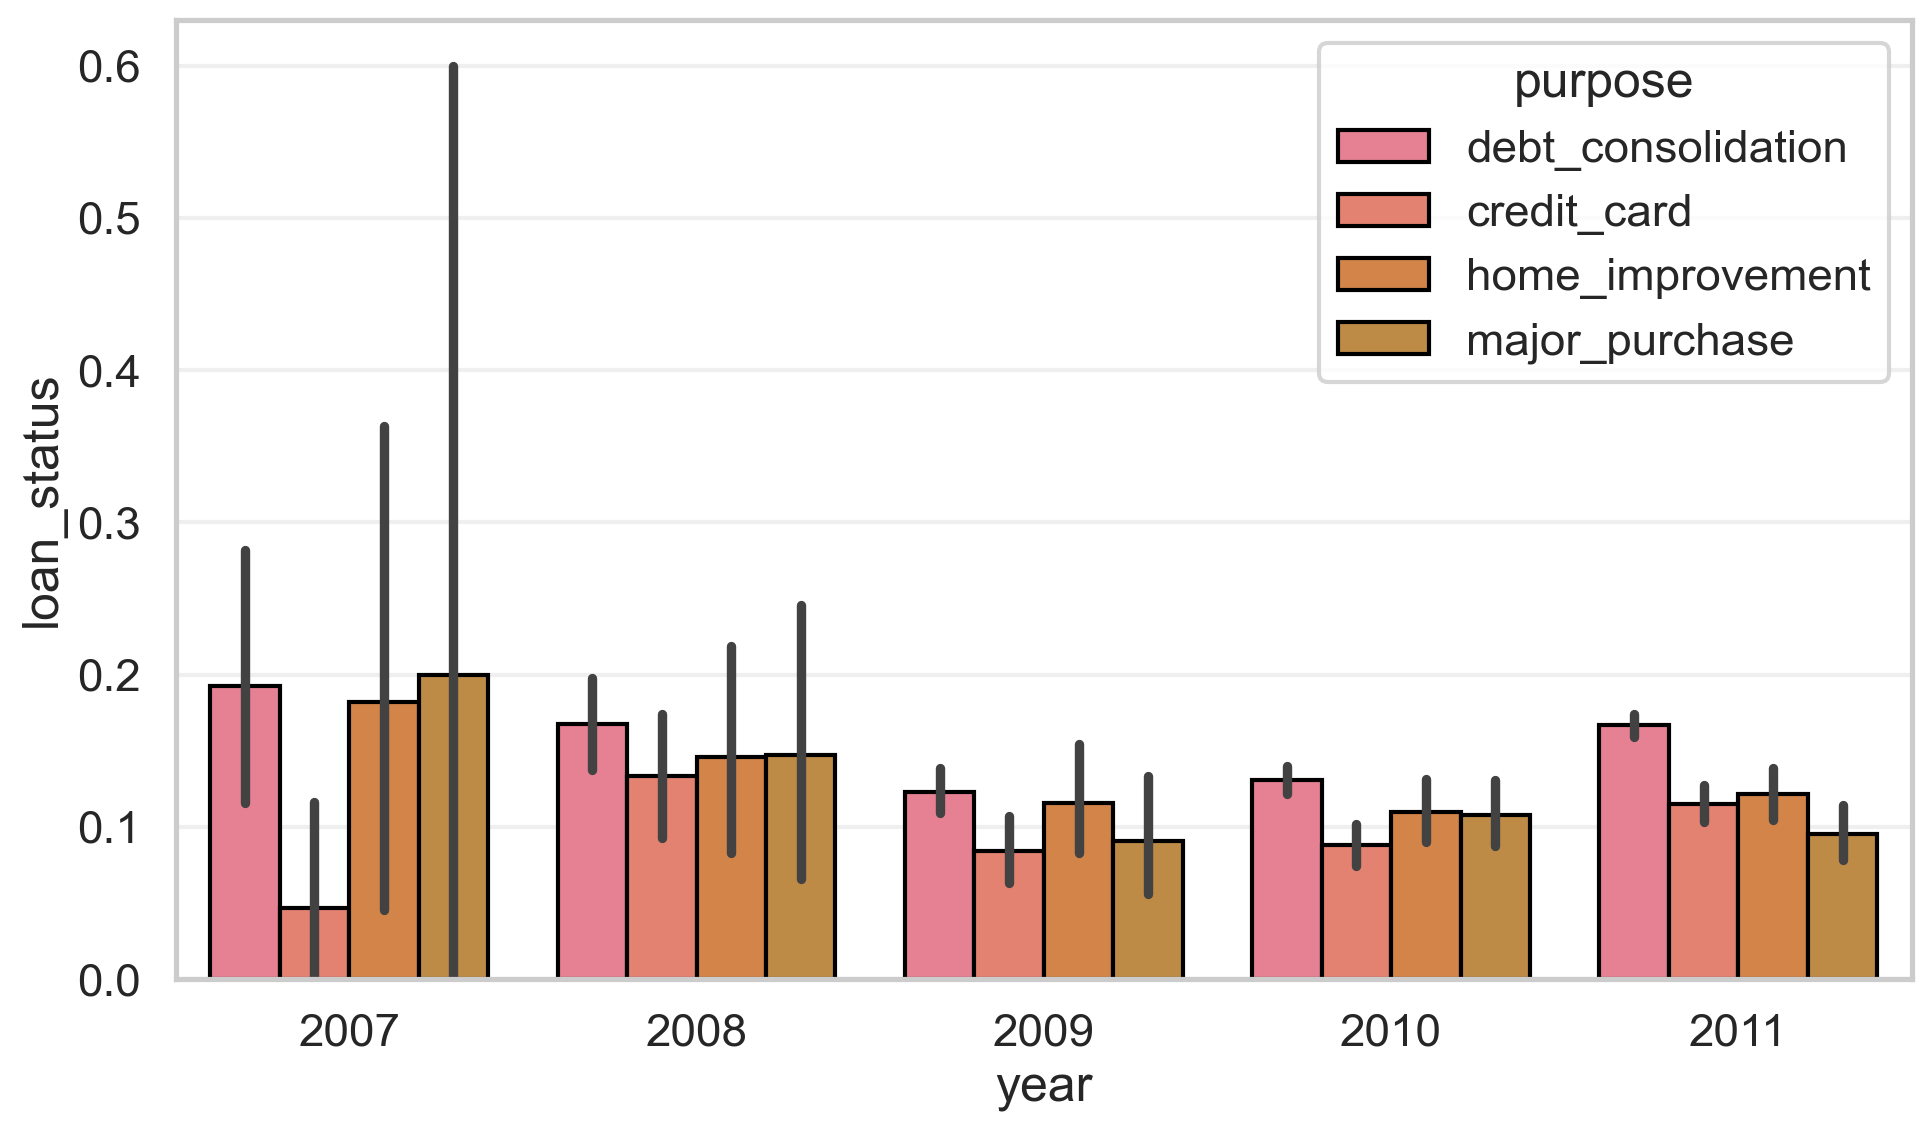

In [448]:
#year
plot_segmented('year')

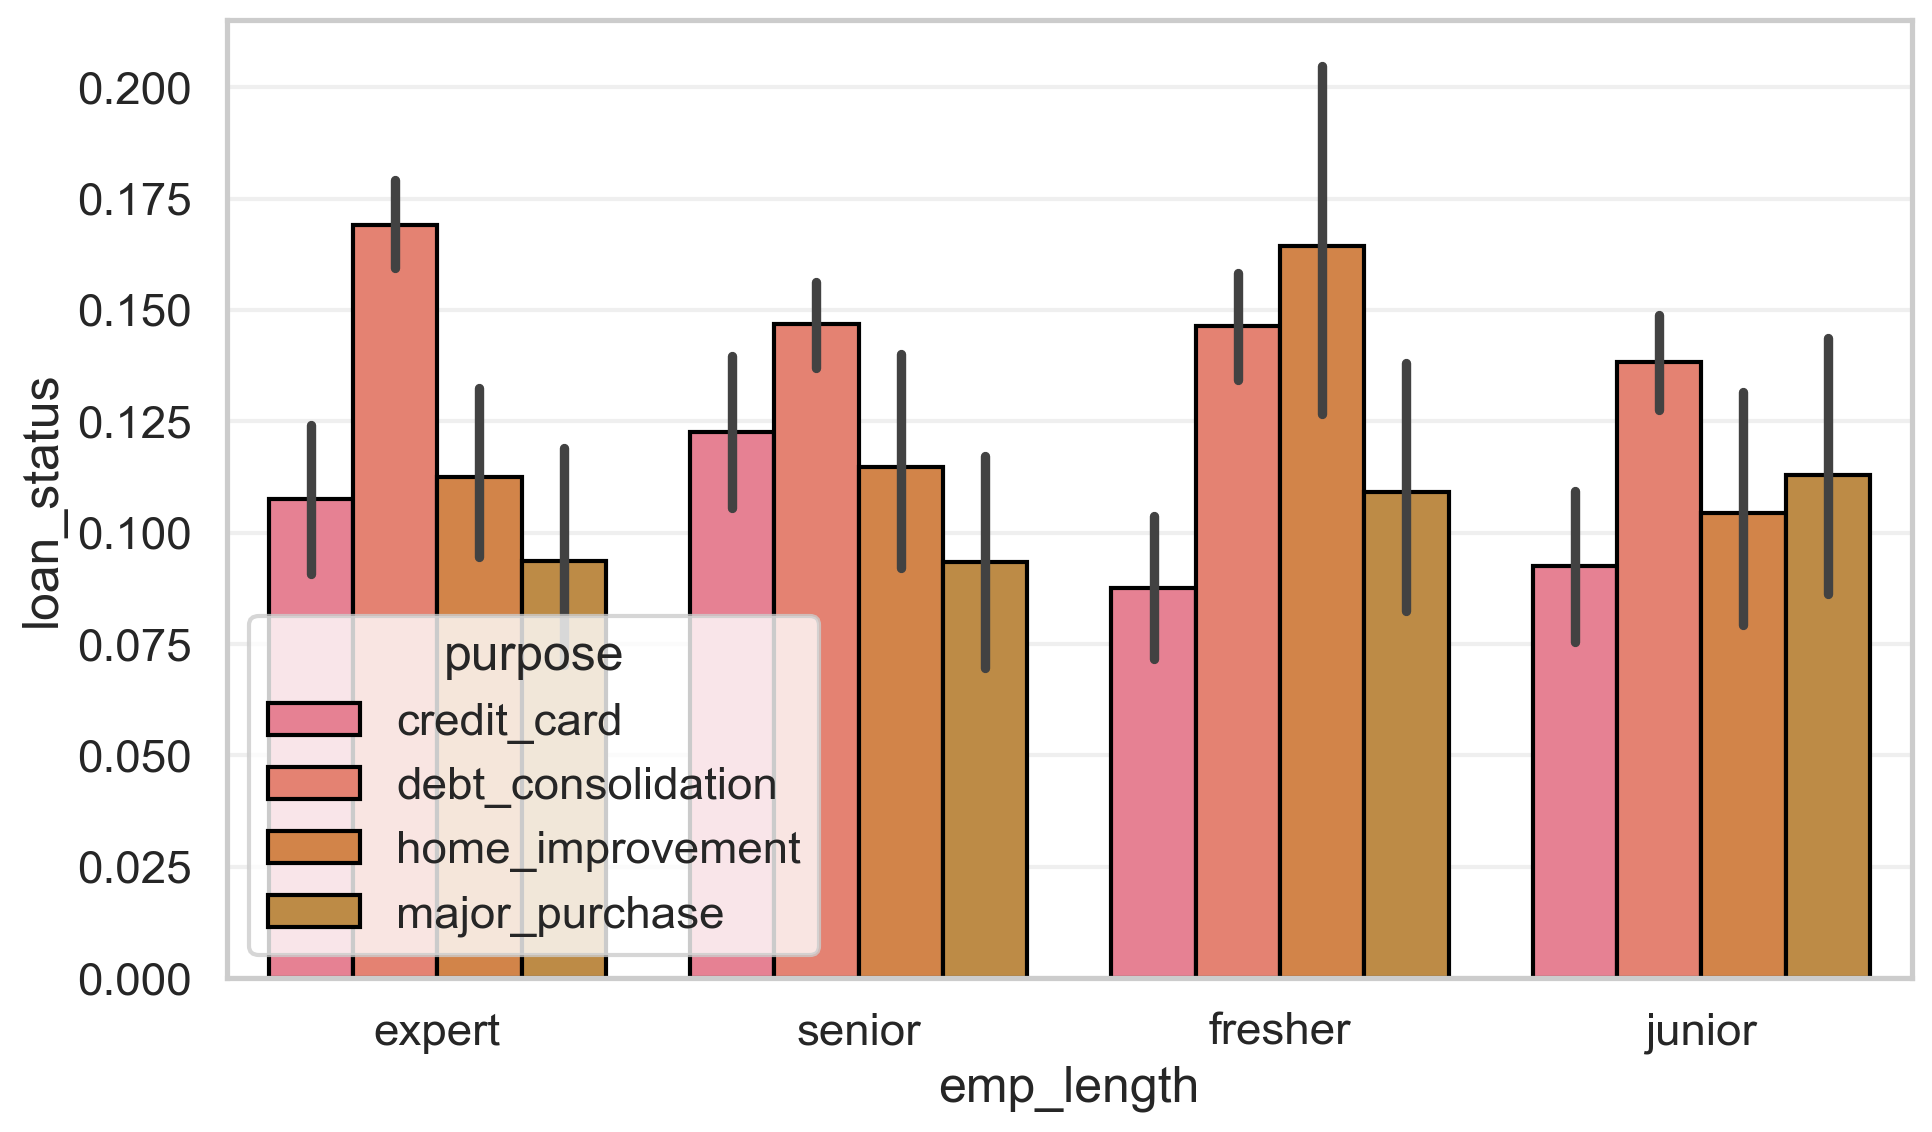

In [449]:
# emp_length
plot_segmented('emp_length')

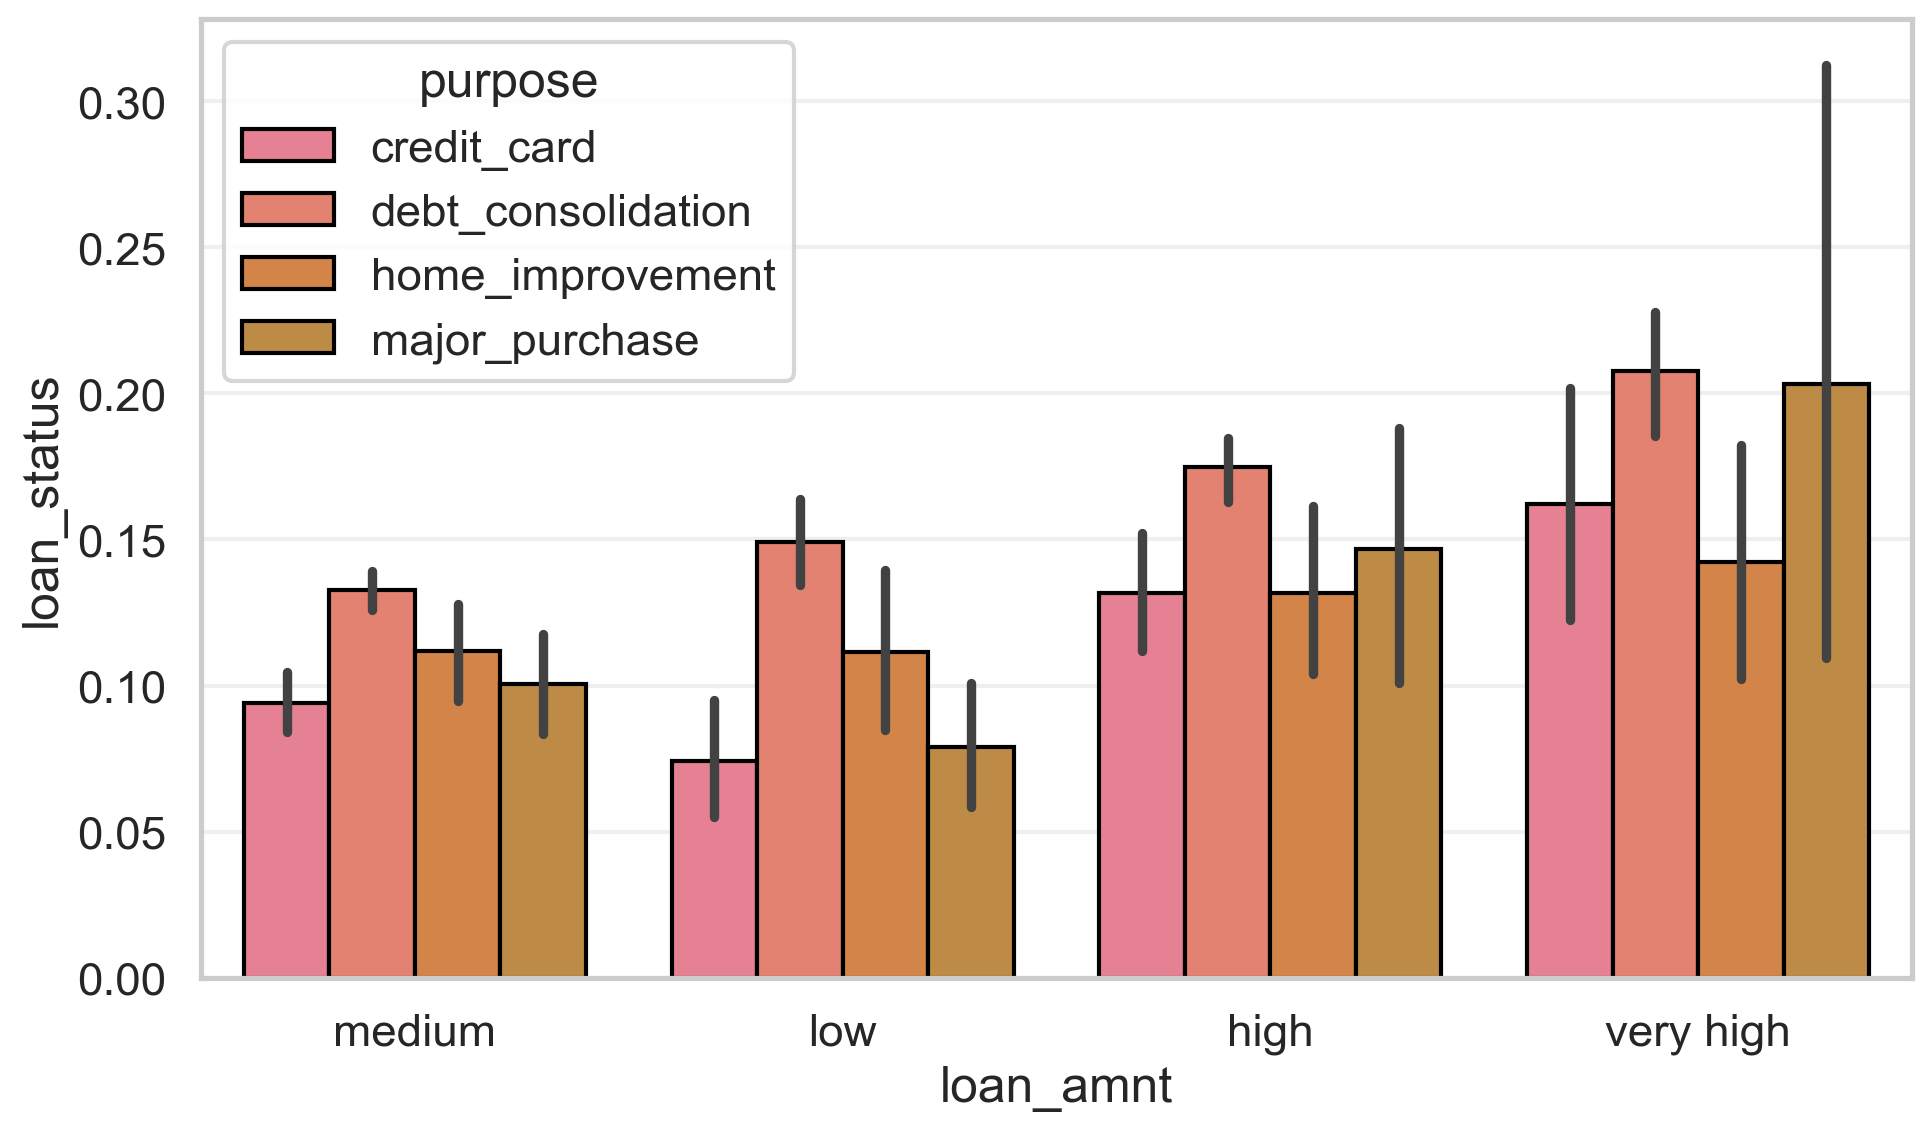

In [450]:
# loan_amnt: same trend across loan purposes
plot_segmented('loan_amnt')

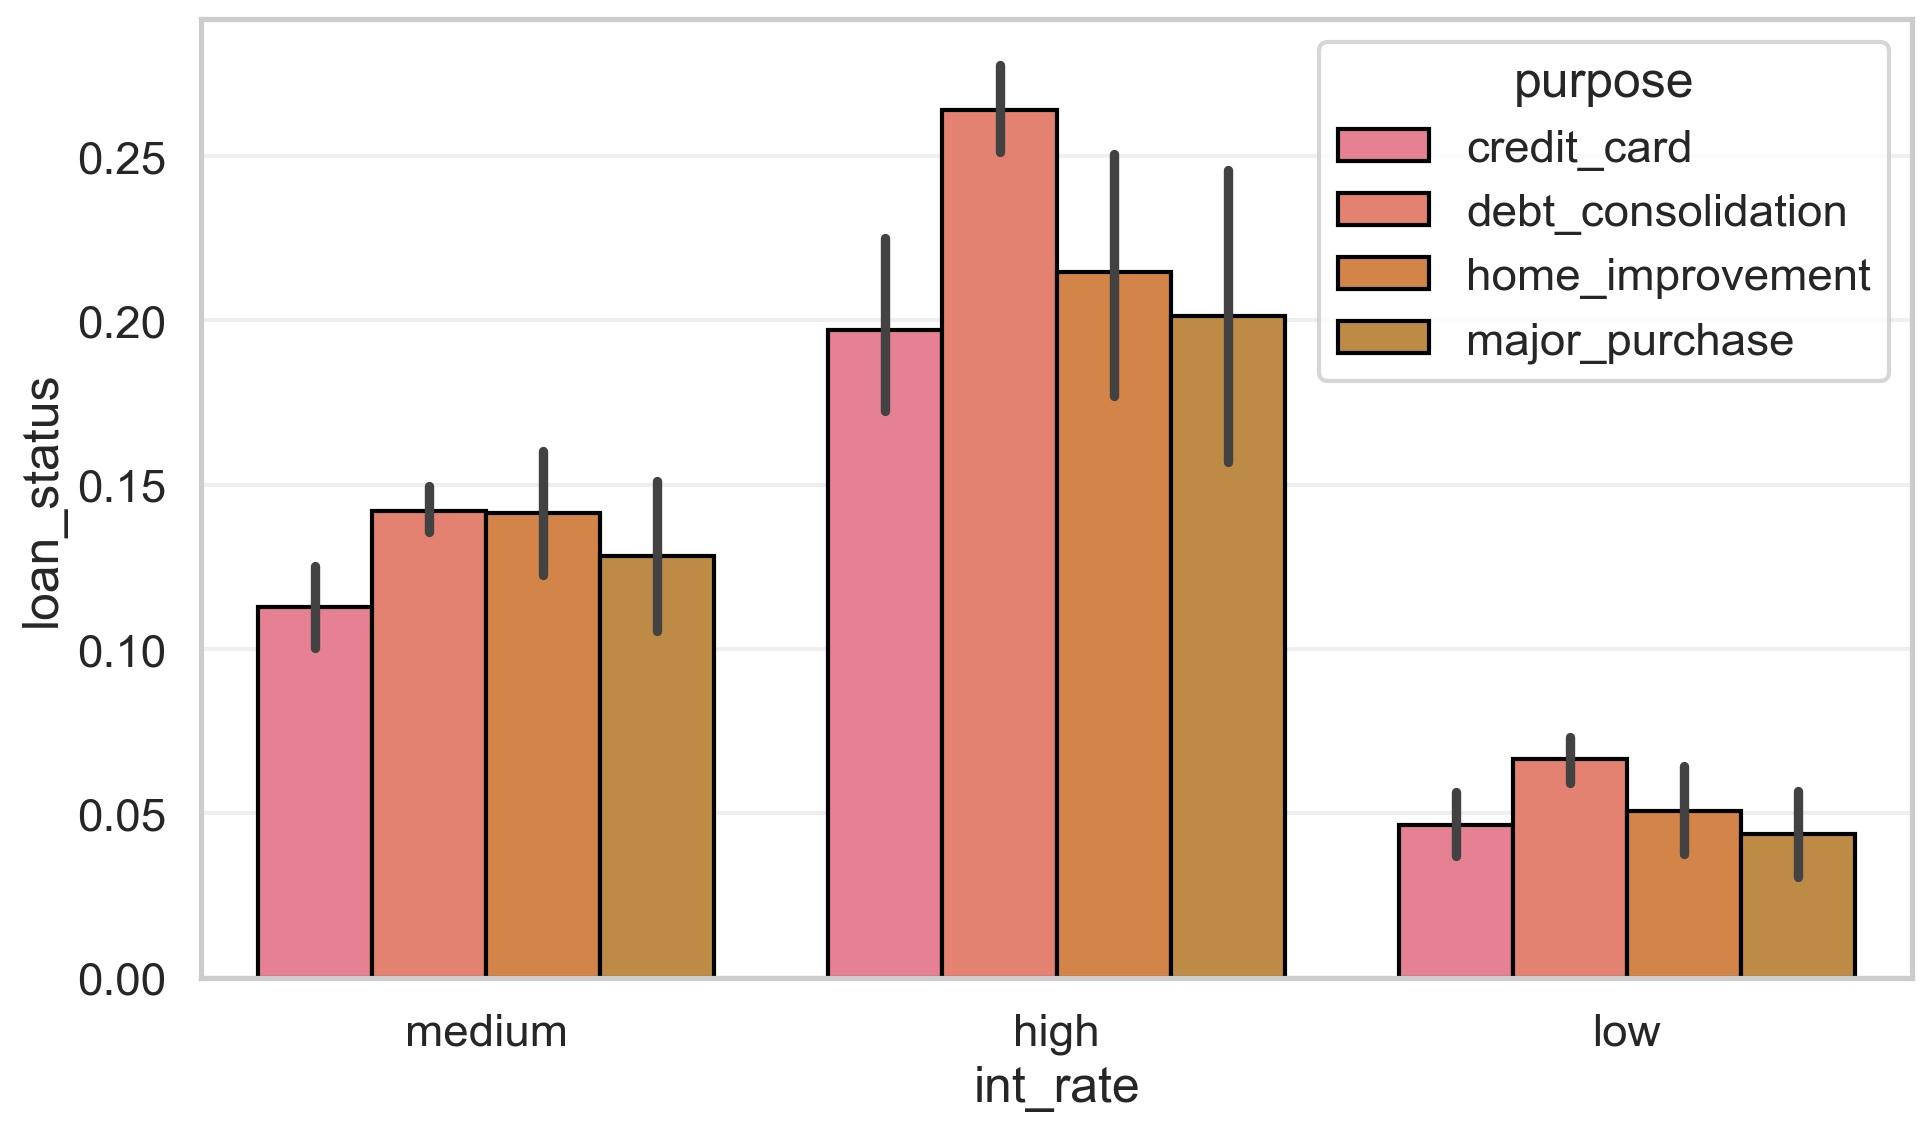

In [451]:
# interest rate
plot_segmented('int_rate')

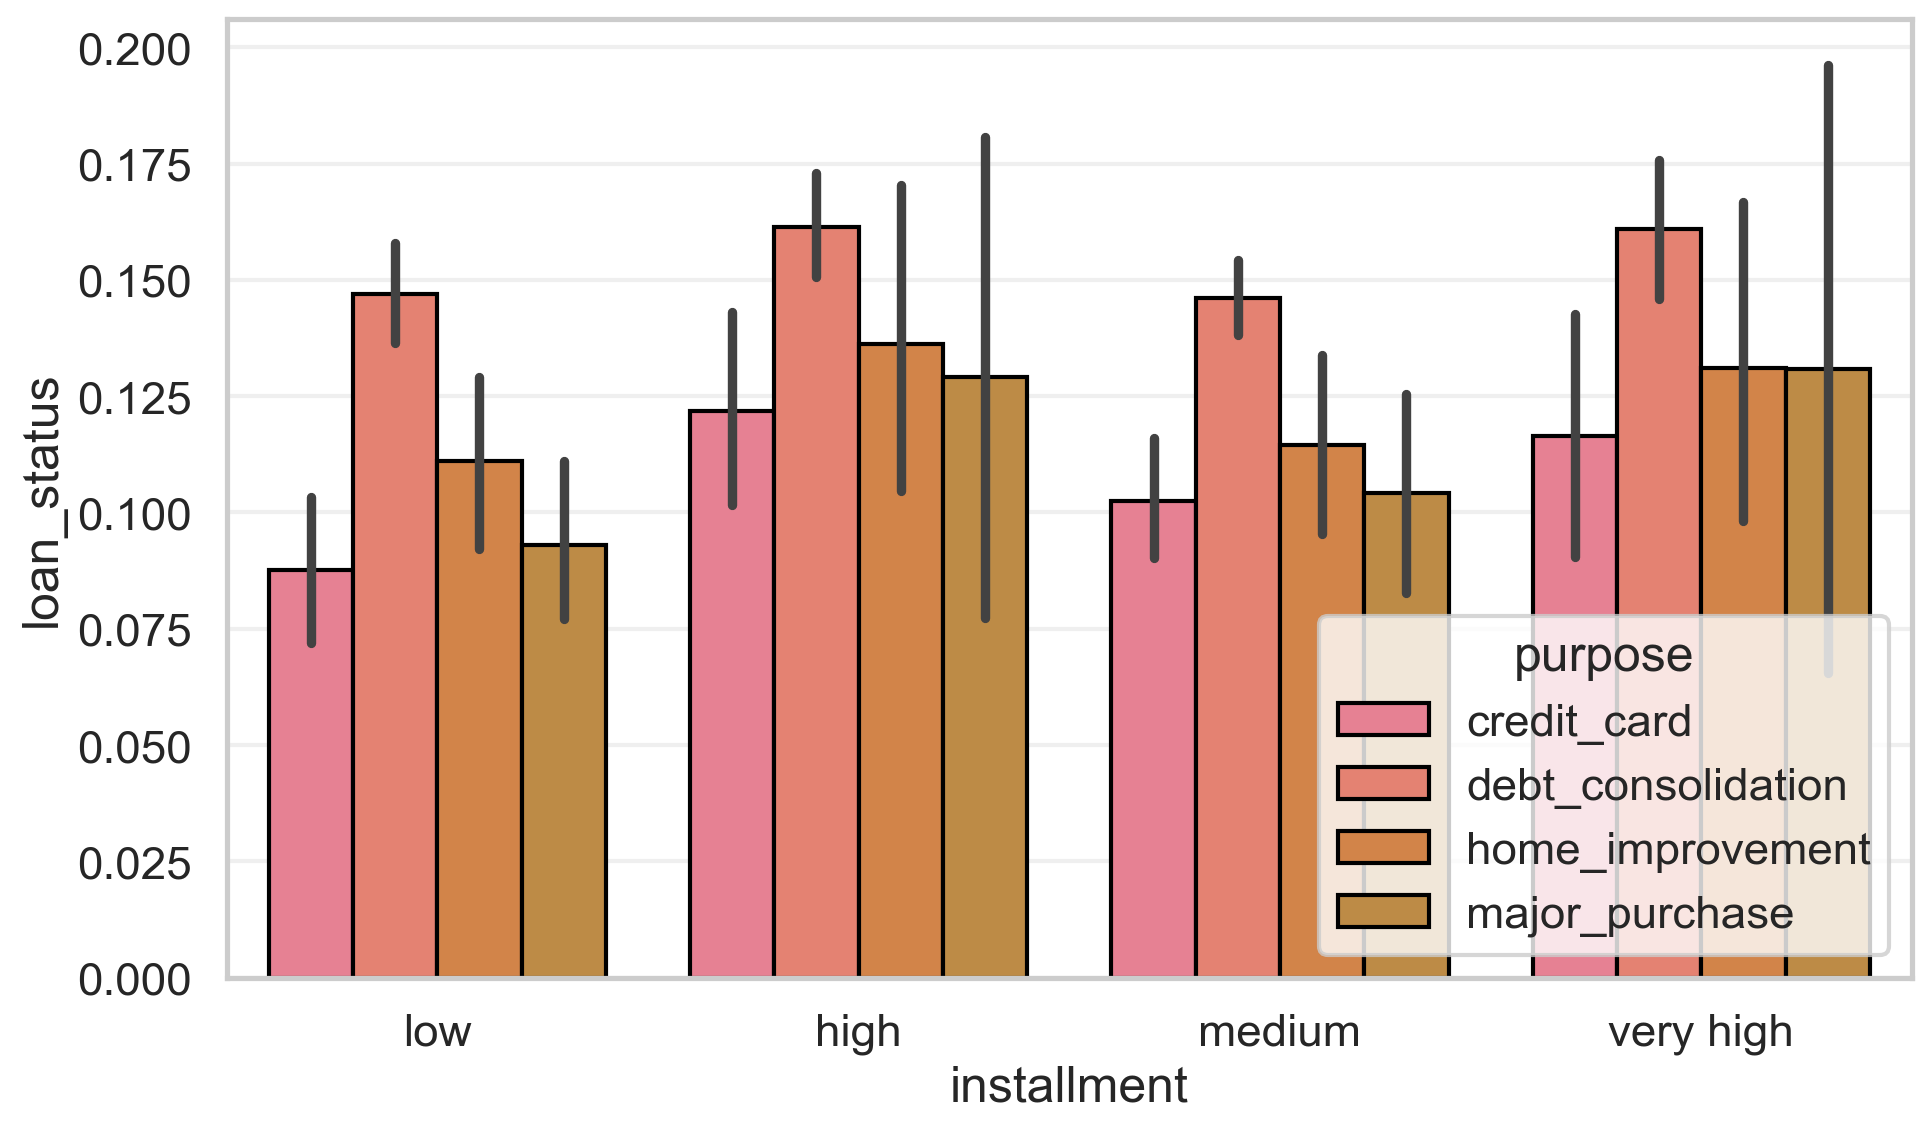

In [452]:
# installment
plot_segmented('installment')

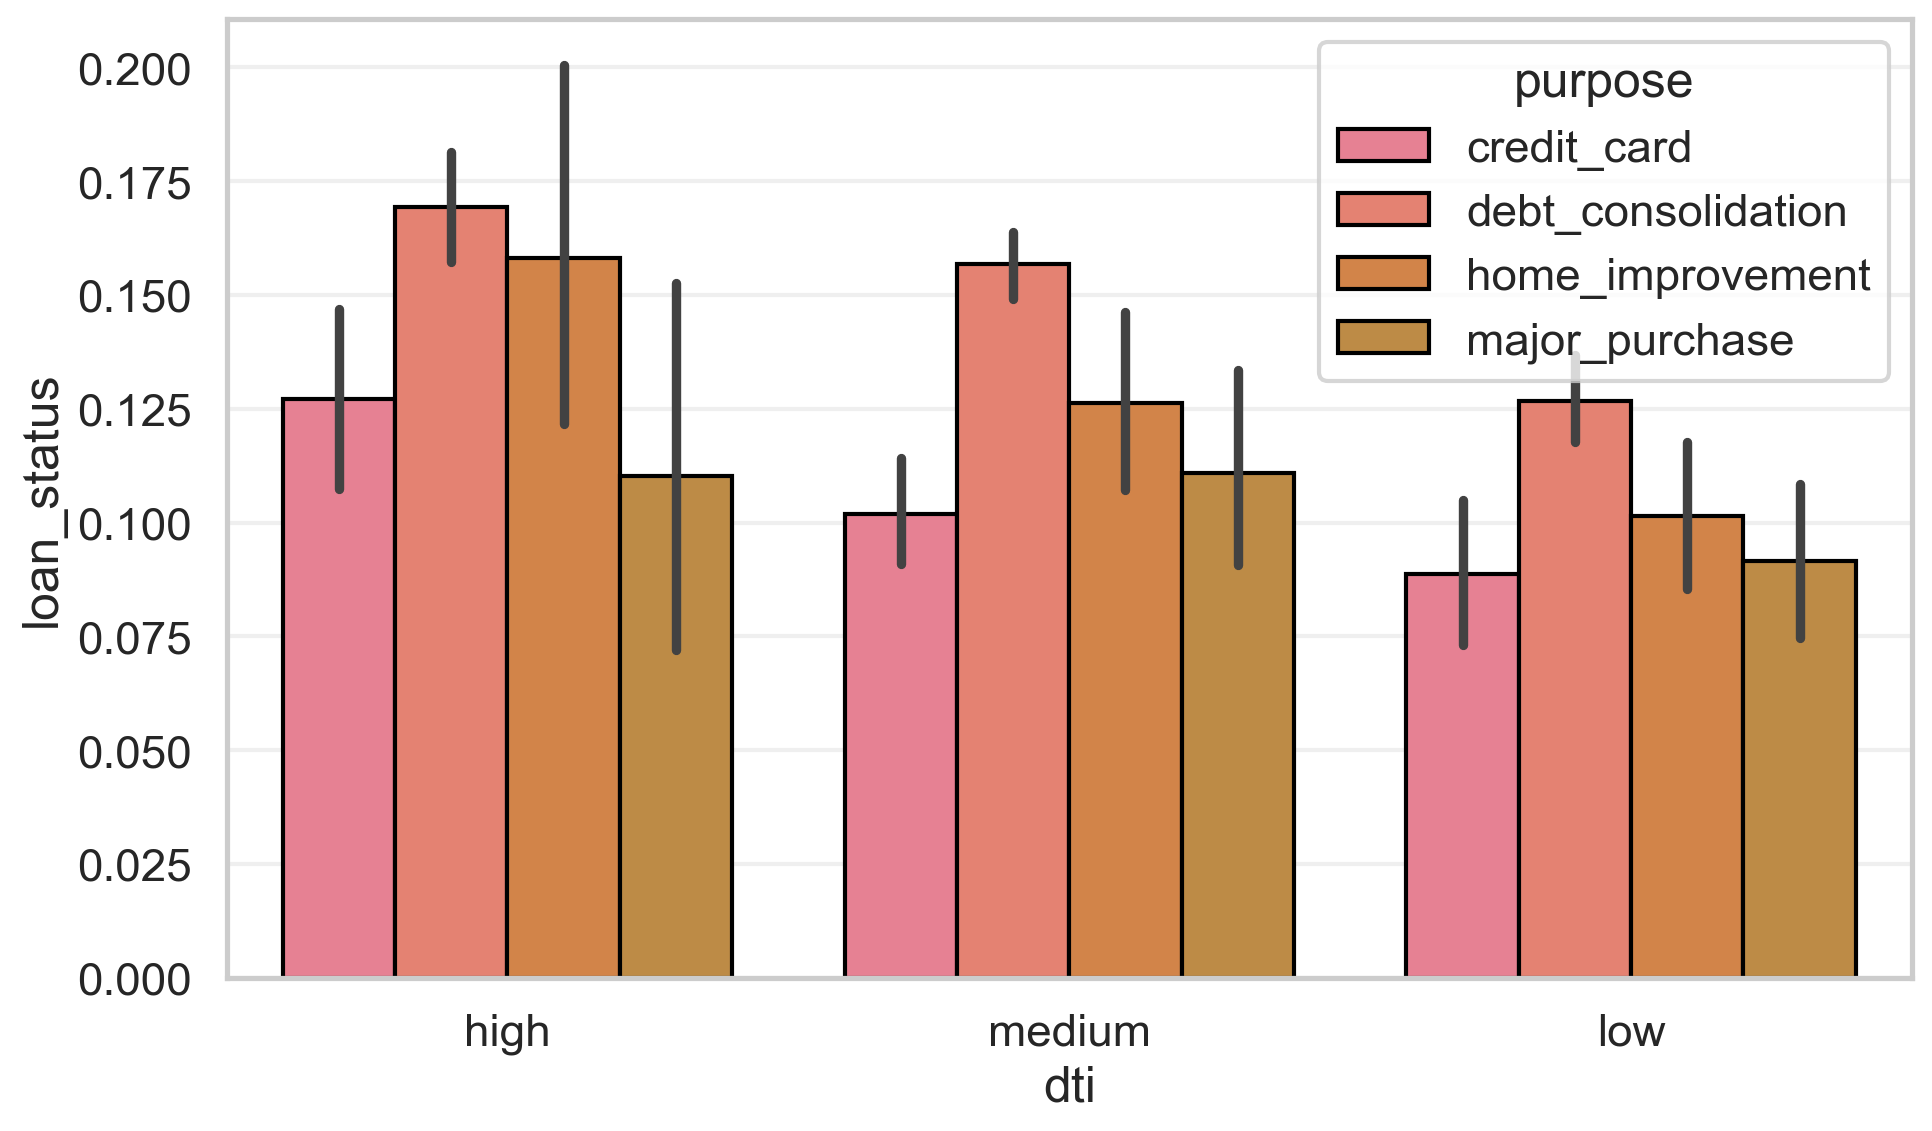

In [453]:
# debt to income ratio
plot_segmented('dti')

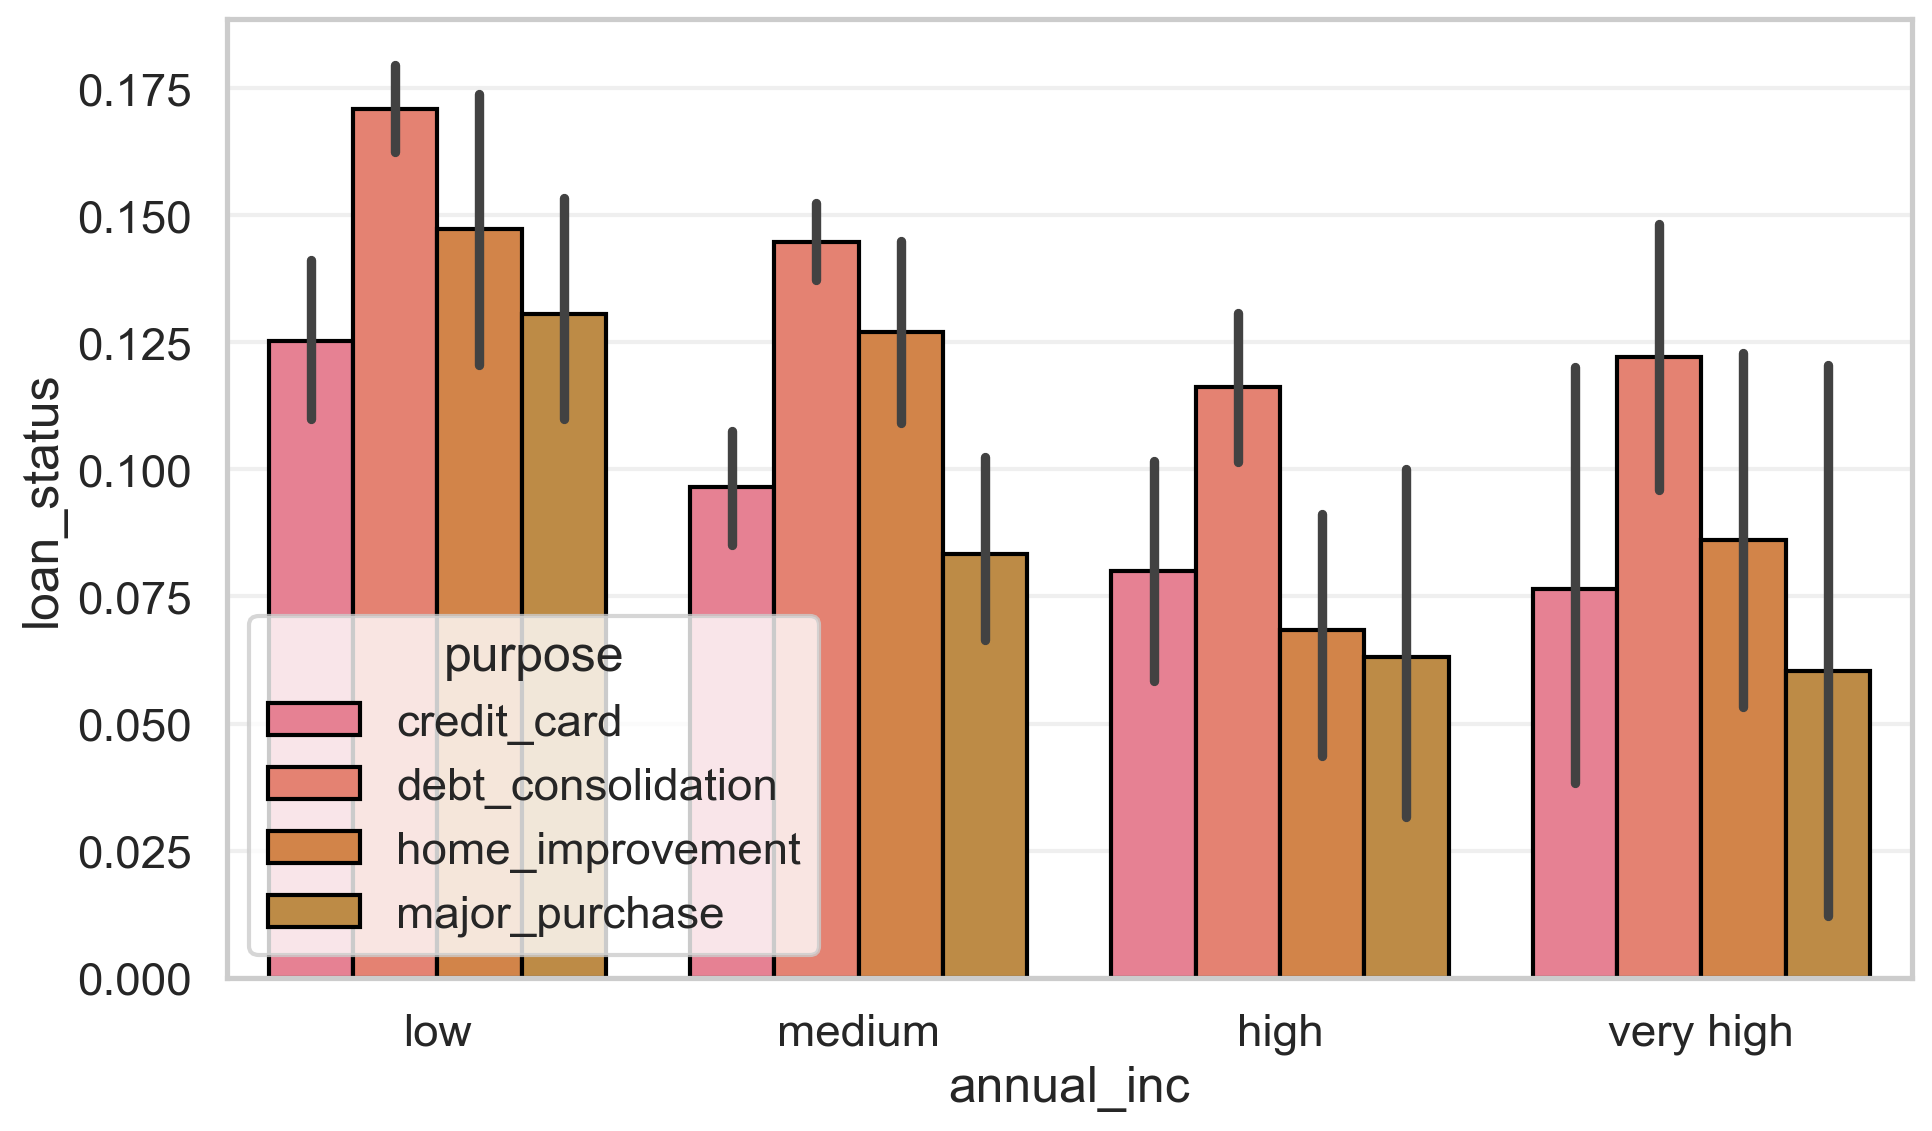

In [454]:
# annual income
plot_segmented('annual_inc')

# Conclusion: Lending Club Loan Default Analysis

## Executive Summary
This comprehensive analysis of **39,717 loan records** from Lending Club has revealed critical patterns and risk factors associated with loan defaults. The study examined 111 variables across demographic, financial, and loan-specific dimensions to identify key predictors that can inform credit risk assessment and lending decisions. 

With an overall **default rate of 14.38%**, the analysis underscores the importance of robust risk evaluation frameworks in the peer-to-peer lending ecosystem. Through systematic univariate and segmented bivariate analysis, we have identified several high-impact variables that significantly influence default probability.

---

## Key Findings

### 1. Loan Characteristics as Primary Risk Drivers
* **Loan Grade and Risk Correlation:** Default rates demonstrate a clear progressive relationship with loan grades, escalating from **Grade A (lowest risk)** through **Grade G (highest risk)**. 
* **Interest Rate Paradox:** Higher interest rates correlate strongly with increased default probability. Loans priced to compensate for risk may inadvertently increase that risk by increasing the payment burden.
* **Loan Amount Impact:** Larger loan amounts (categorized as 'very high') demonstrate elevated default rates, suggesting capacity assessments need recalibration for high-value lending.
* **Term Length Risk:** **60-month term loans** exhibit significantly higher default rates compared to 36-month loans, indicating that extended repayment periods introduce additional stability risks.

### 2. Purpose-Specific Default Patterns
Loan purpose emerged as one of the most significant predictors:
* **High Risk:** **Small Business Loans** (highest default rates), Renewable Energy, and Educational Loans.
* **Volume Leader:** **Debt Consolidation** represents the largest segment (17,675 applications) and requires careful evaluation of existing debt burdens.
* **Stable Categories:** Credit card refinancing, home improvement, and major purchases showed lower and more stable default rates.

### 3. Financial and Demographic Indicators
* **Annual Income:** A strong inverse relationship exists; lower-income segments demonstrate substantially higher default rates.
* **Debt-to-Income (DTI) Ratio:** Higher DTI ratios correlate directly with increased default probability.
* **The Verification Paradox:** Surprisingly, **verified income borrowers showed higher default rates** than non-verified borrowers. This suggests verification may be triggered for already high-risk applications or that these borrowers are pushed to their maximum capacity.
* **Employment Length:** Showed minimal predictive power, suggesting tenure is less relevant than current financial stability.

### 4. Temporal Trends and Seasonality
* **Volume Growth:** Rapid scaling from 251 loans in 2007 to 19,801 in 2011.
* **2011 Spike:** A notable increase in default rates occurred in 2011, potentially linked to macroeconomic shifts or platform scaling challenges.
* **Seasonality:** Applications peak in **December**, likely driven by holiday spending and year-end planning.

---

## Strategic Recommendations

### 1. Enhanced Risk-Based Pricing Model
Develop a multi-factor pricing algorithm incorporating loan purpose and term length. Implement **purpose-specific risk premiums** and establish conservative Loan-to-Value (LTV) ratios for high-risk categories like small businesses.

### 2. Refined Underwriting Criteria
* Implement stricter **DTI thresholds** for debt consolidation.
* Introduce **installment-to-income ratio caps**.
* Require comprehensive business plans for small business loan applicants.

### 3. Purpose-Specific Lending Programs
* **Debt Consolidation:** Mandatory financial counseling and graduated interest rate reductions for consistent performance.
* **Small Business:** Milestone-based funding releases and mentorship.
* **Home Improvement:** Offer competitive rates to drive volume in this stable segment.

### 4. Term Structure Optimization
Restrict **60-month terms** to elite borrowers (Grades A-B) with DTI ratios below 25%. Consider step-down interest rate structures to reward early repayment consistency.

### 5. Enhanced Verification Protocols
Address the "verification paradox" by expanding verification to include debt obligations and utilizing alternative data (utility payments, rent history) to build a more holistic risk profile.

### 6. Portfolio Diversification Strategy
Actively manage concentration risk. Set target allocations to ensure the portfolio is not over-indexed on high-risk purposes like debt consolidation, balancing it with stable categories like home improvement.

---

## Implementation Considerations

| Pillar | Focus Area |
| :--- | :--- |
| **Data Infrastructure** | Automated dashboards to track real-time default segments. |
| **Regulatory Alignment** | Ensure purpose-based pricing is actuarially justified and non-discriminatory. |
| **Technology** | Invest in Machine Learning to refine predictions using all 111 variables. |
| **Stakeholders** | Maintain transparency with investors regarding the 14.38% default rate and mitigation steps. |

---

## Final Remarks
The analysis reveals that default risk is **not uniformly distributed**. A one-size-fits-all approach to lending is suboptimal. By embracing data-driven practices—specifically purpose-specific criteria and proactive monitoring—Lending Club can achieve an optimal balance between growth, accessibility, and portfolio quality. 

**Continuous monitoring and iterative refinement will be essential to sustain the peer-to-peer lending model in a shifting macroeconomic landscape.**